# Proyecto Final Big Data Tools

## Análisis SIEVCAC con metodología CRISP-DM

Este notebook ejecuta el flujo técnico completo: ETL, EDA, estadística descriptiva e inferencial, procesamiento geoespacial, modelado supervisado y despliegue técnico.

## 0. Configuración del proyecto

La lógica principal está en src/bdtools. El notebook funciona como punto de ejecución y presentación de resultados.

In [3]:
from pathlib import Path
import sys
import warnings

import pandas as pd

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src" / "bdtools").exists():
            return path
    raise RuntimeError("No se encontró la carpeta src/bdtools.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(PROJECT_ROOT)

C:\Users\HOME\Documents\Enfasis Big Data Tools\proyecto\ProyectoFinalBDTools_CRISPDM


In [4]:
from bdtools import __version__
from bdtools import config as cfg

print("bdtools", __version__)
print(cfg.__file__)
print(cfg.RAW_DIR)

bdtools 1.0.0
C:\Users\HOME\Documents\Enfasis Big Data Tools\proyecto\ProyectoFinalBDTools_CRISPDM\src\bdtools\config.py
C:\Users\HOME\Documents\Enfasis Big Data Tools\proyecto\ProyectoFinalBDTools_CRISPDM\data\raw


## 1. Comprensión del negocio

El análisis se centra en casos de reclutamiento y utilización de niños, niñas y adolescentes en el conflicto armado colombiano. El objetivo técnico es transformar el dataset SIEVCAC en una solución reproducible que permita describir patrones temporales, territoriales y categóricos, evaluar asociaciones estadísticas y construir modelos supervisados para identificar casos de alto impacto.

La variable objetivo alto_impacto se define a partir del número de víctimas del caso. Se marca como 1 cuando el caso registra más de una víctima y como 0 en los demás casos. Esta definición permite plantear el problema como clasificación binaria.

## 2. Comprensión de los datos

Se carga el archivo original desde data/raw, se revisa la calidad de las variables y se exporta una tabla de diagnóstico.

In [5]:
from bdtools.io import read_raw_data

raw_df = read_raw_data()
raw_df.shape

(17201, 27)

In [6]:
raw_df.head()

,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,...,Extorsión,Lesionados Civiles,Pillaje,Tortura,Violencia Basada en Género,Otro Hecho Simultáneo,Total de Víctimas del Caso,Forma de Vinculación,Tipo de Vinculación,latitud-longitud
0,152.888,NaN,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893)
1,207.556,NaN,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474)
2,209.268,NaN,0.000,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782)
3,225.057,NaN,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346)
4,228.661,NaN,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,0,0,0,0,NaN,OCULTAMIENTO DE CADÁVER,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487)


In [7]:
raw_df.dtypes.rename("tipo").to_frame().head(20)

,tipo
ID Caso,float64
ID Caso Relacionado,str
Año,float64
Mes,int64
Día,int64
Código DANE de Municipio,str
Municipio,str
Departamento,str
Región,str
Modalidad,str


## 3. Preparación de los datos

La preparación incluye normalización de nombres de columnas, depuración de columnas con exceso de nulos, tratamiento de fechas inválidas, estandarización de texto, extracción de coordenadas y creación de variables derivadas.

In [8]:
from bdtools.io import run_etl

df, calidad_datos = run_etl()

df.shape

(17201, 32)

In [9]:
df.head()

,id_caso,anio,mes,dia,codigo_dane_de_municipio,municipio,departamento,region,modalidad,presunto_responsable,...,tipo_vinculacion,latitud_longitud,anio_valido,mes_valido,dia_valido,decada,latitud,longitud,alto_impacto,total_hechos
0,152.888,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,GRUPO PARAMILITAR,...,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893),2004,4,<NA>,2000-2009,6.219481,-74.571689,0,1
1,207.556,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,GRUPO PARAMILITAR,...,RECLUTAMIENTO,POINT (-74.82807326 5.837681474),2001,4,25,2000-2009,5.837681,-74.828073,0,1
2,209.268,0.000,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,GUERRILLA,...,RECLUTAMIENTO,POINT (-76.31426328 6.992243782),<NA>,<NA>,<NA>,SIN INFORMACION,6.992244,-76.314263,0,0
3,225.057,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,GUERRILLA,...,RECLUTAMIENTO,POINT (-73.53900334 6.894292346),1988,<NA>,<NA>,1980-1989,6.894292,-73.539003,0,0
4,228.661,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,GUERRILLA,...,RECLUTAMIENTO,POINT (-75.90432634 5.416268487),1998,2,15,1990-1999,5.416268,-75.904326,0,0


In [10]:
calidad_datos.head(15)

,variable,tipo_limpio,nulos_raw_pct,nulos_limpio_pct,valores_unicos_limpio
13,dia_valido,Int64,NaN,69.57,31
23,mes_valido,Int64,NaN,67.31,12
4,anio_valido,Int64,NaN,64.97,50
0,abandono_o_despojo_forzado_de_tierras,int64,0.0,0.00,2
1,alto_impacto,int64,NaN,0.00,2
2,amenaza_o_intimidacion,int64,0.0,0.00,2
3,anio,float64,0.0,0.00,51
5,ataque_contra_mision_medica,int64,0.0,0.00,1
6,codigo_dane_de_municipio,str,0.0,0.00,833
7,confinamiento_o_restriccion_a_la_movilidad,int64,0.0,0.00,2


## 4. EDA y estadística descriptiva

Se generan tablas de frecuencia, resumen general y las figuras principales del análisis exploratorio.

In [11]:
from bdtools.eda import build_eda_reports
from bdtools.statistics import build_statistics_reports
from bdtools.geo import build_geospatial_outputs
from bdtools.modeling import train_and_evaluate_models

eda_outputs = build_eda_reports(df, calidad_datos)
stats_outputs = build_statistics_reports(df)
gdf = build_geospatial_outputs(df)
model_outputs = train_and_evaluate_models(df)

eda_outputs["resumen_general"]

,indicador,valor
0,registros,17201.000000
1,variables,32.000000
2,duplicados,0.000000
3,victimas_total,18182.000000
4,victimas_media,1.057032
5,victimas_max,150.000000
6,anio_valido_unicos,50.000000
7,departamento_unicos,35.000000
8,region_unicos,76.000000
9,modalidad_unicos,5.000000


In [12]:
stats_outputs["estadistica_descriptiva"]

,indicador,valor
0,casos,17201.0000
1,variables,32.0000
2,victimas_total,18182.0000
3,victimas_media,1.0570
4,victimas_mediana,1.0000
5,victimas_desviacion,1.2522
6,victimas_min,1.0000
7,victimas_max,150.0000
8,alto_impacto_proporcion,0.0229
9,alto_impacto_ic95_inf,0.0207


In [13]:
eda_outputs.get("frecuencia_departamento").head(10)

,variable,categoria,casos,porcentaje
0,departamento,ANTIOQUIA,2749,15.98
1,departamento,SIN INFORMACION,2413,14.03
2,departamento,META,1513,8.80
3,departamento,CAQUETA,1263,7.34
4,departamento,CAUCA,776,4.51
5,departamento,TOLIMA,741,4.31
6,departamento,NARIÑO,629,3.66
7,departamento,PUTUMAYO,533,3.10
8,departamento,CHOCO,498,2.90
9,departamento,ARAUCA,488,2.84


In [14]:
eda_outputs.get("frecuencia_modalidad").head(10)

,variable,categoria,casos,porcentaje
0,modalidad,DESCONOCIDA,8311,48.32
1,modalidad,PERSUASIÓN,6818,39.64
2,modalidad,COACCIÓN,2043,11.88
3,modalidad,ENGAÑO,26,0.15
4,modalidad,OTRA ¿CUÁL?,3,0.02


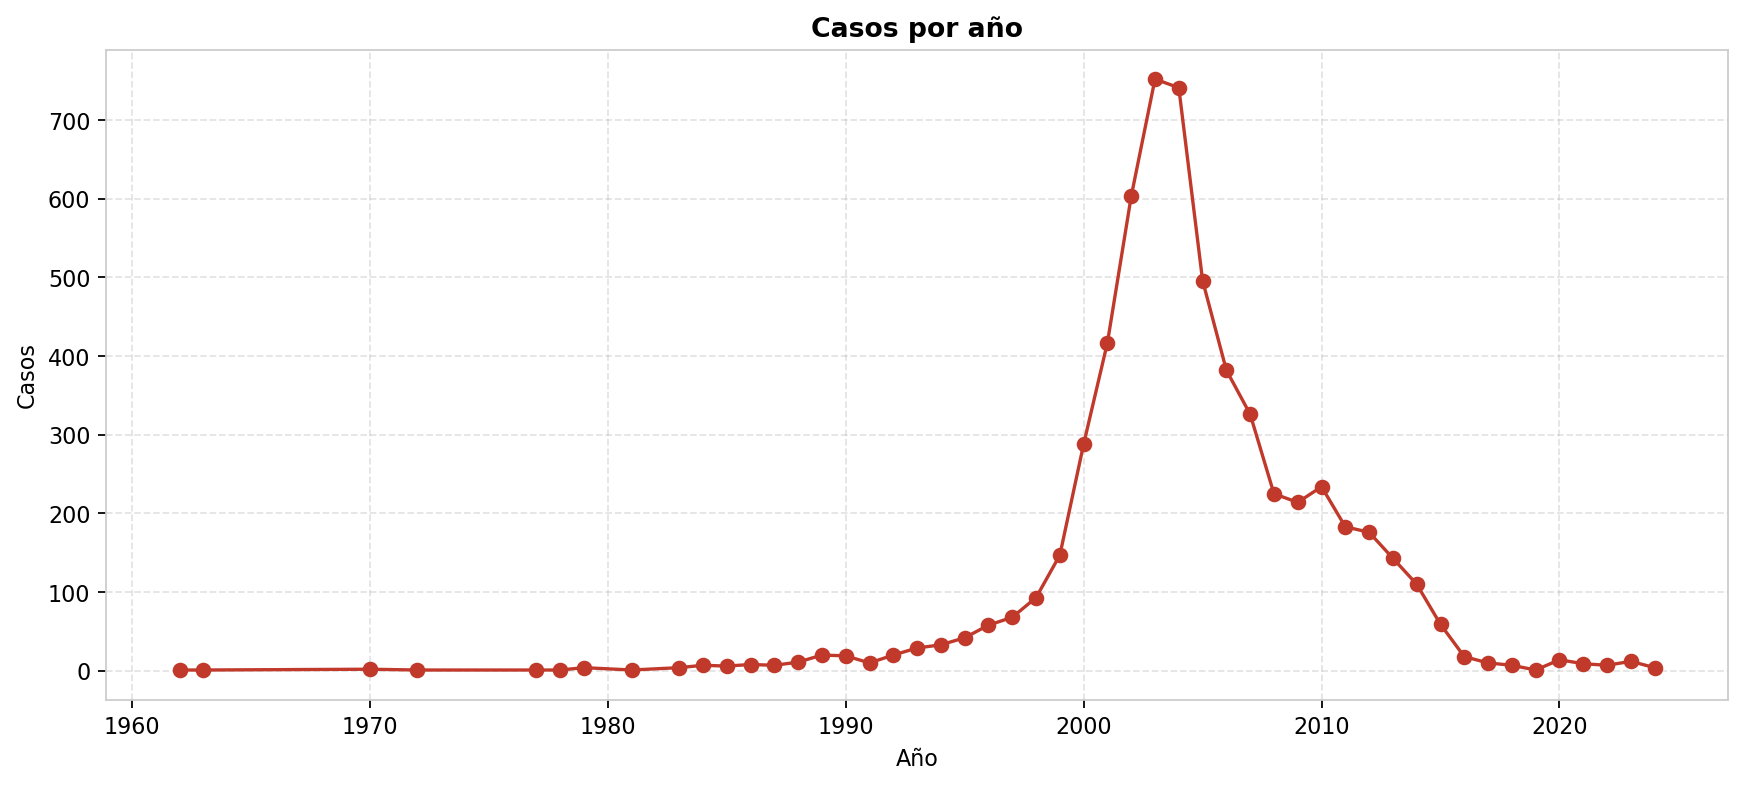

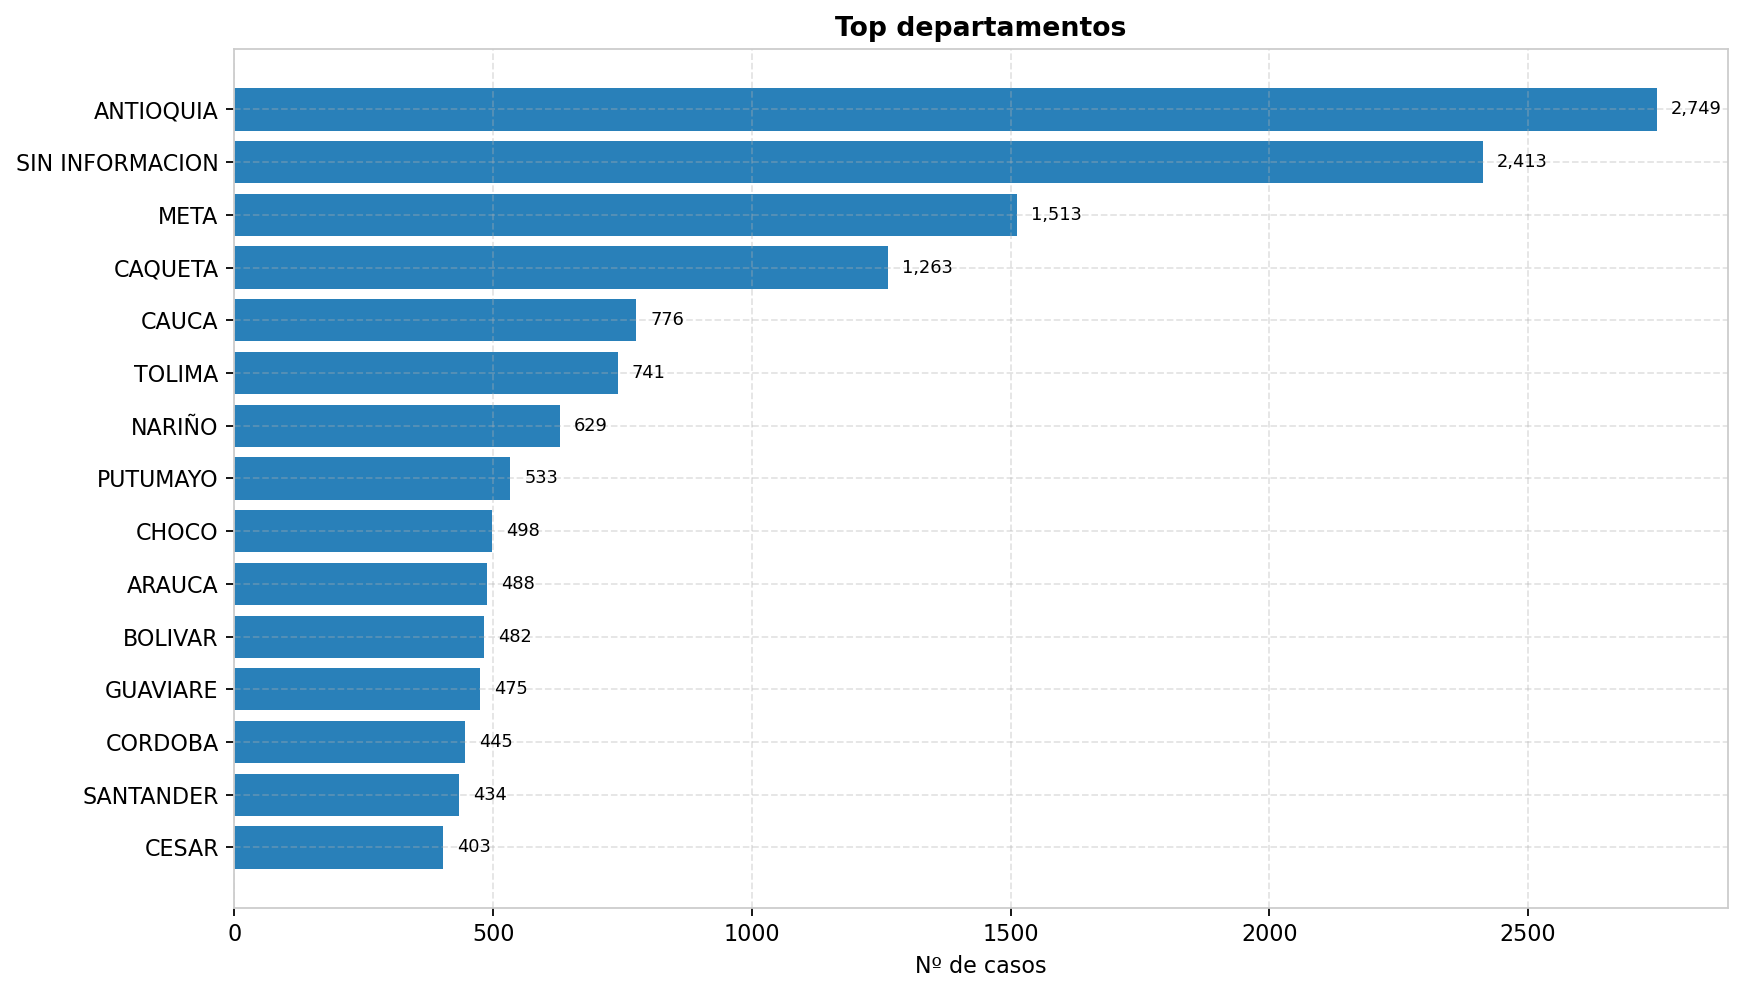

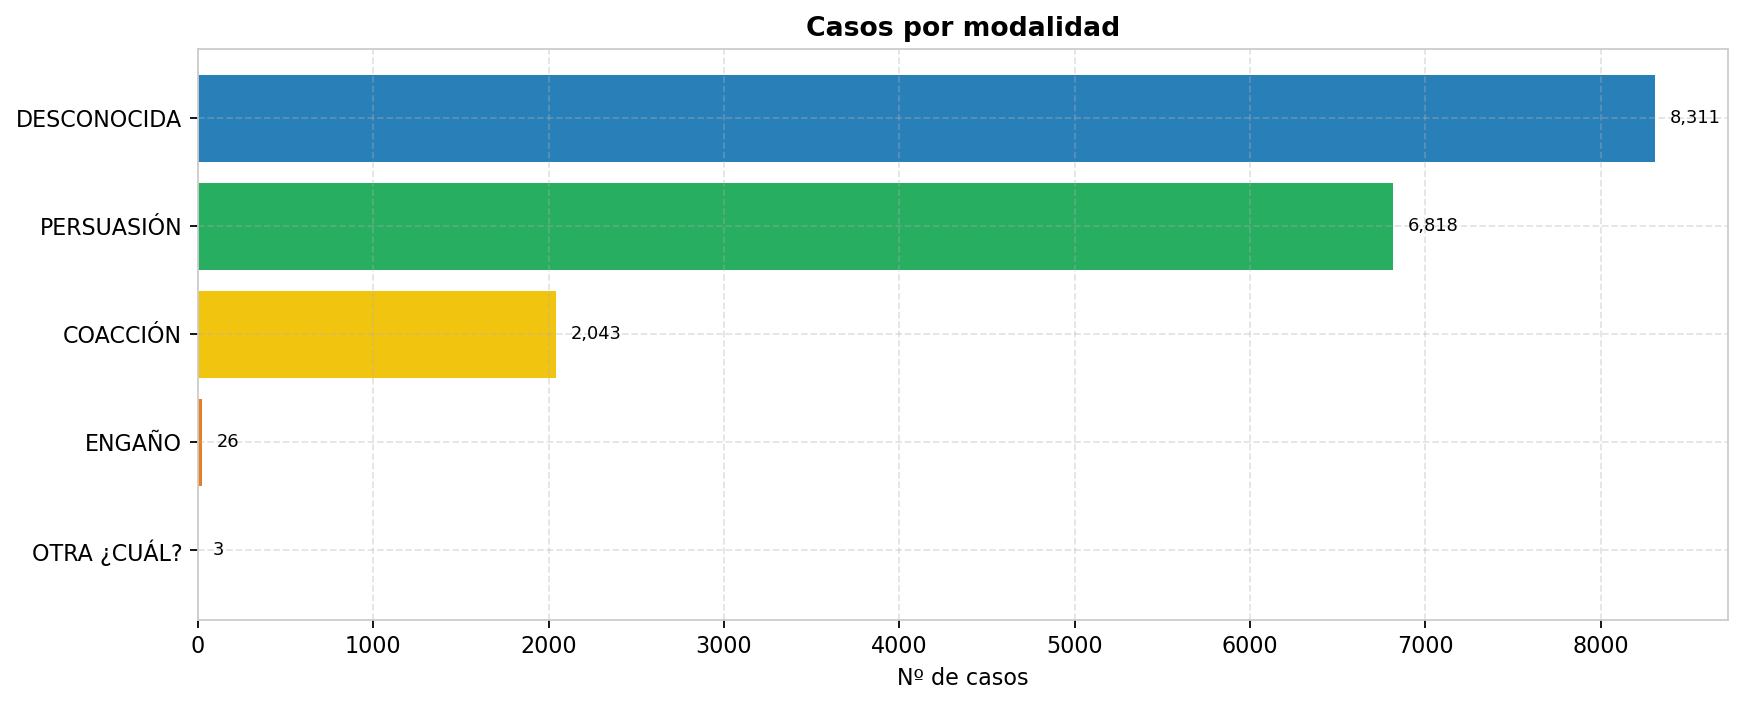

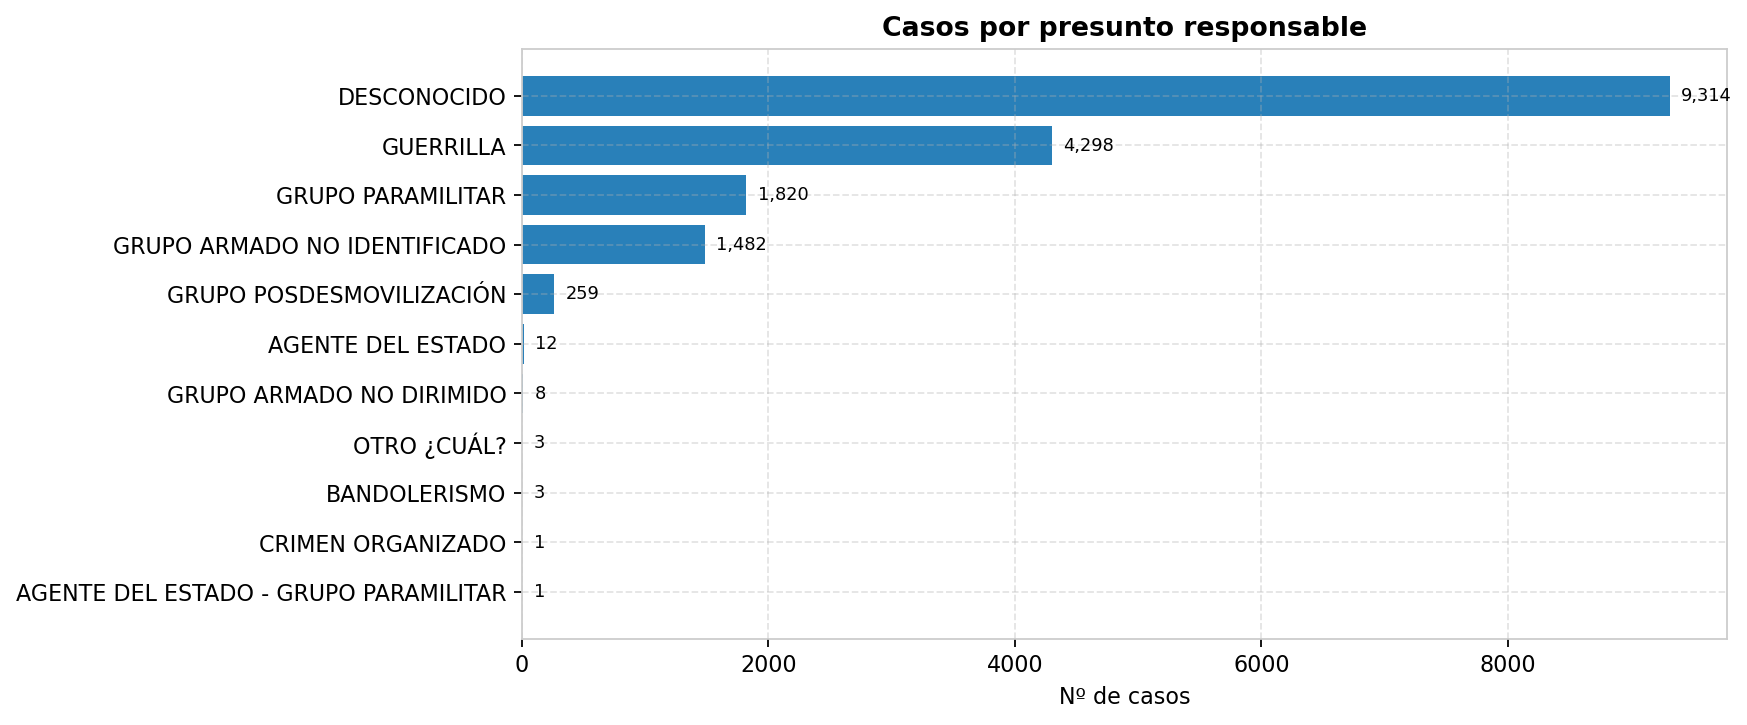

In [15]:
import bdtools.config as cfg
from IPython.display import Image, display

figuras_eda = [
    cfg.FIG_CASOS_ANIO,
    cfg.FIG_TOP_DEPARTAMENTOS,
    cfg.FIG_MODALIDAD,
    cfg.FIG_RESPONSABLE,
]

for fig in figuras_eda:
    if fig.exists():
        display(Image(filename=str(fig)))
    else:
        print(f"No se encontró: {fig.name}")

### Visualizaciones ampliadas para informe

Estas figuras complementan el EDA inicial con mapa de nulos, auditoría de limpieza, frecuencias categóricas, temporalidad, análisis bivariado, outliers e inferencia avanzada.

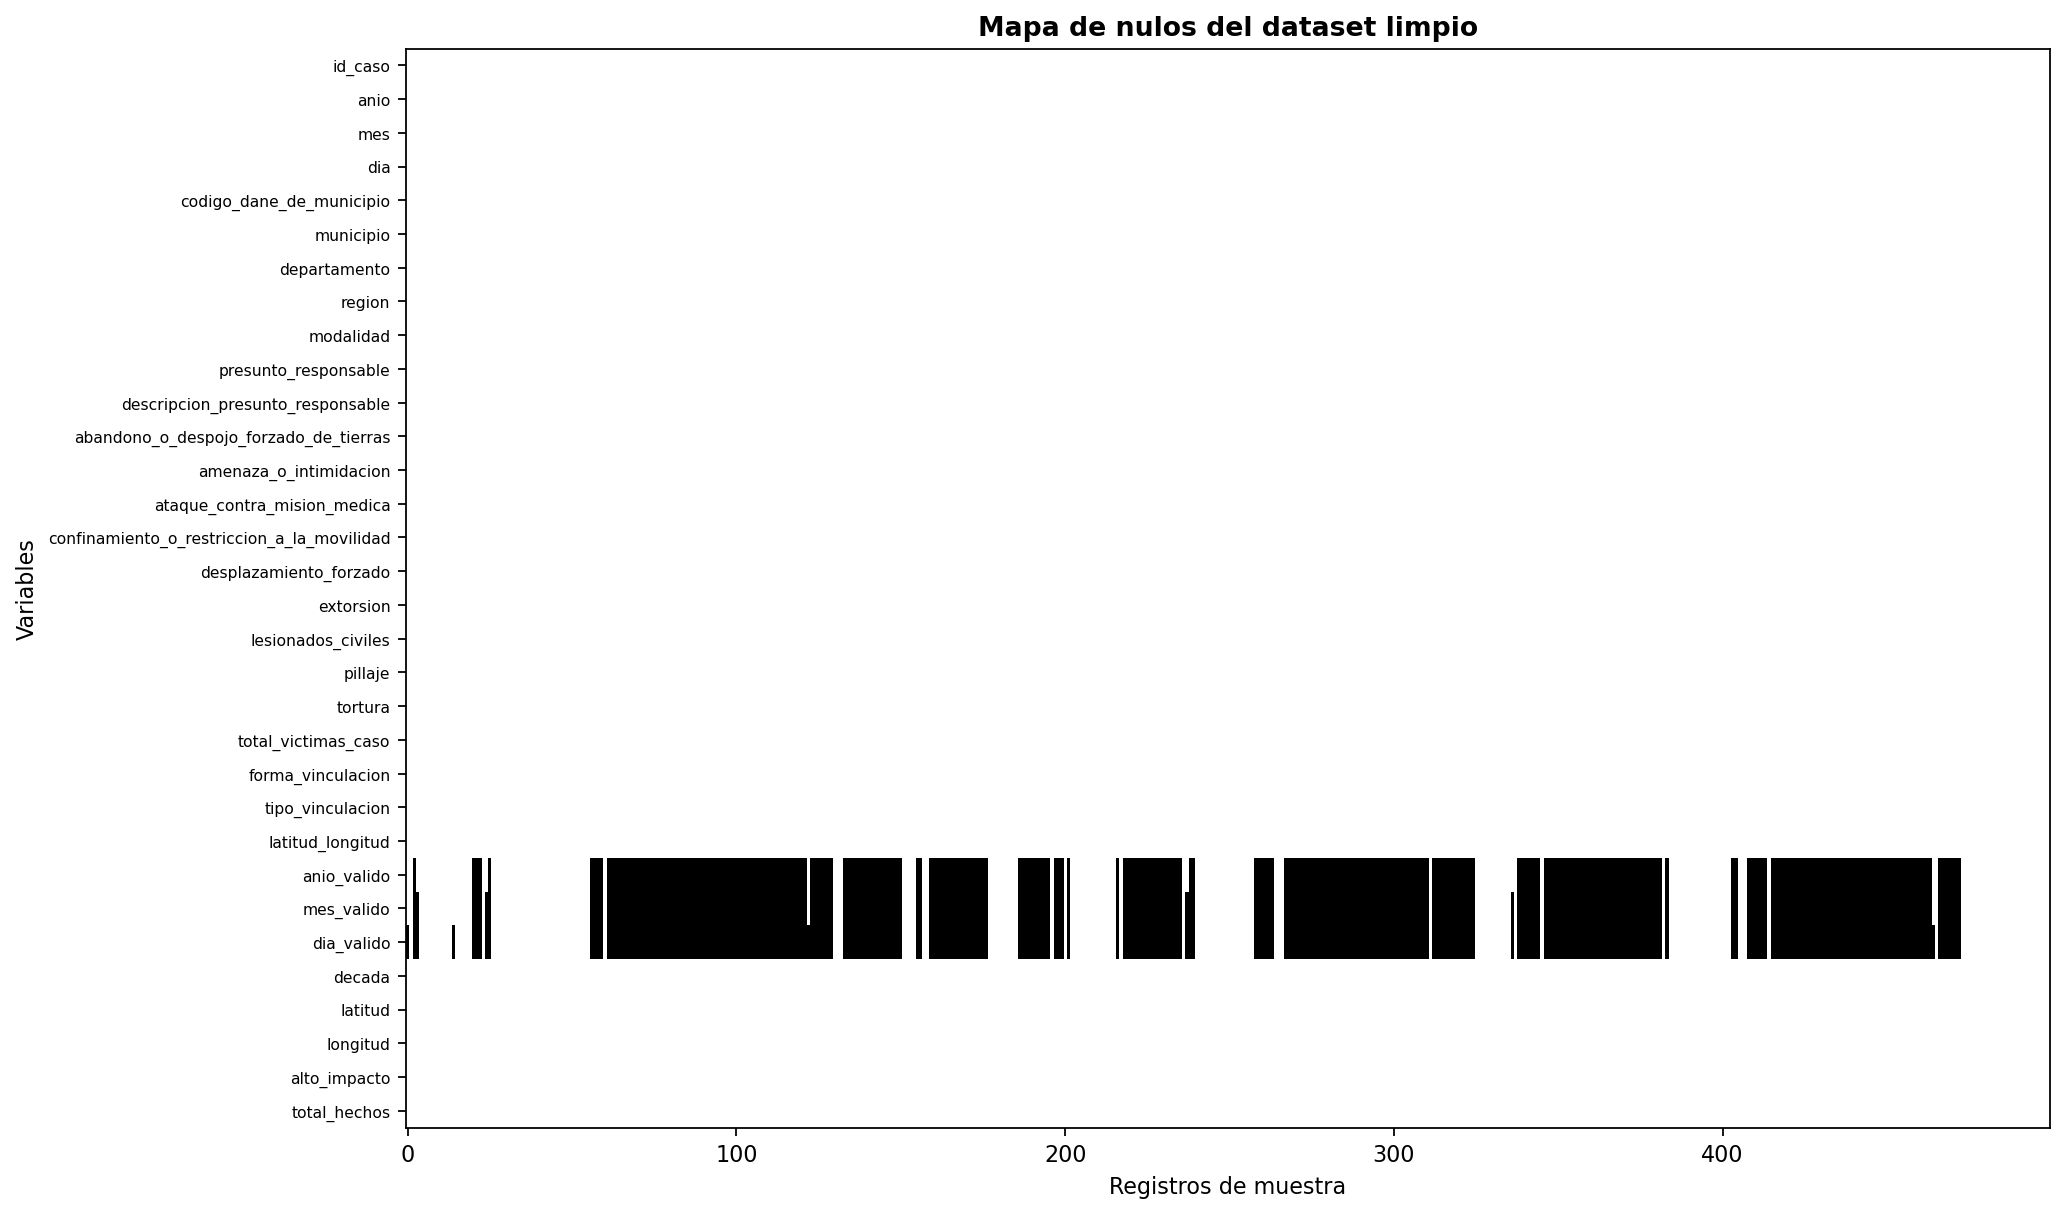

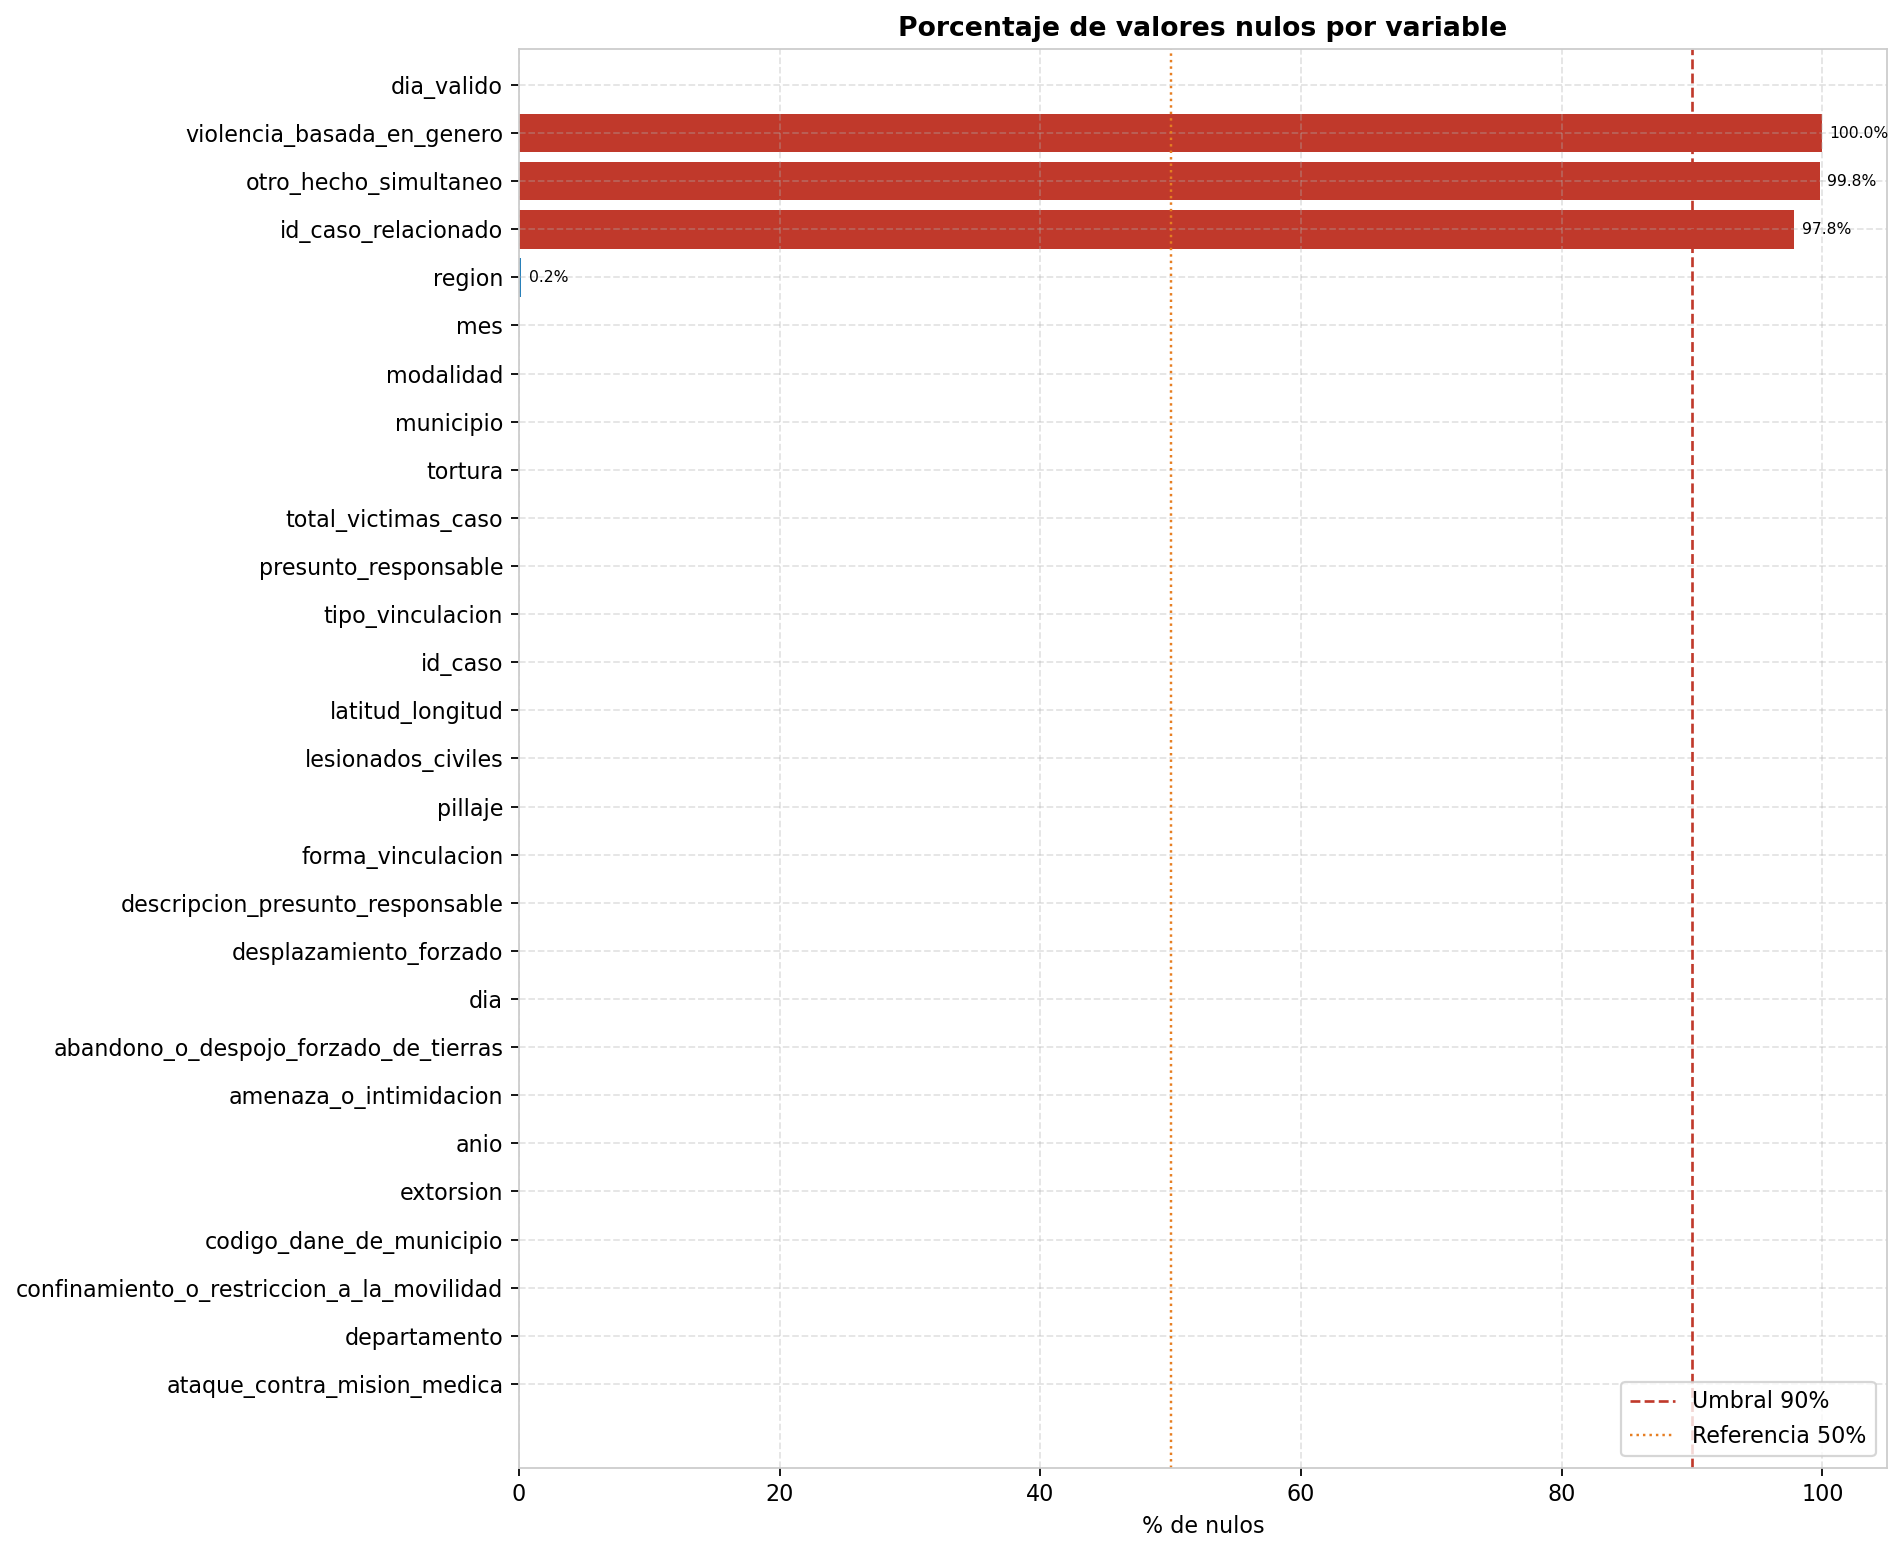

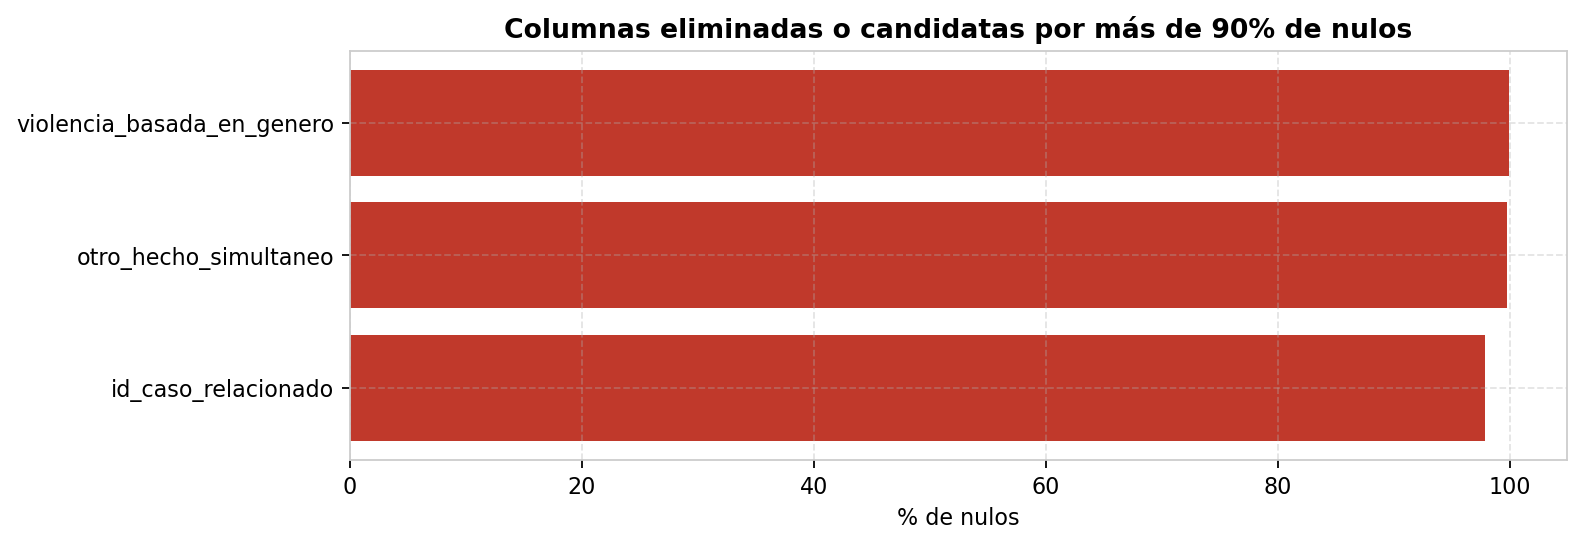

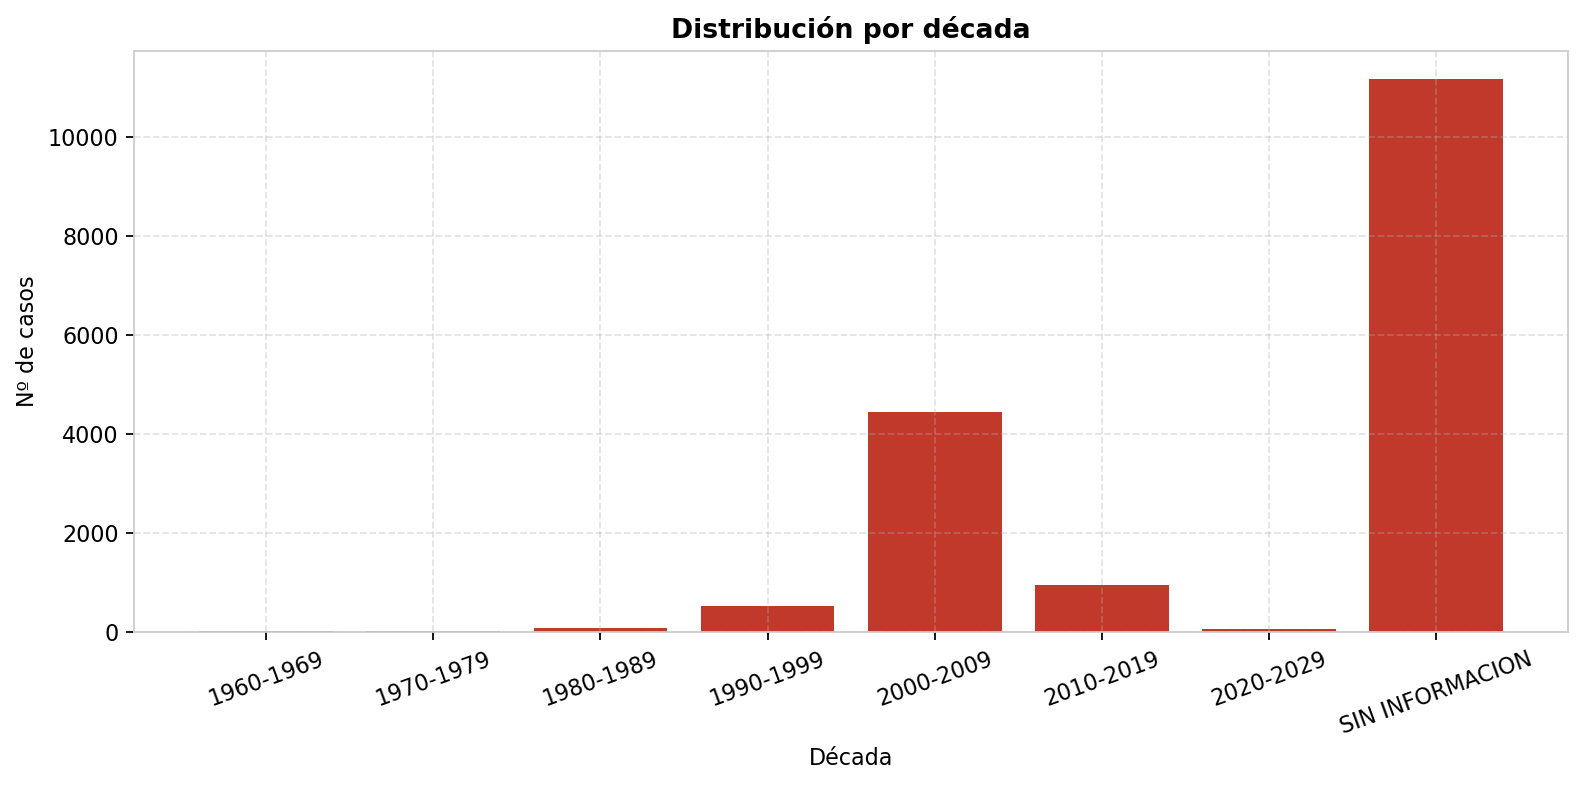

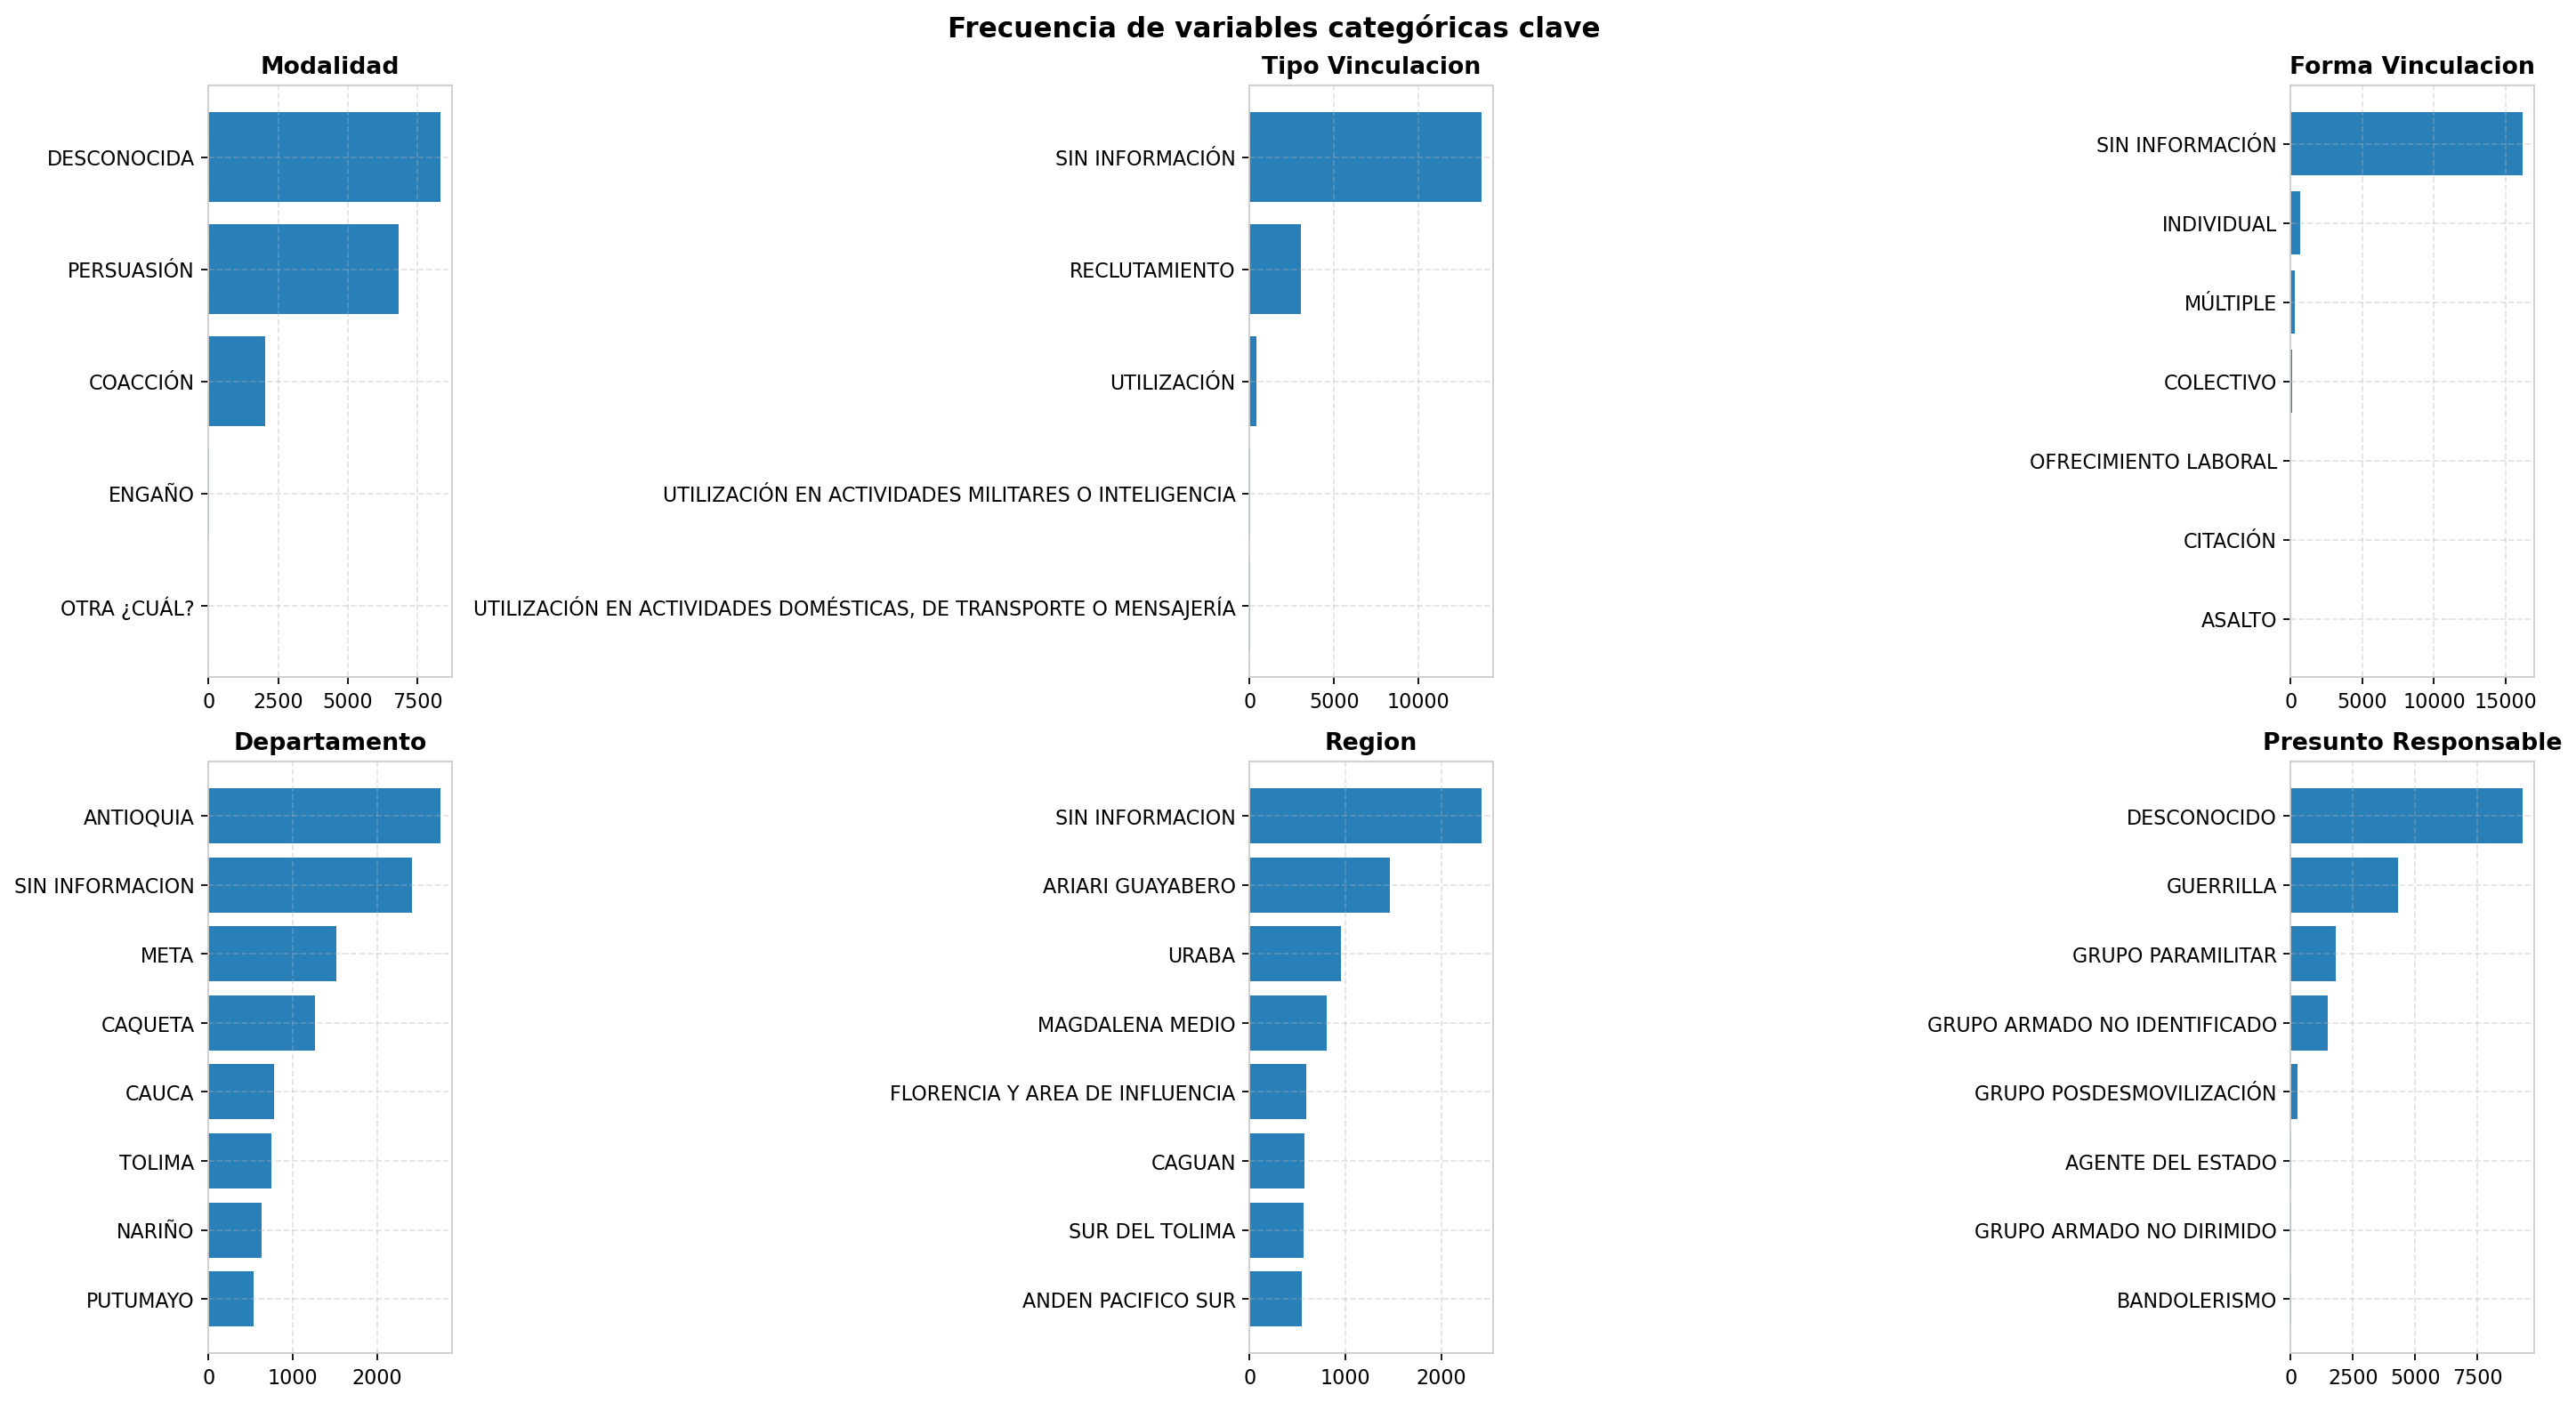

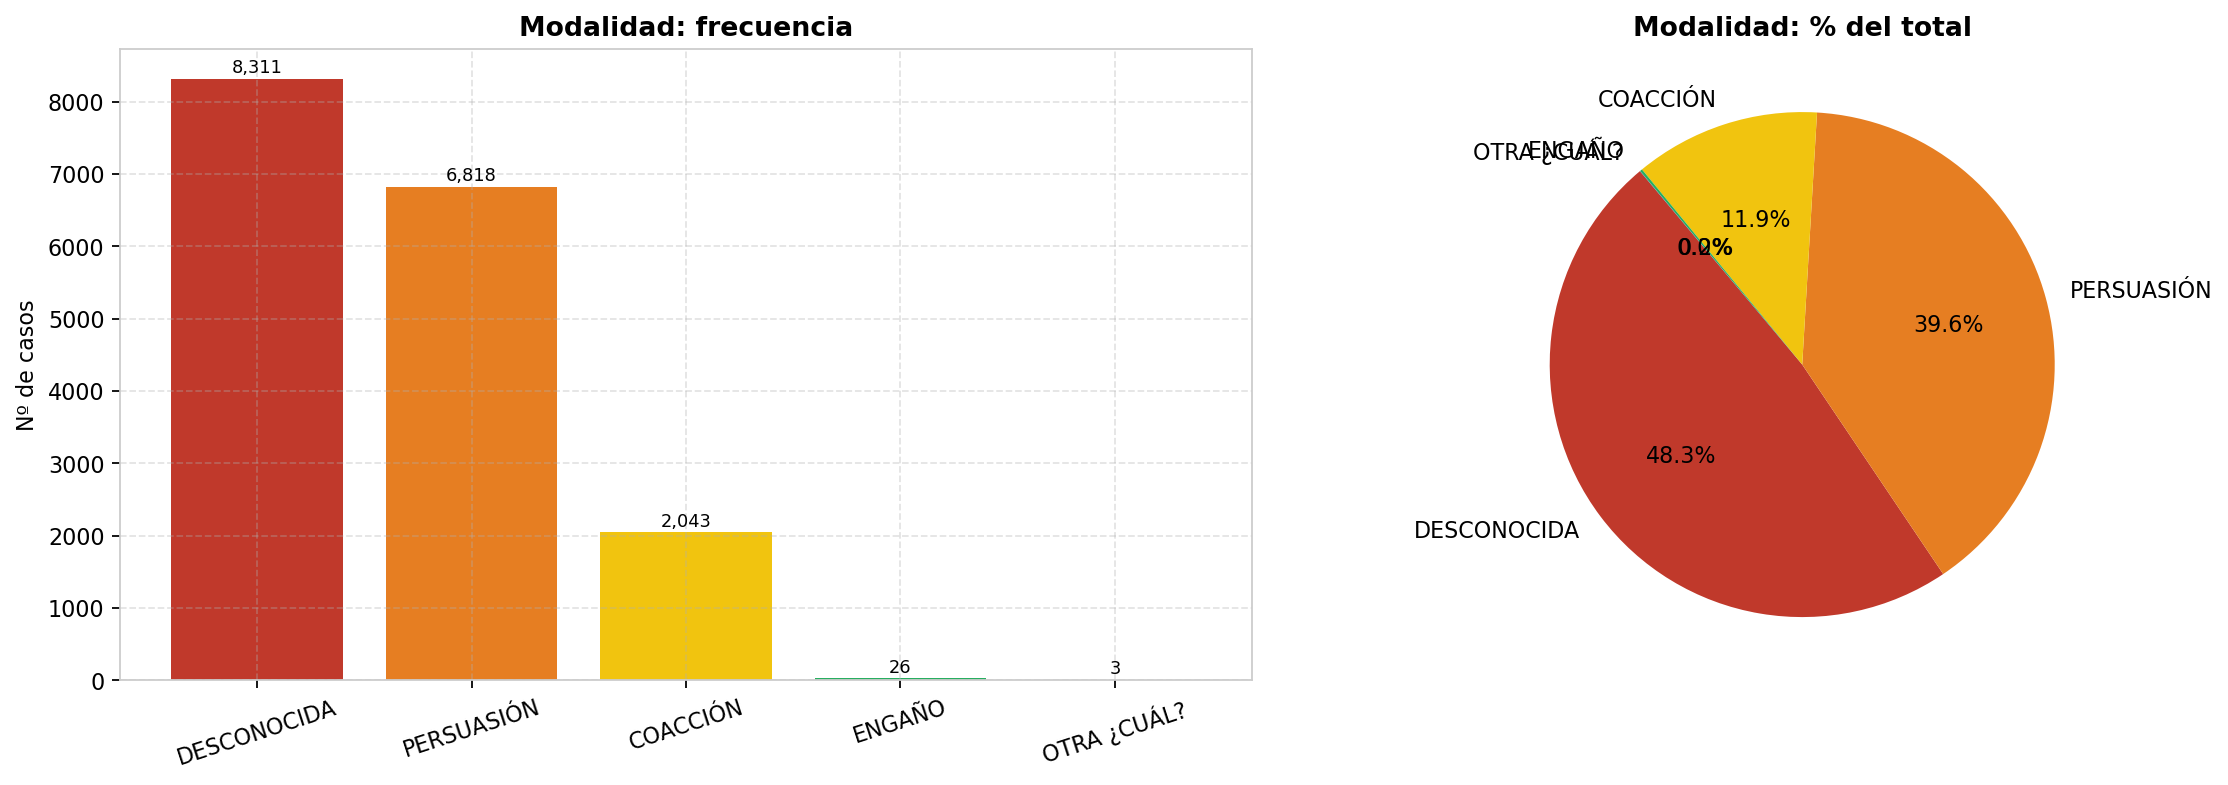

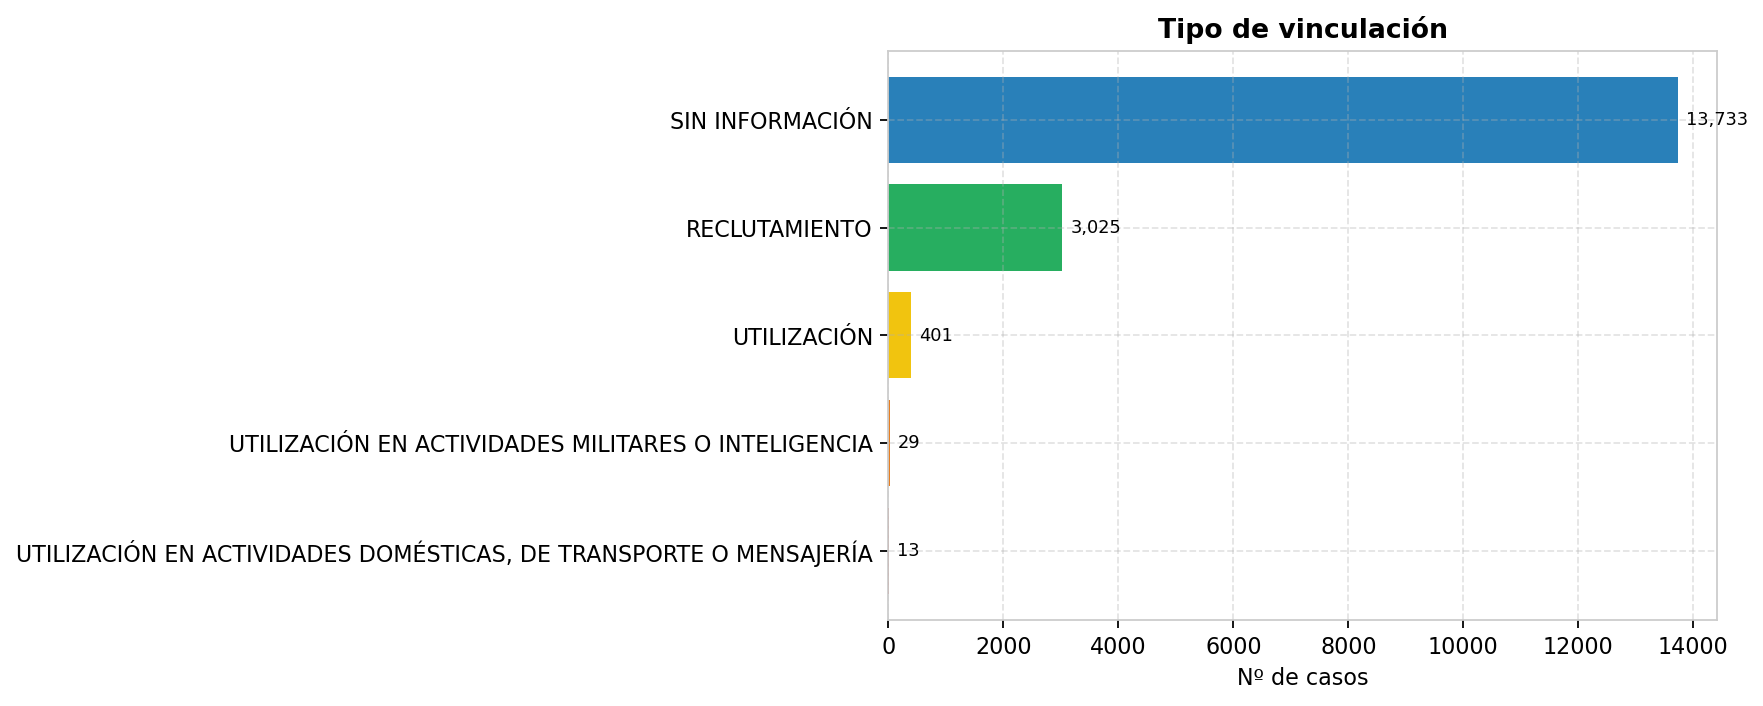

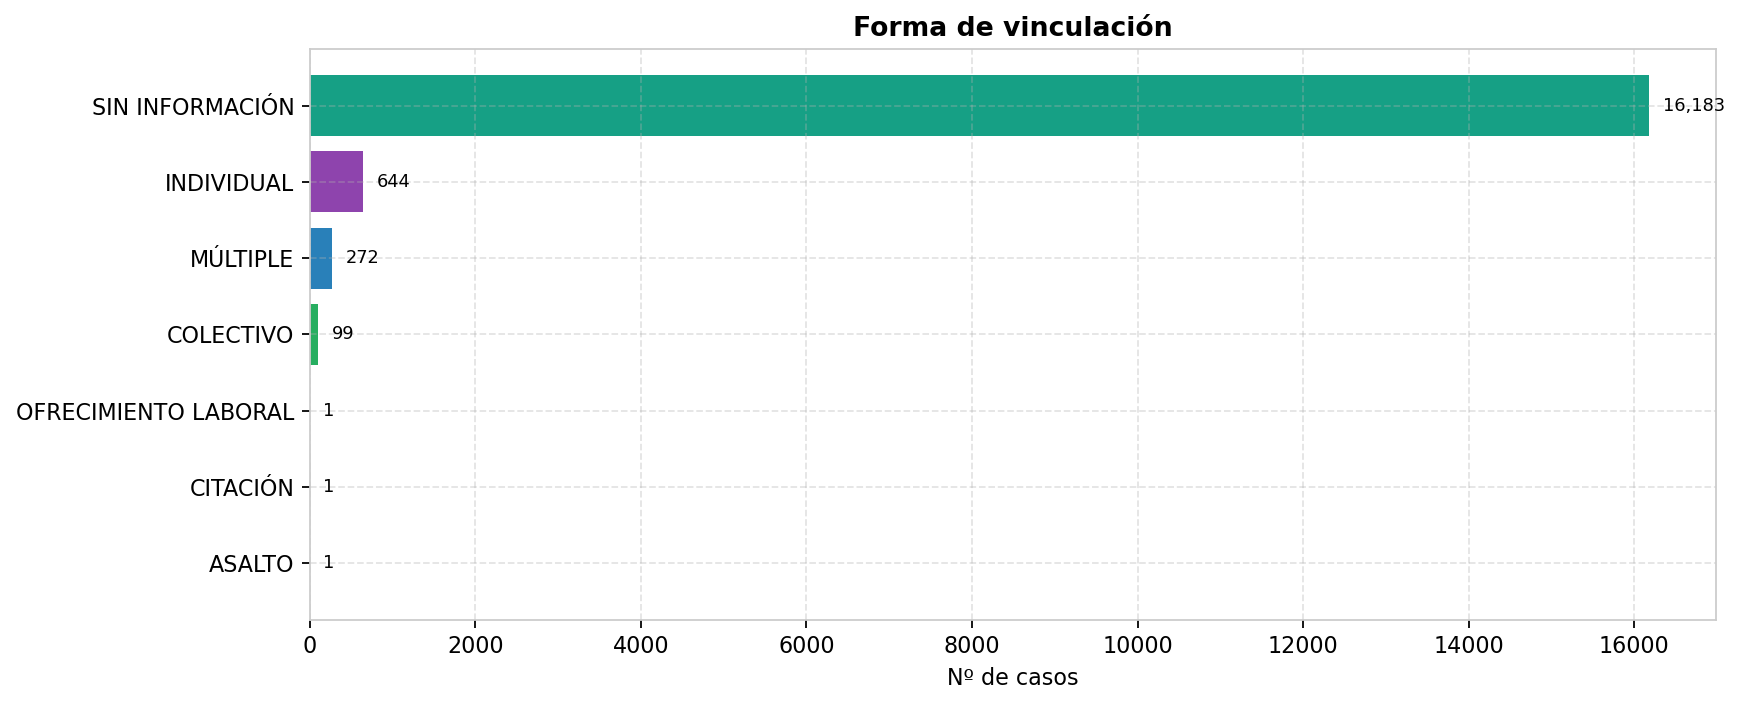

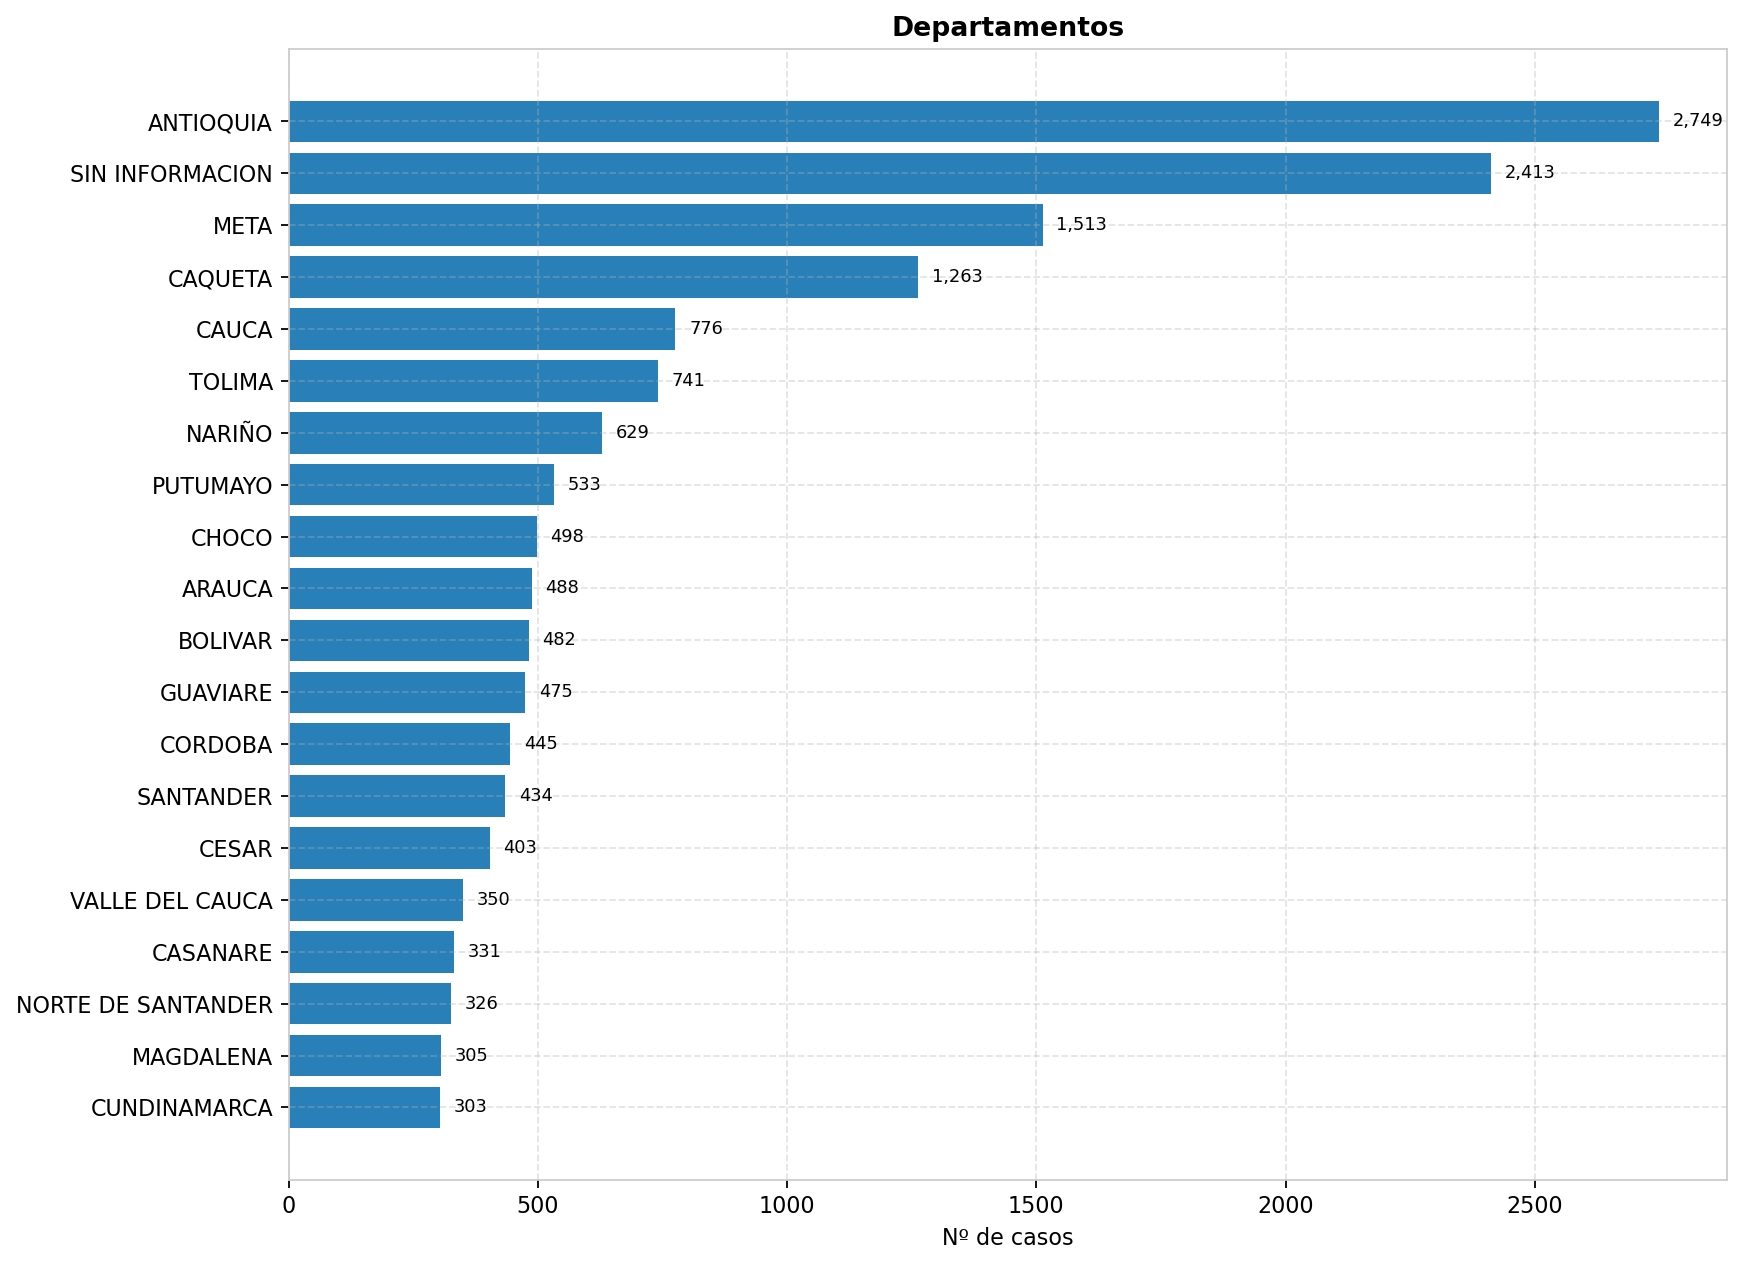

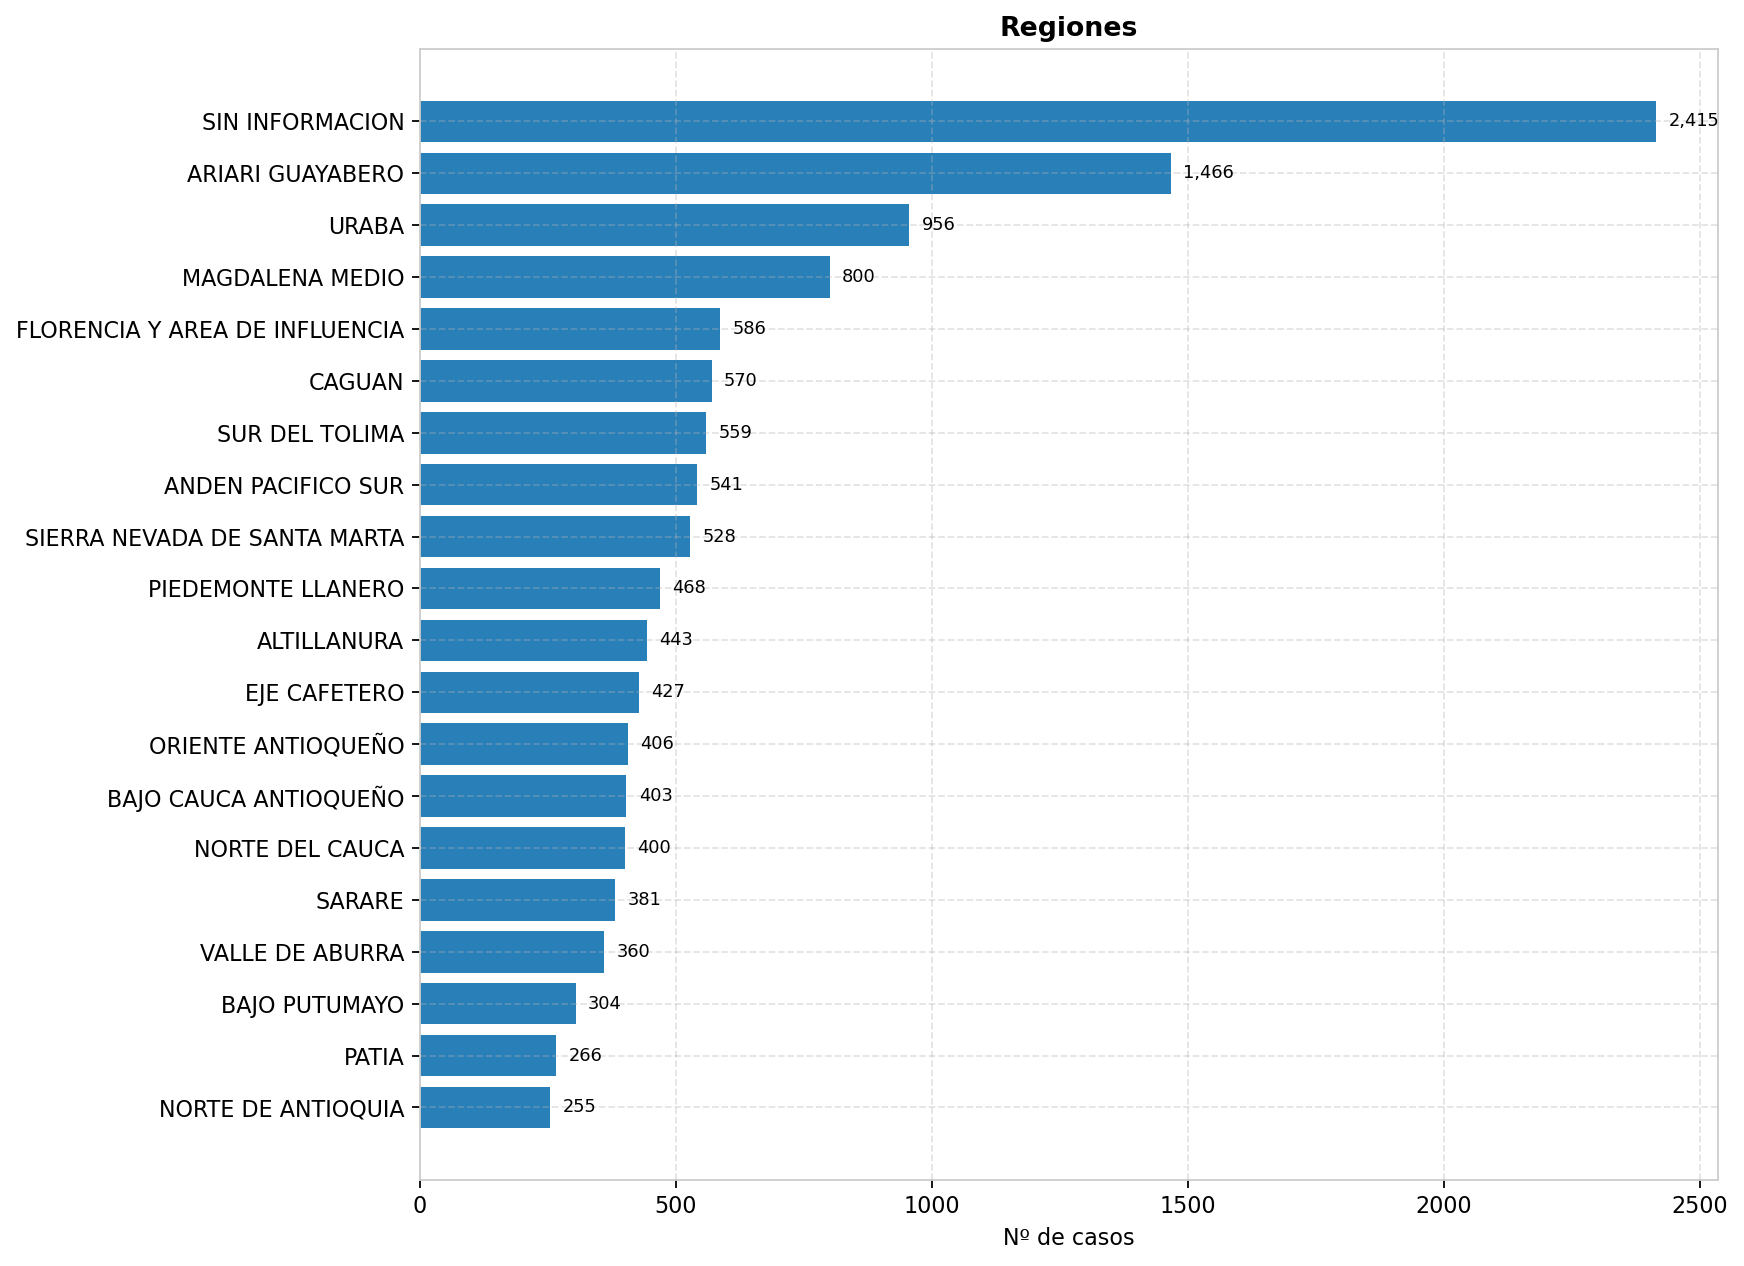

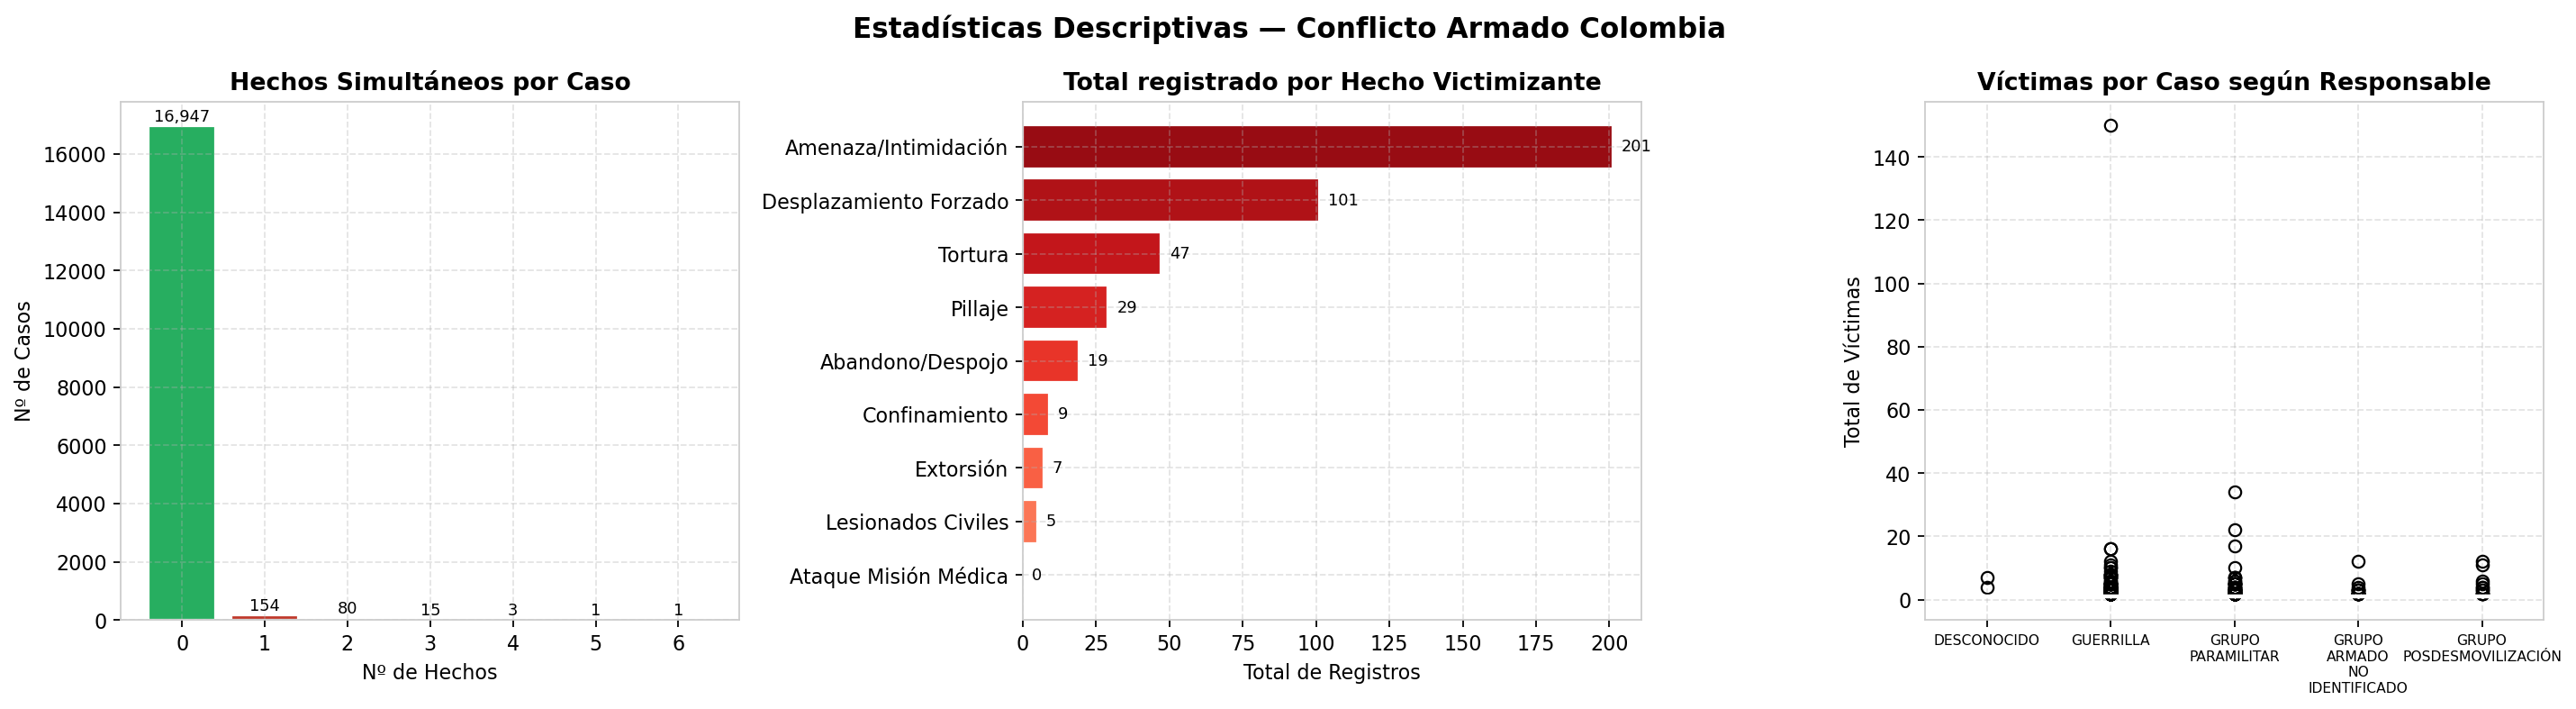

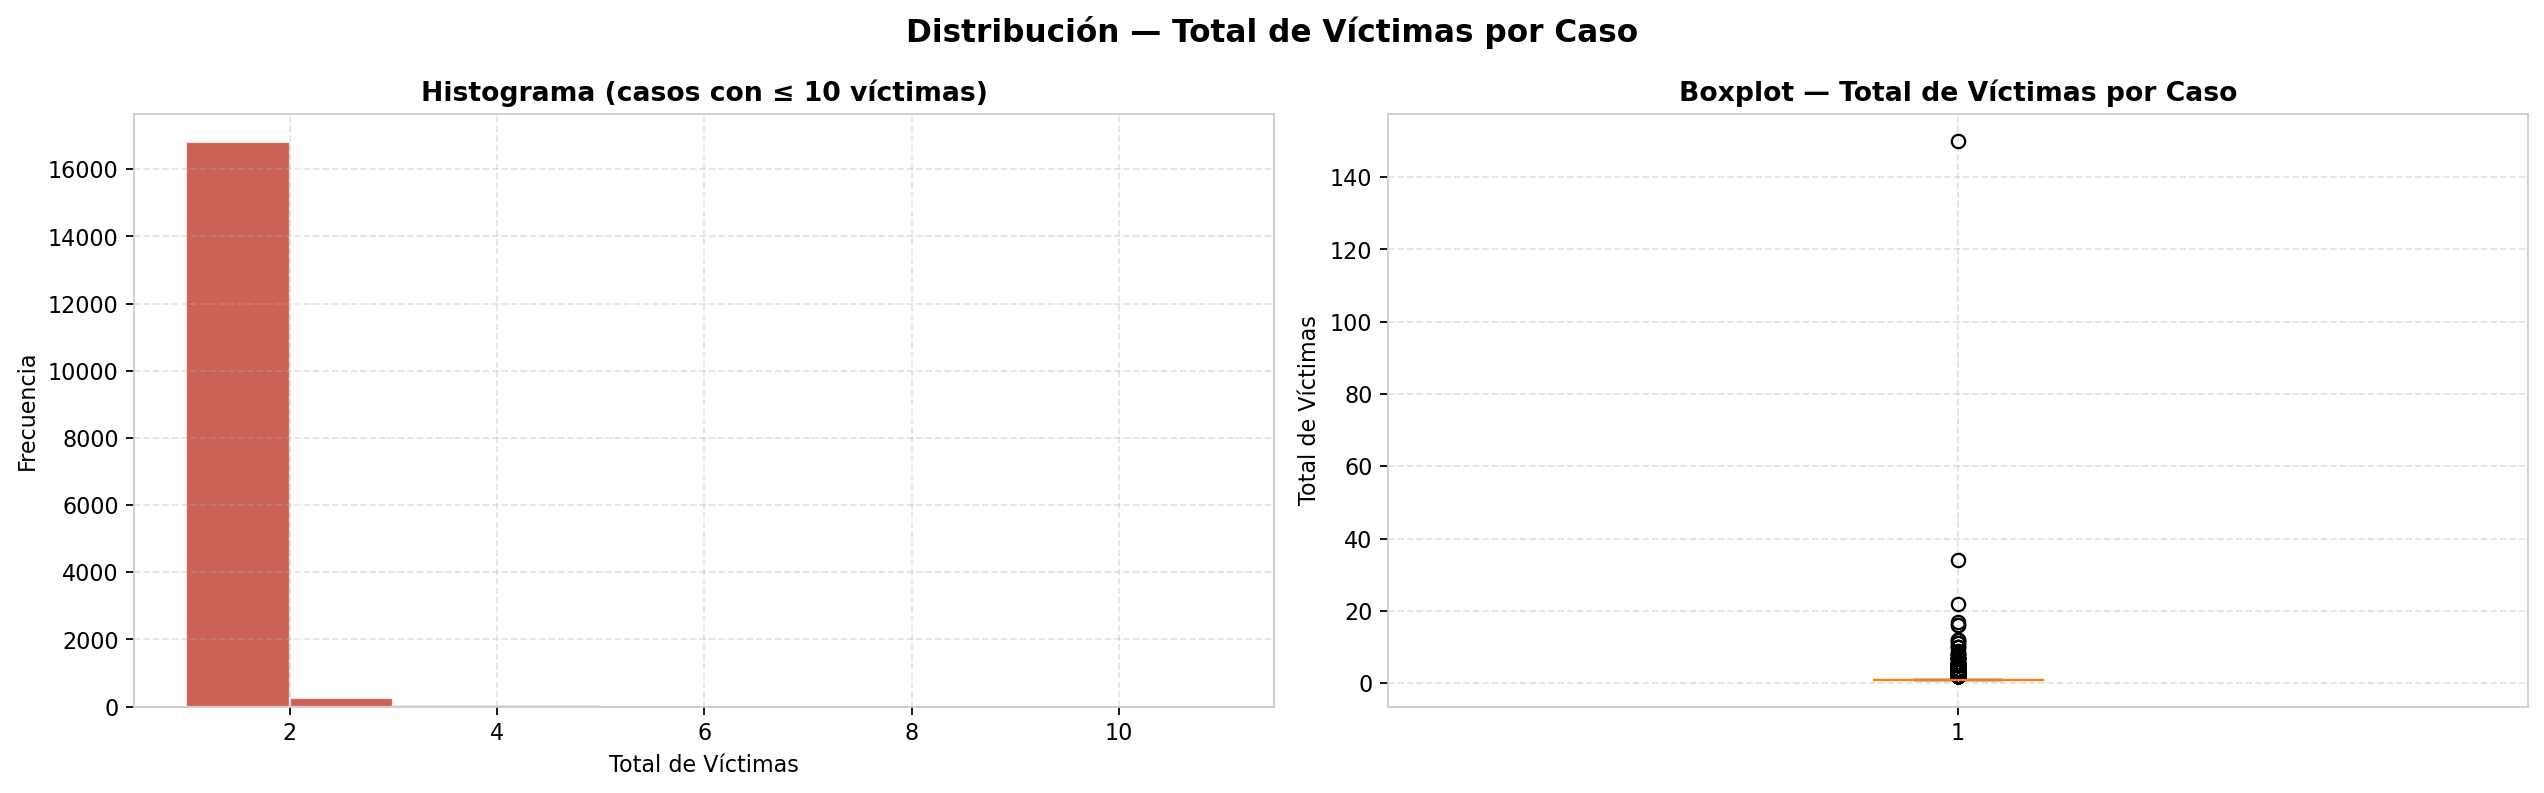

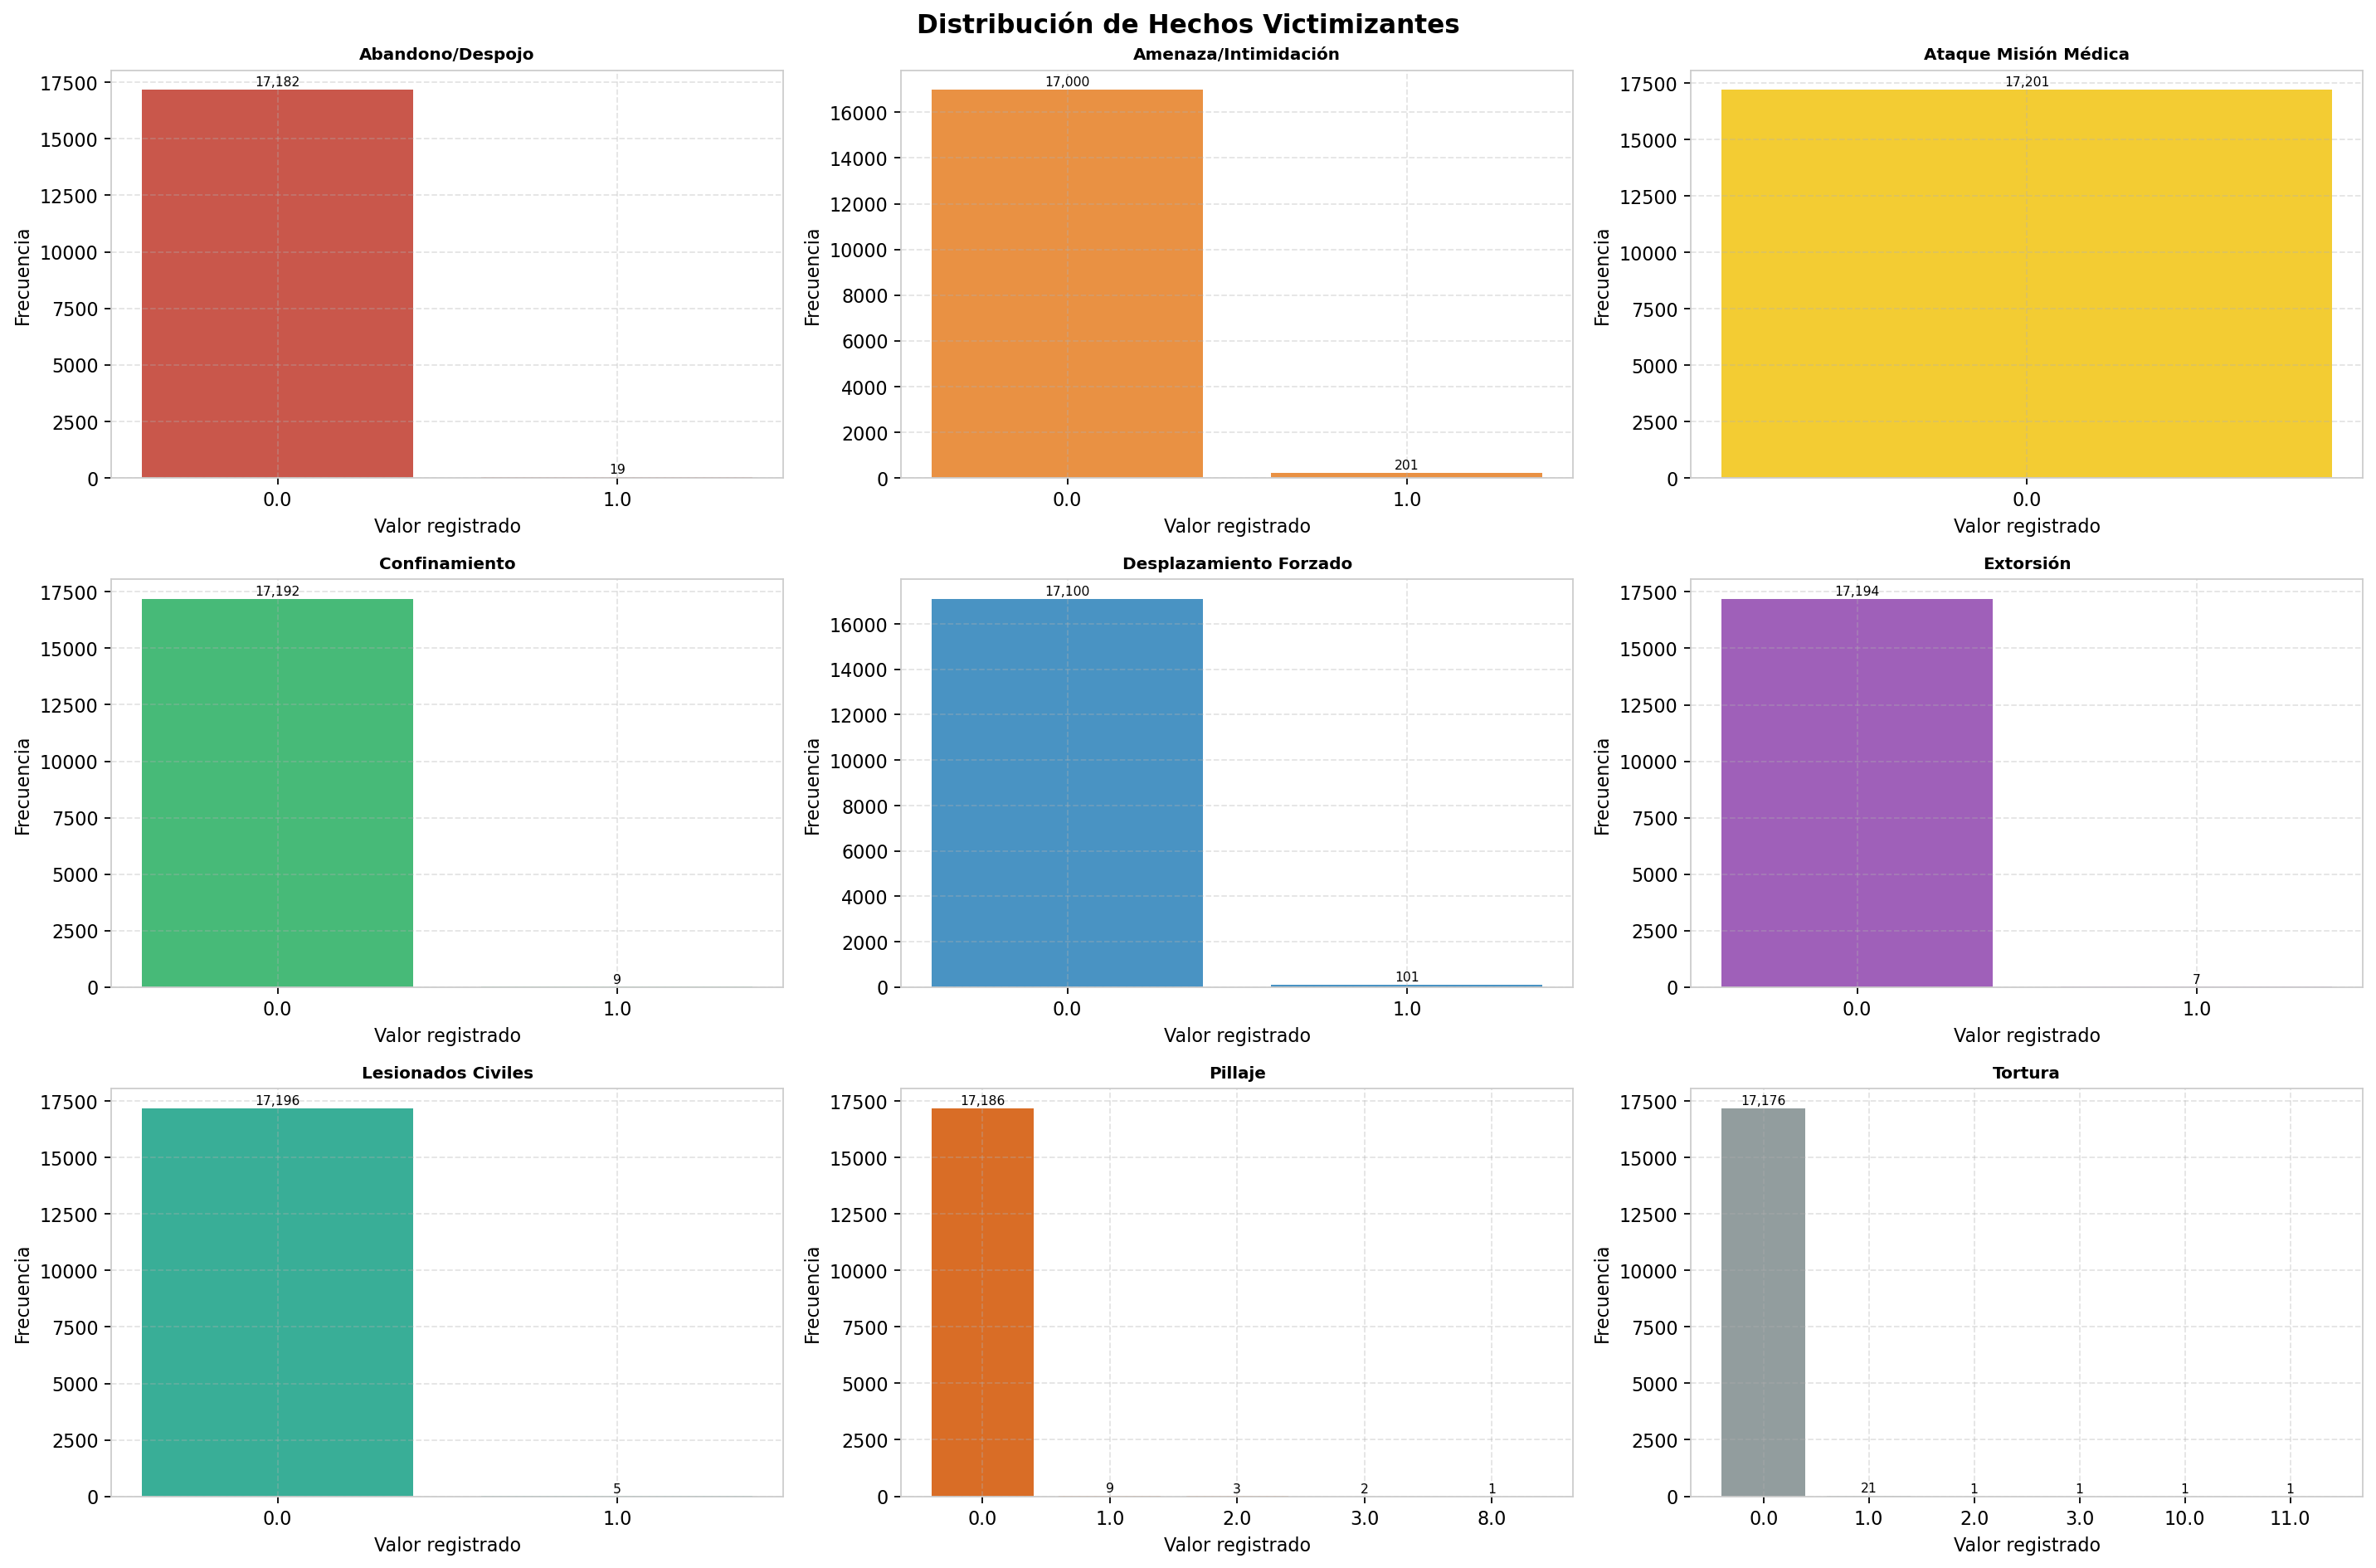

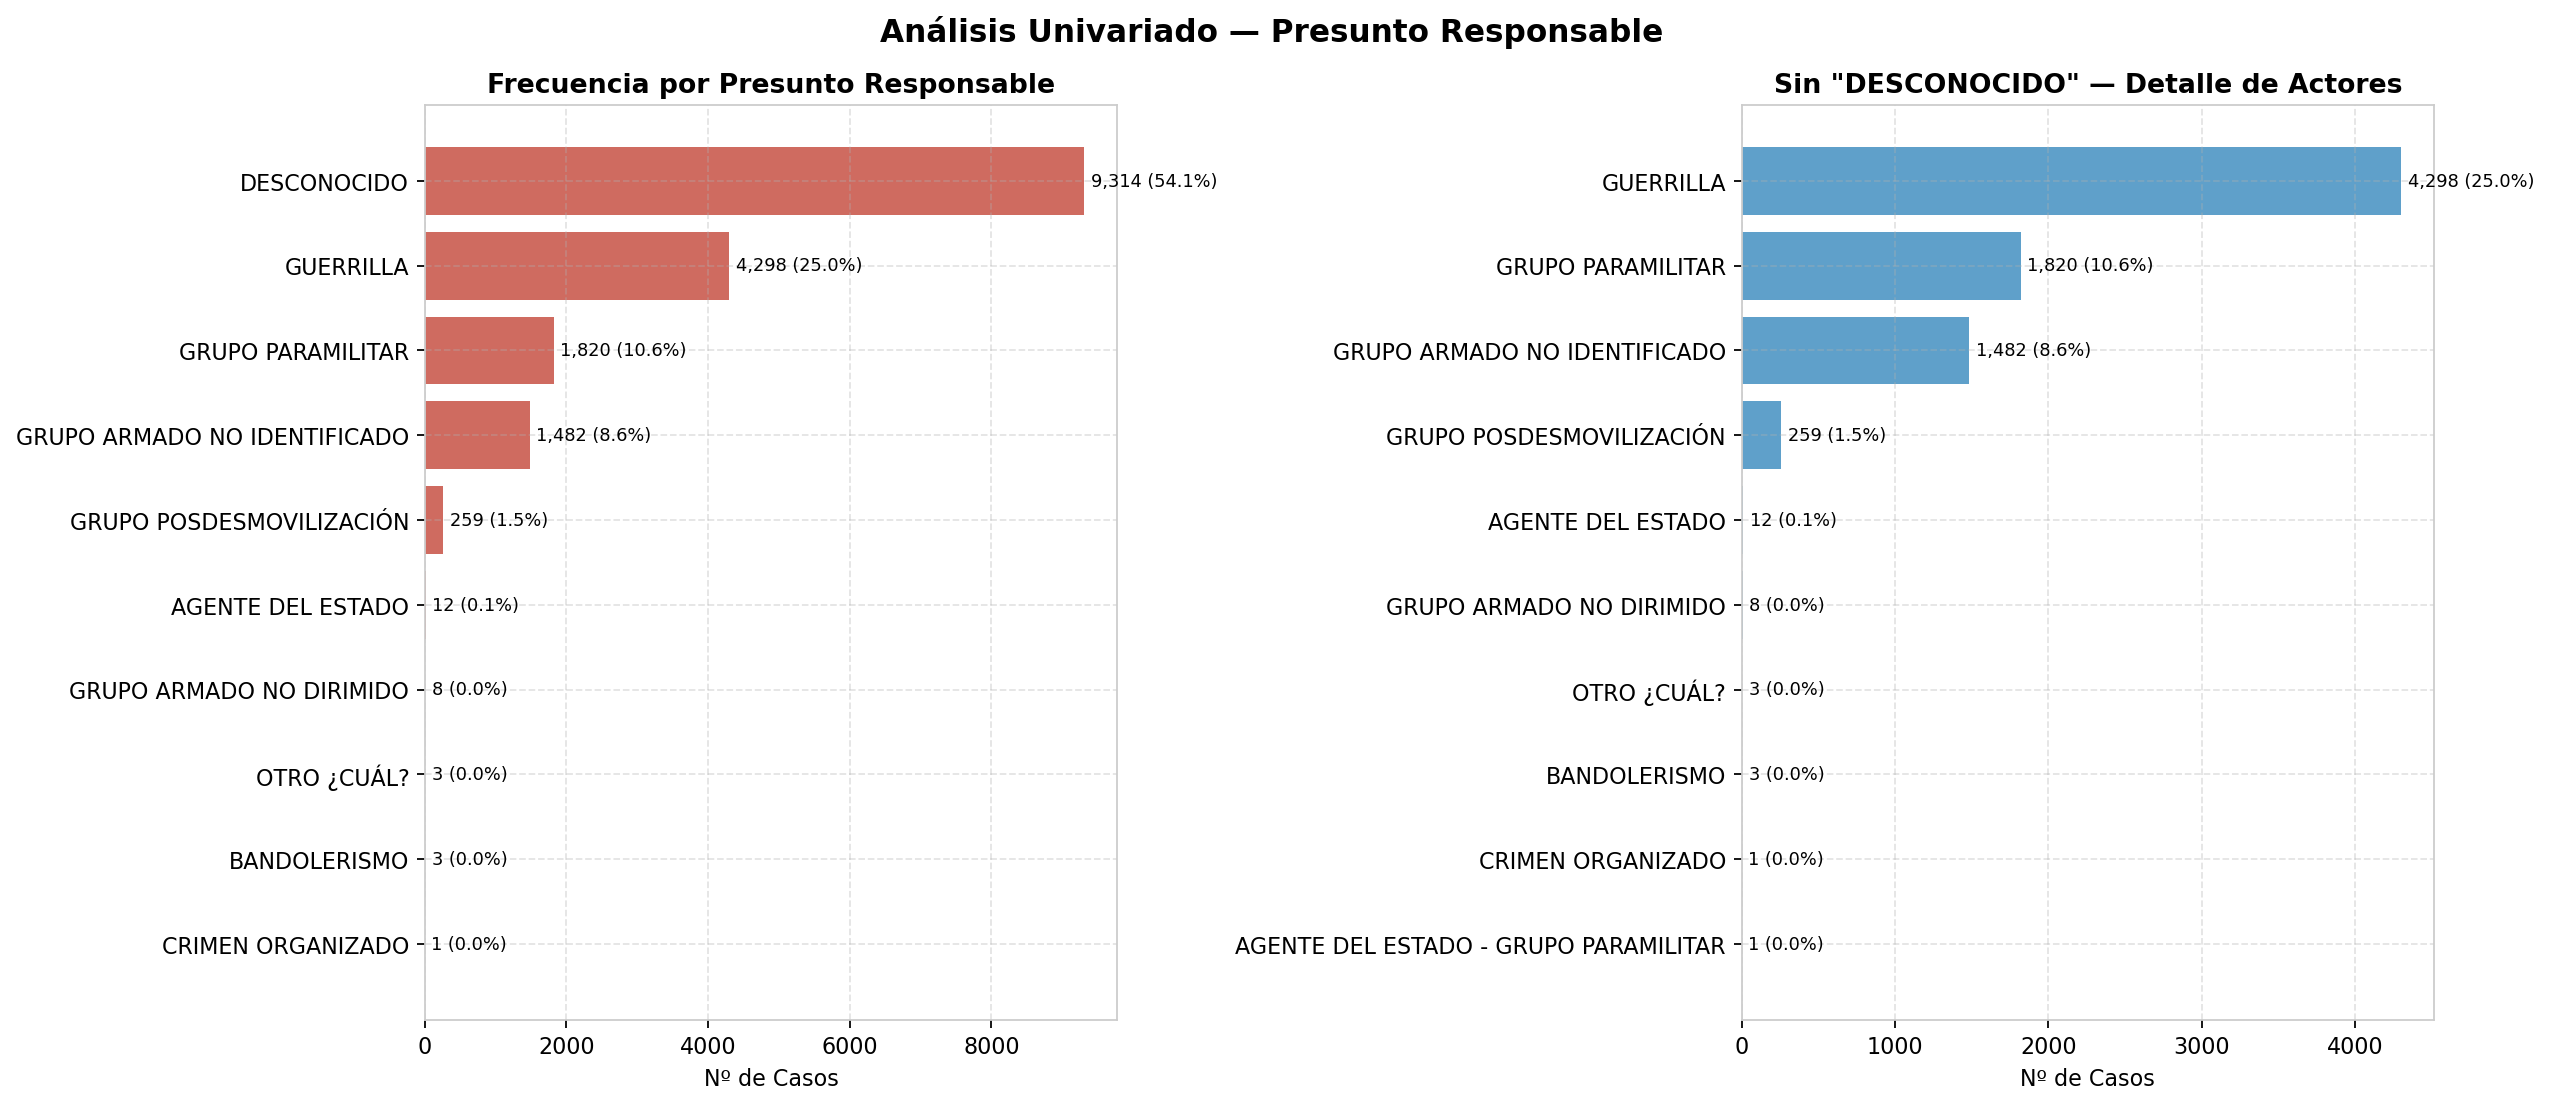

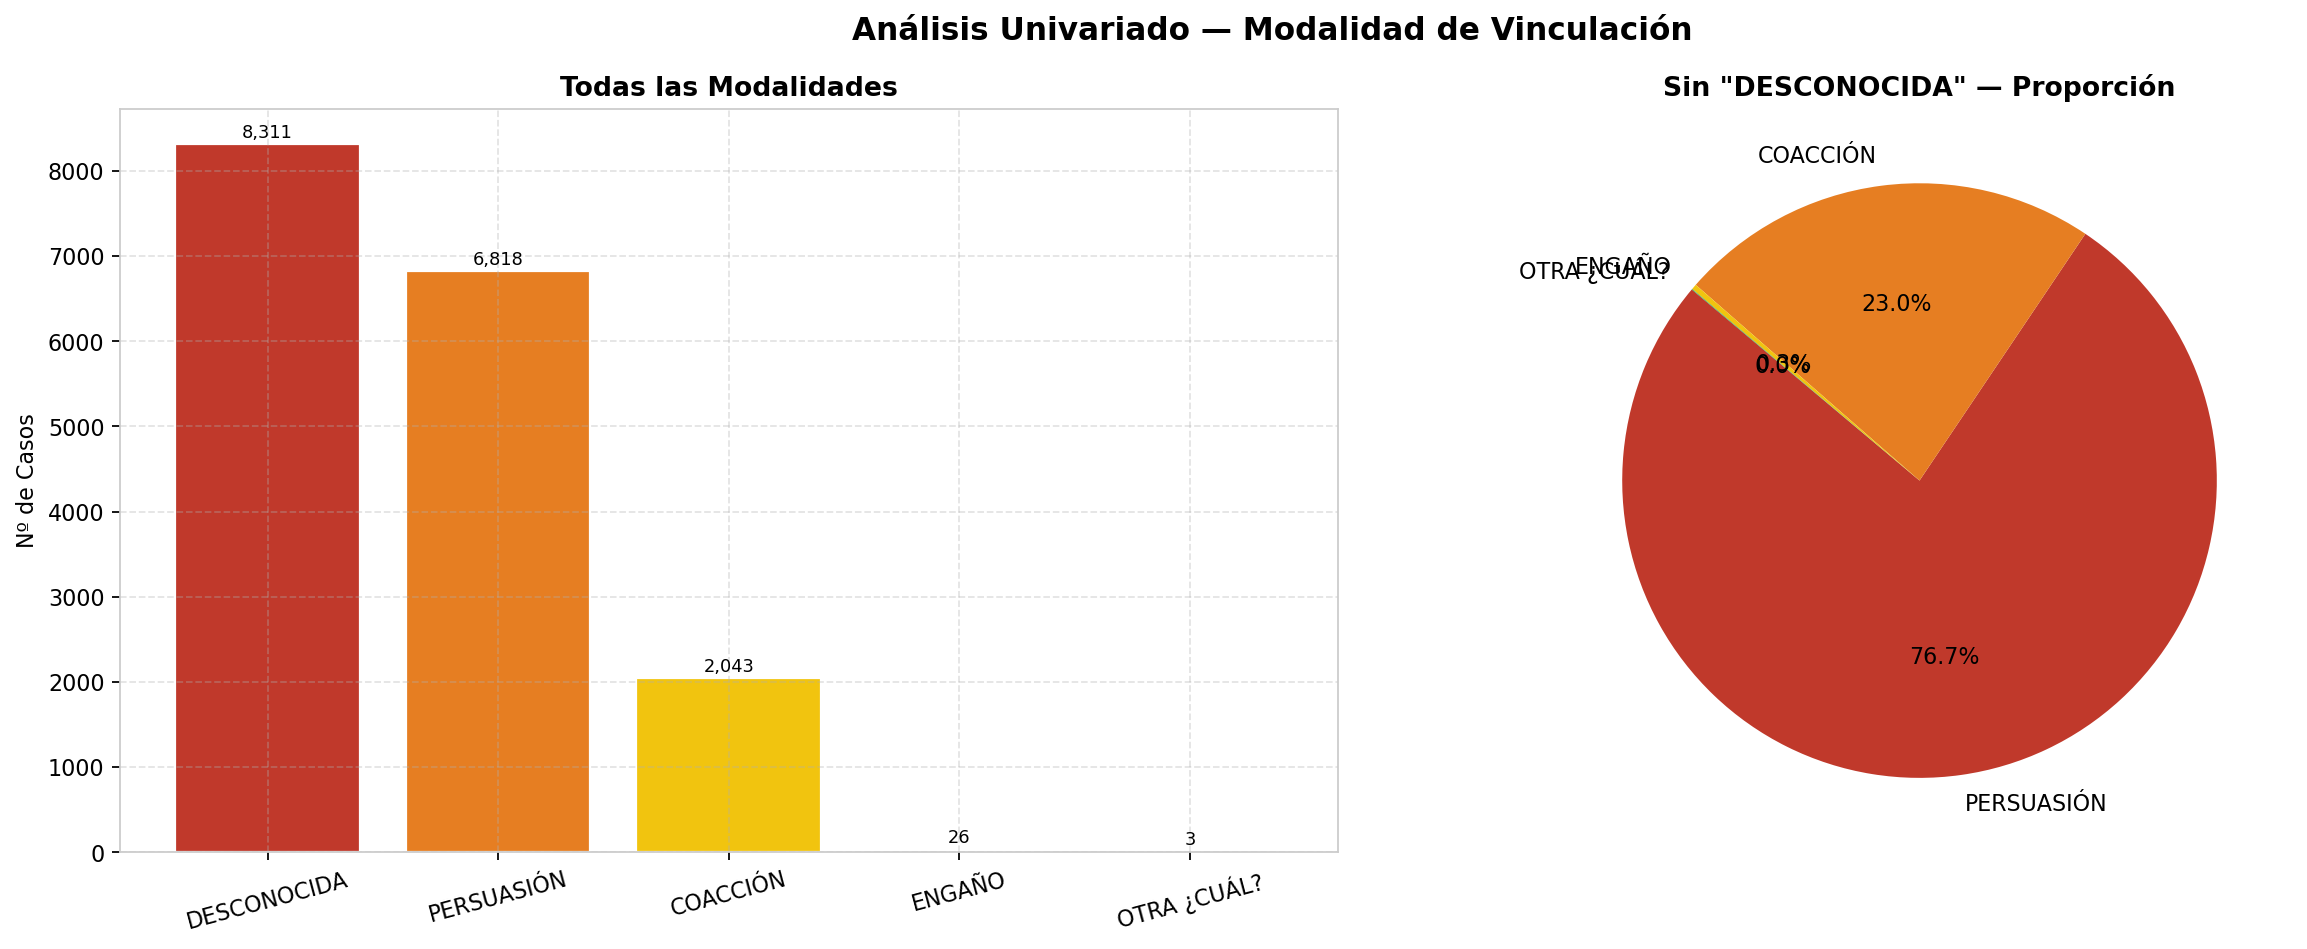

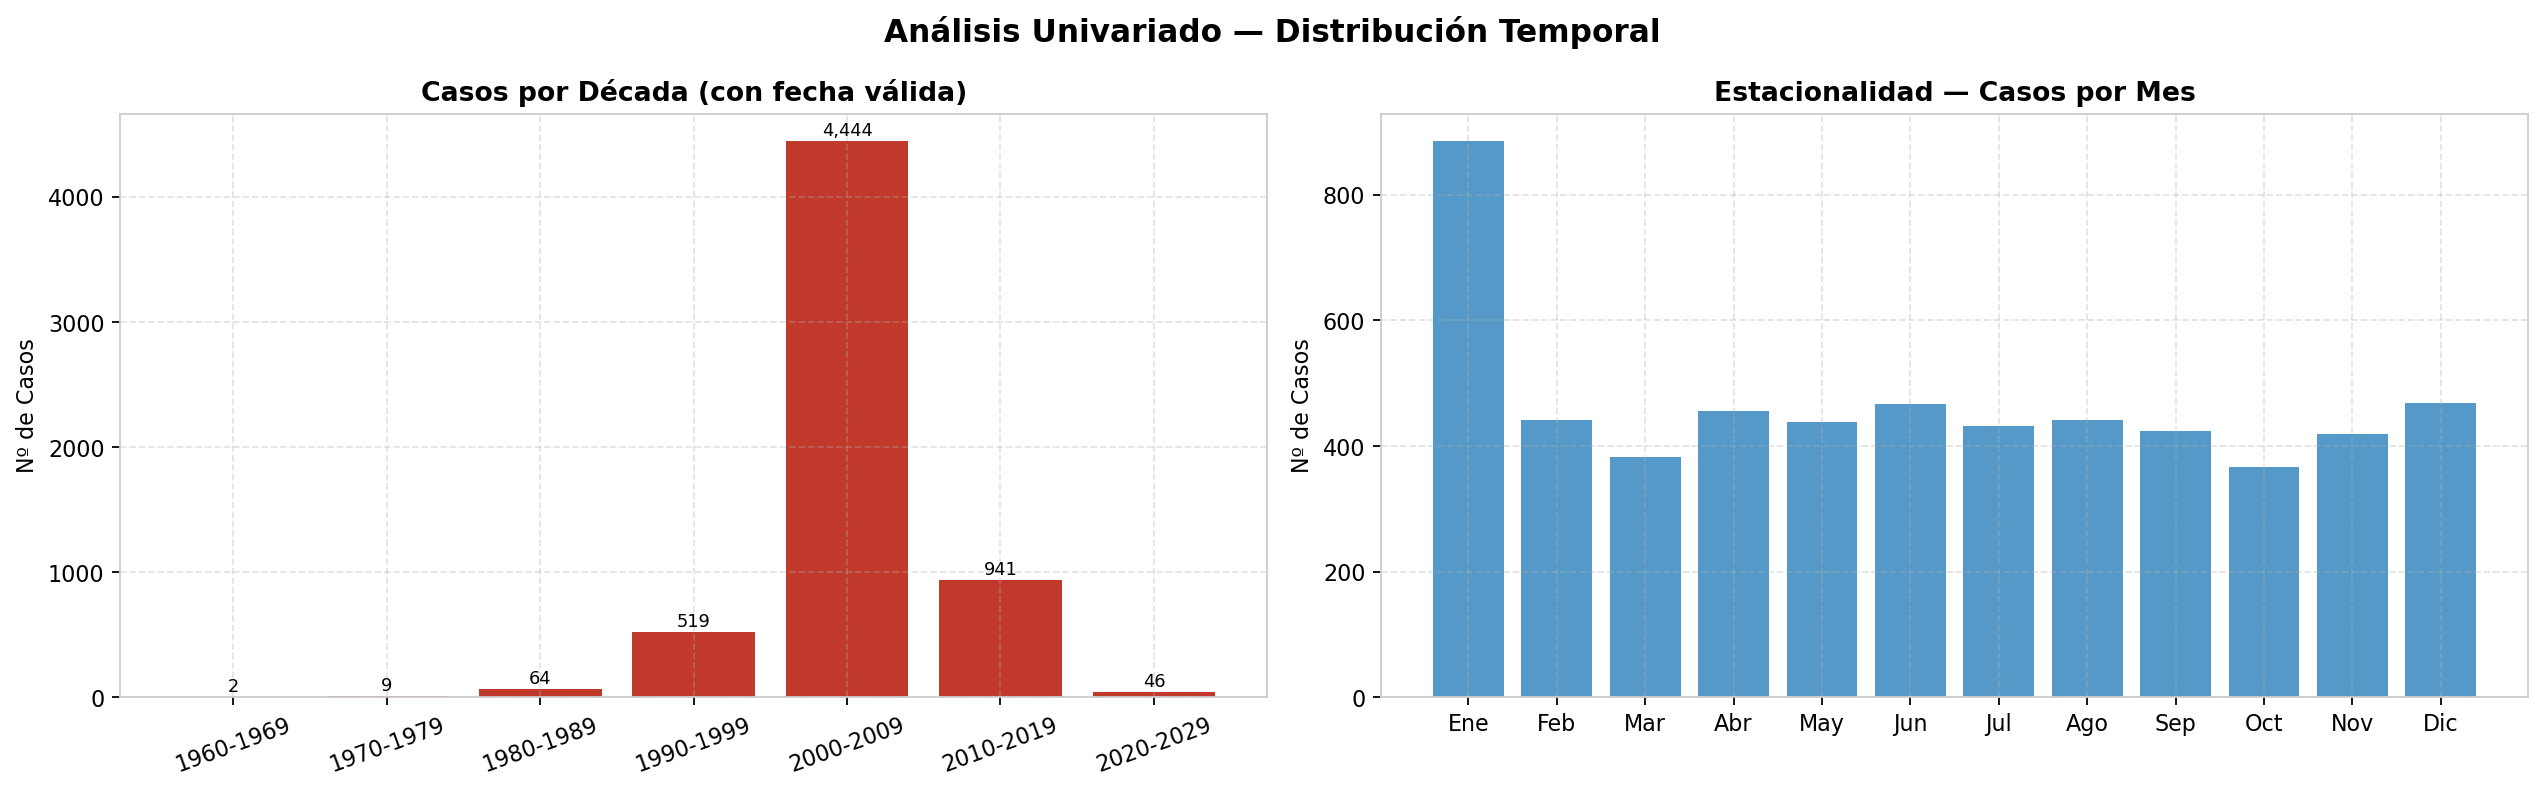

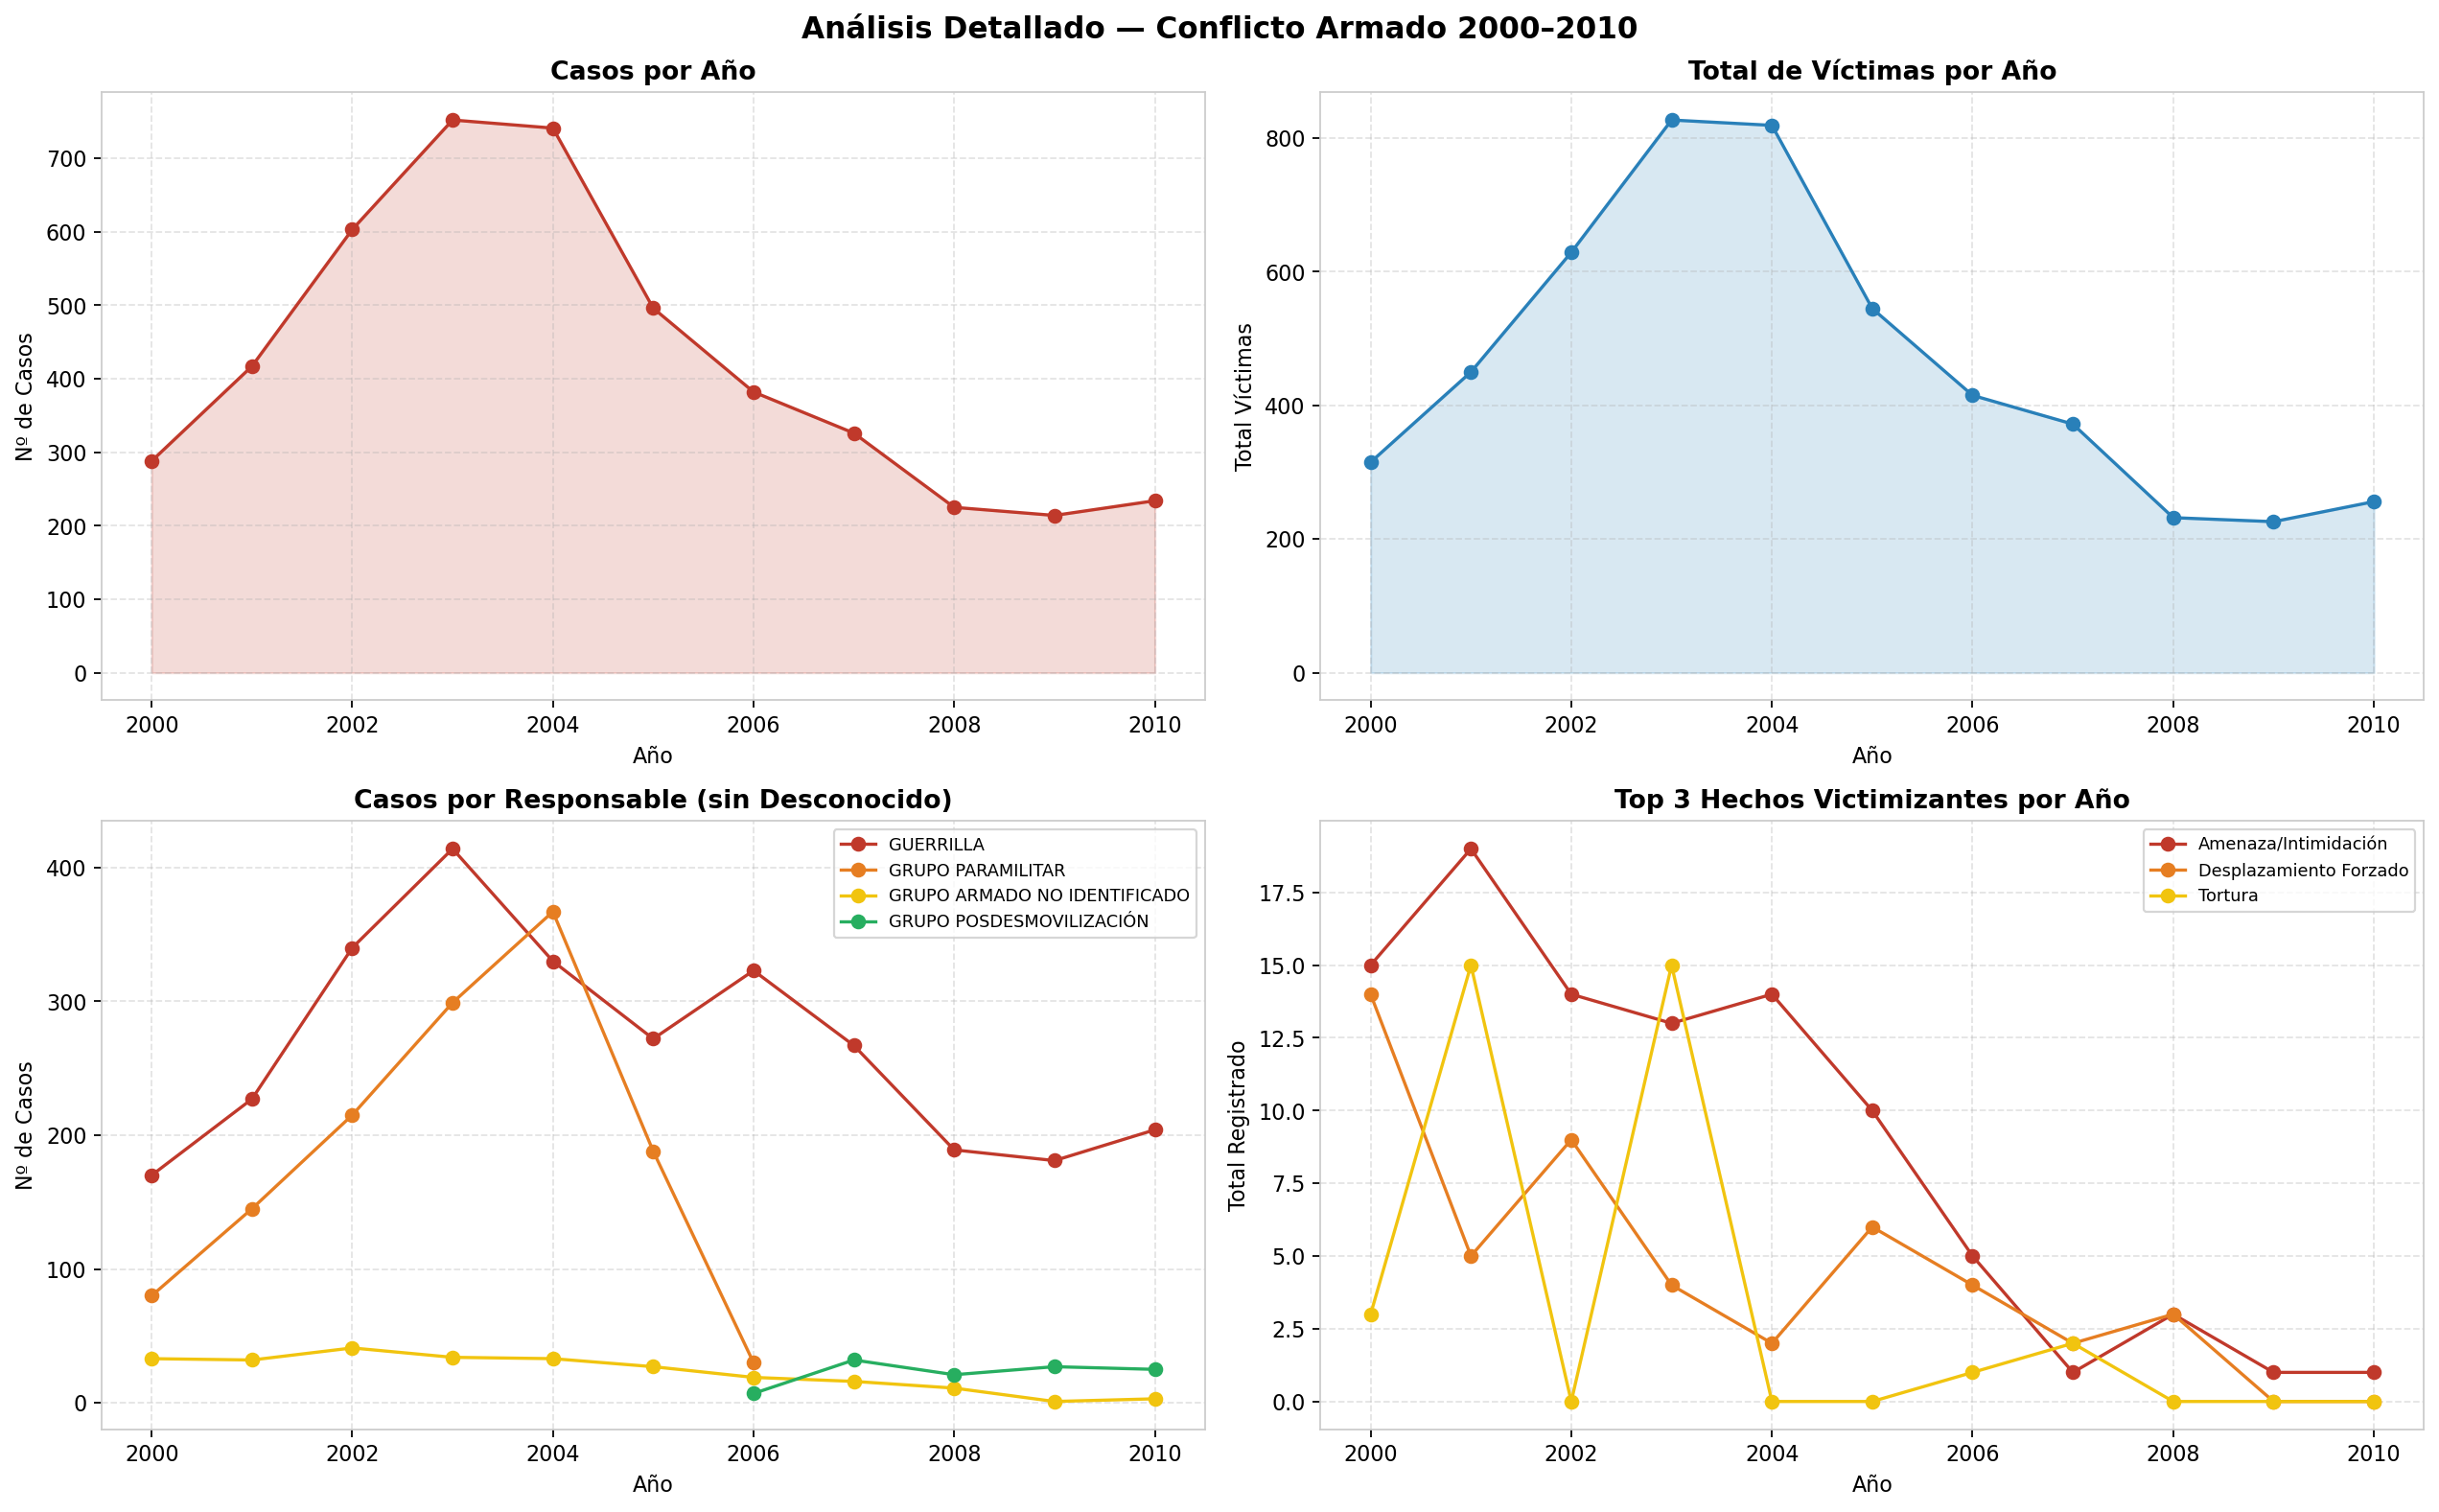

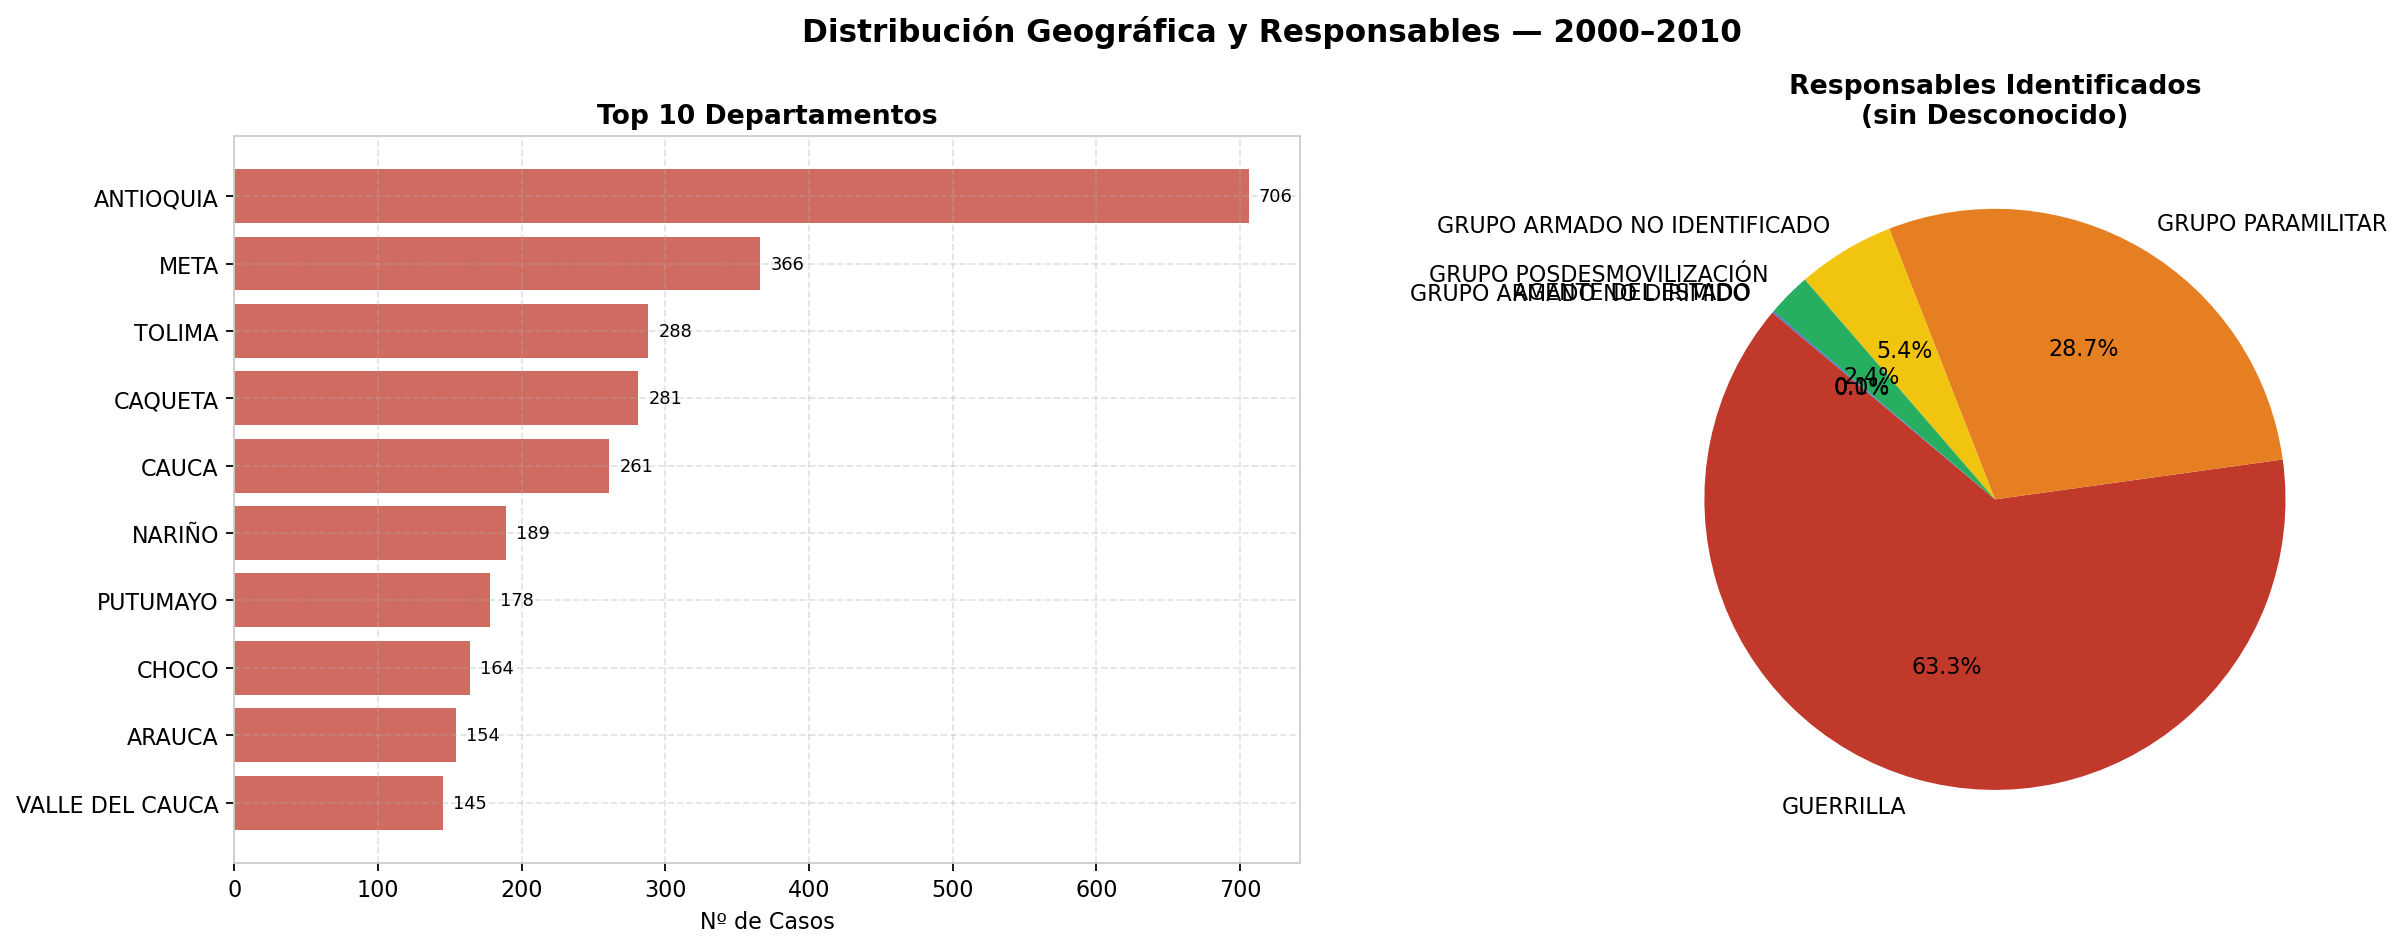

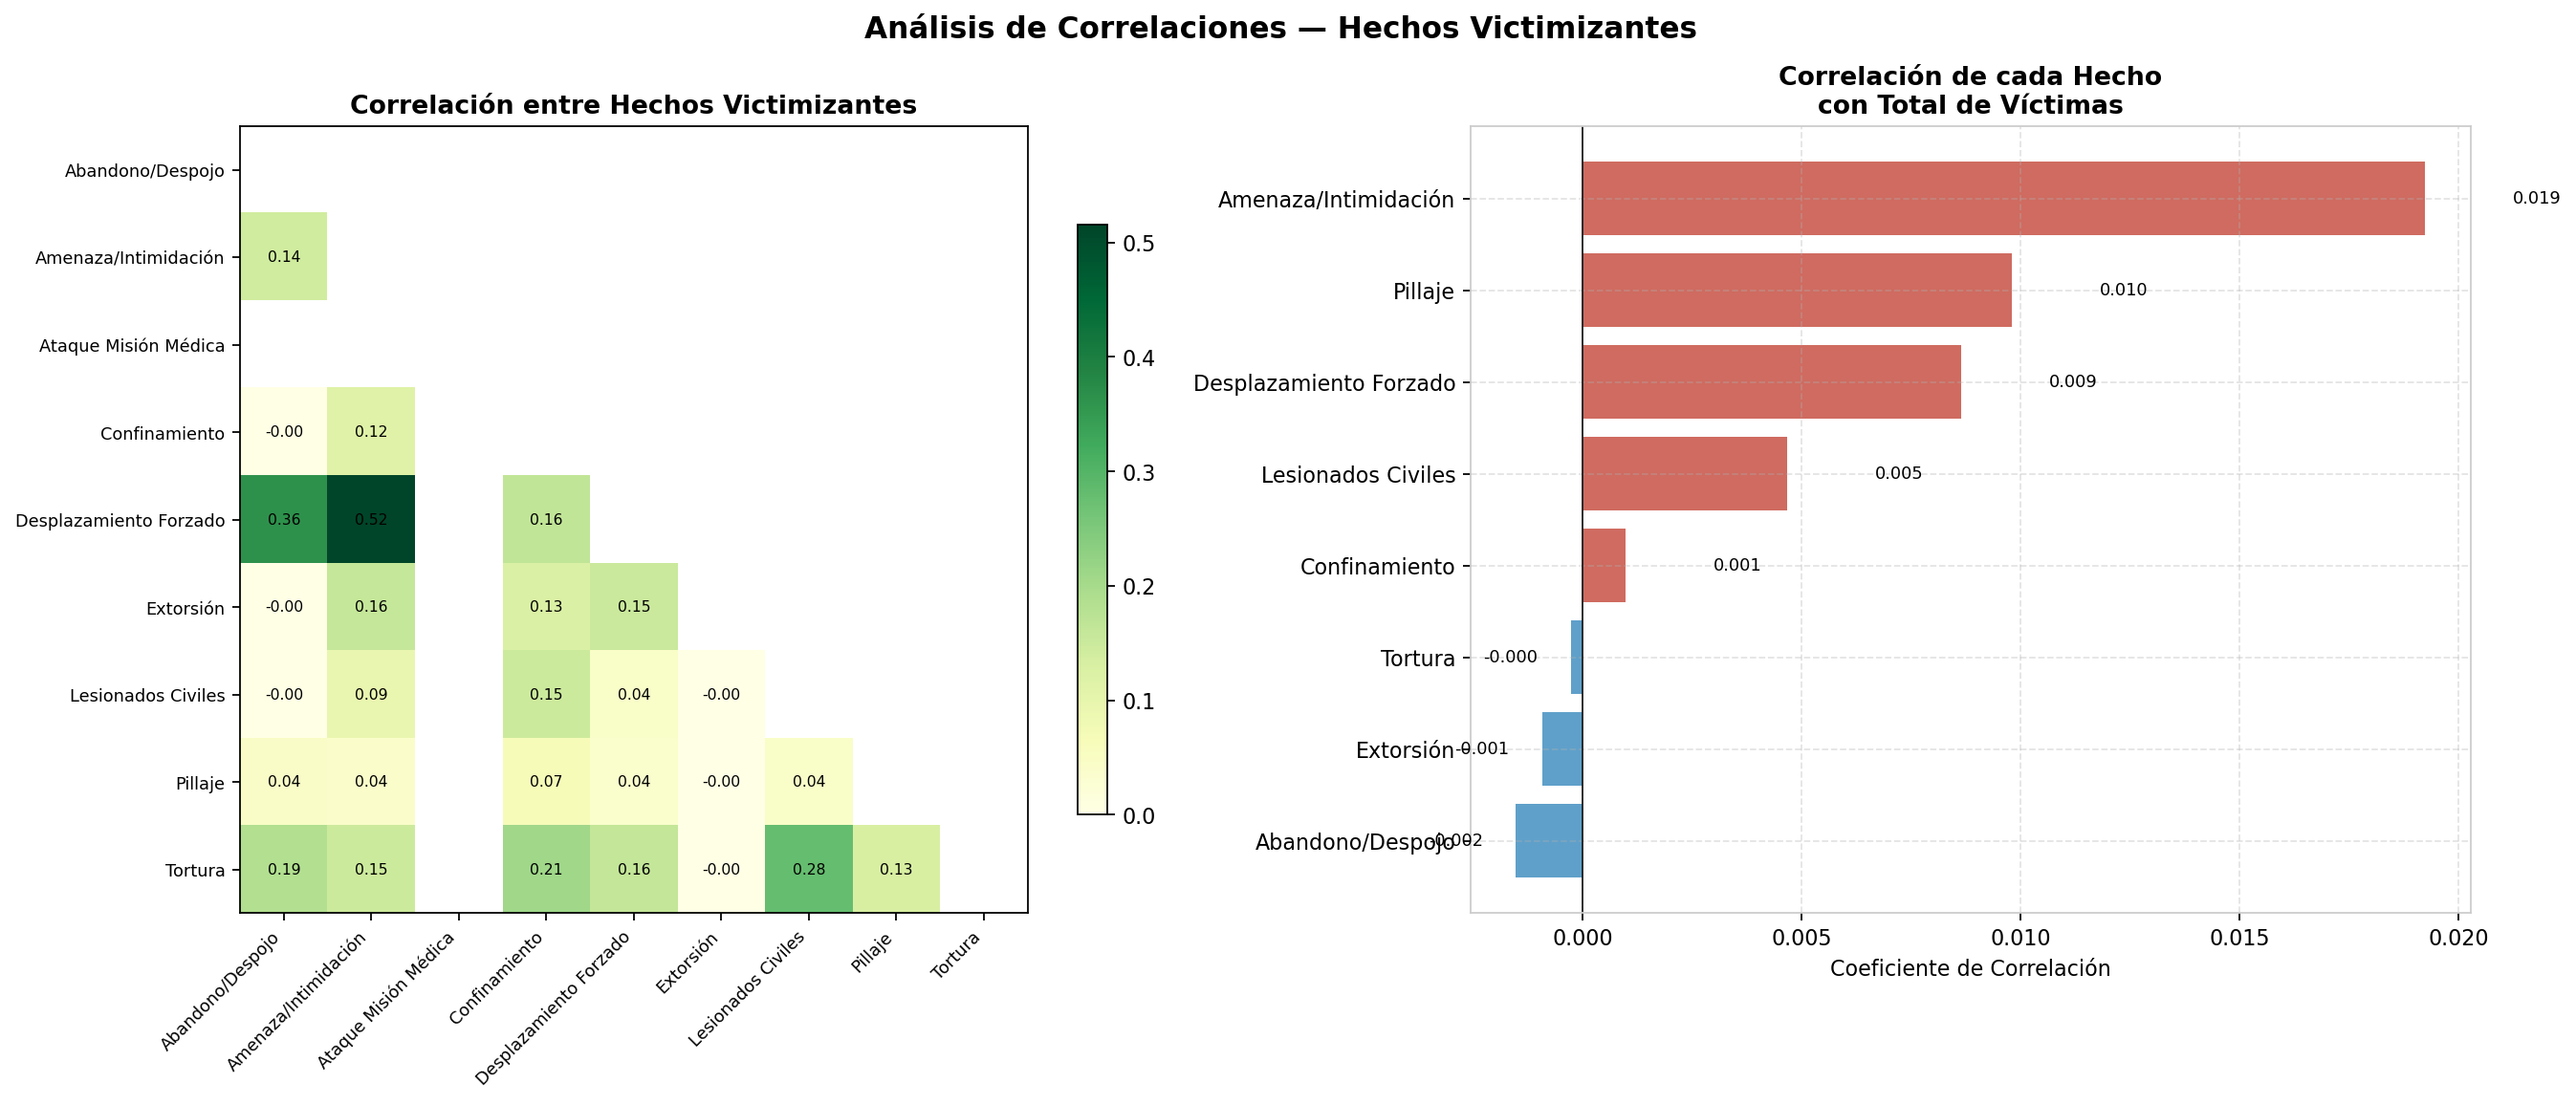

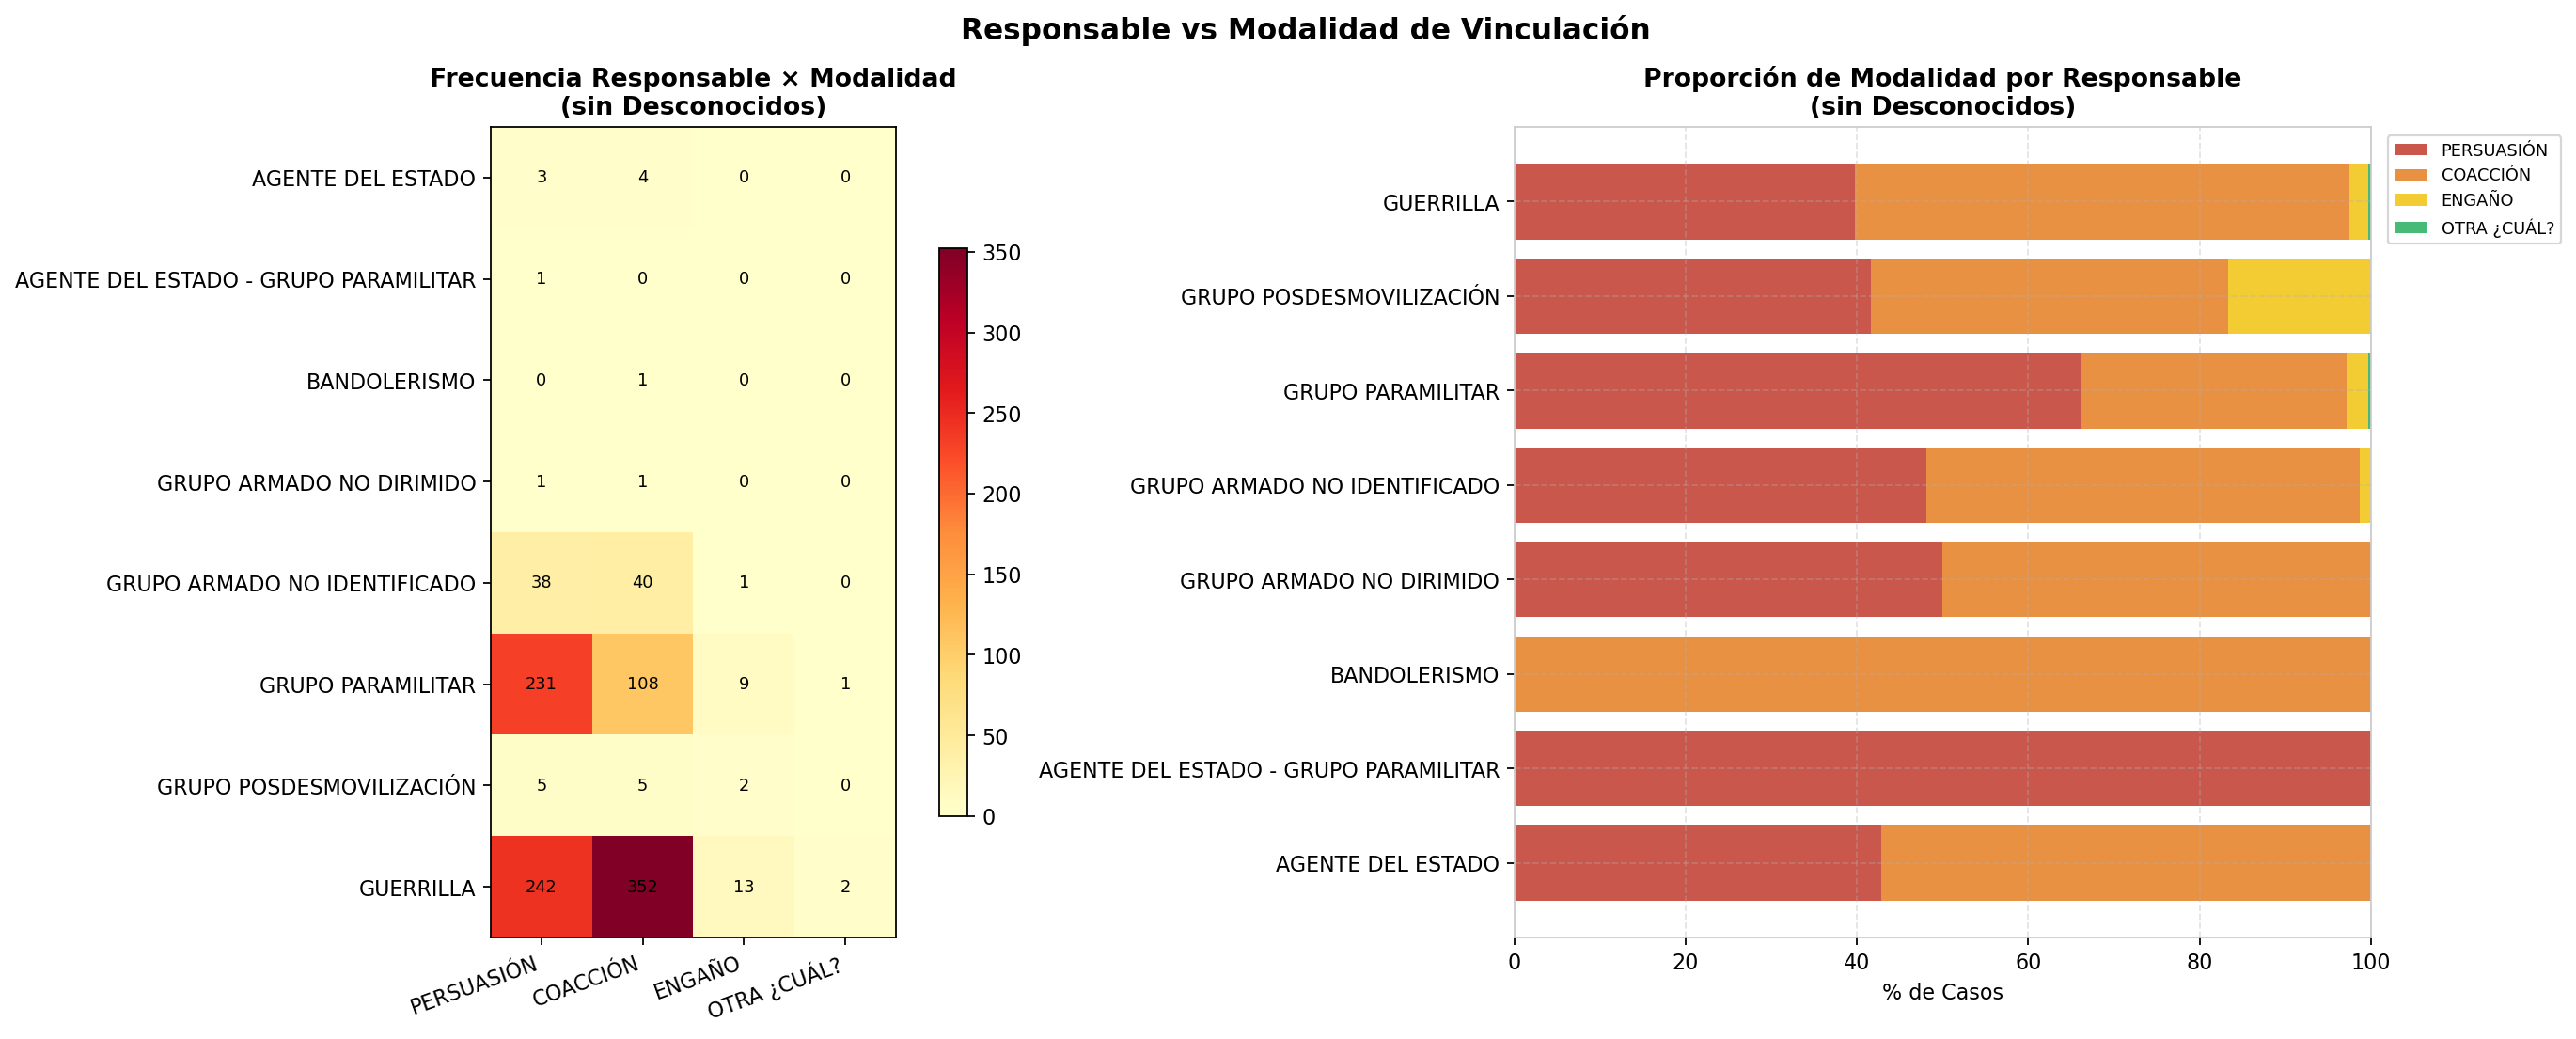

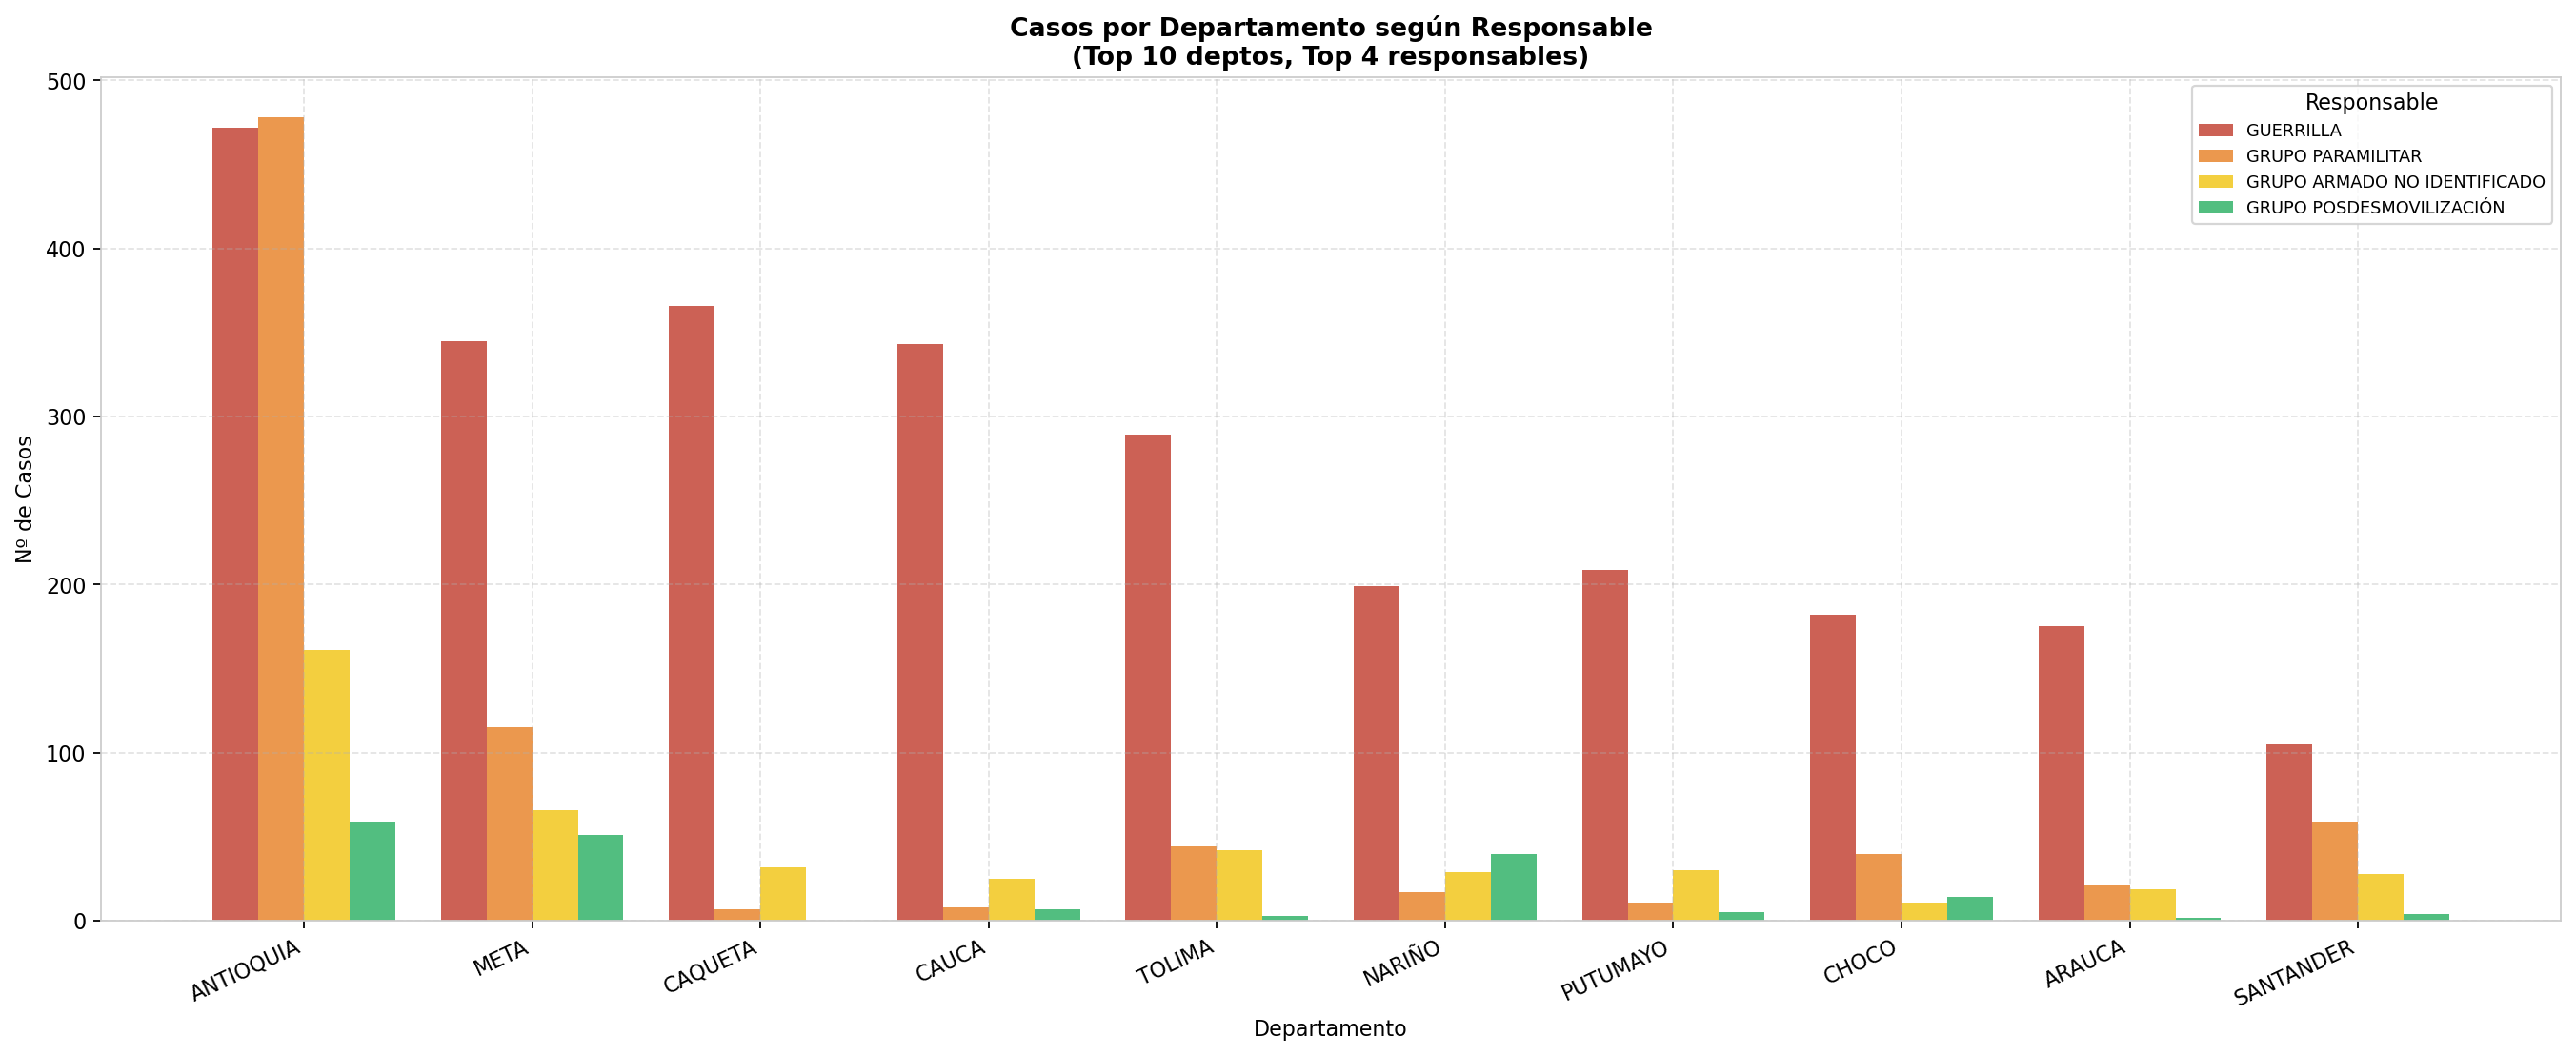

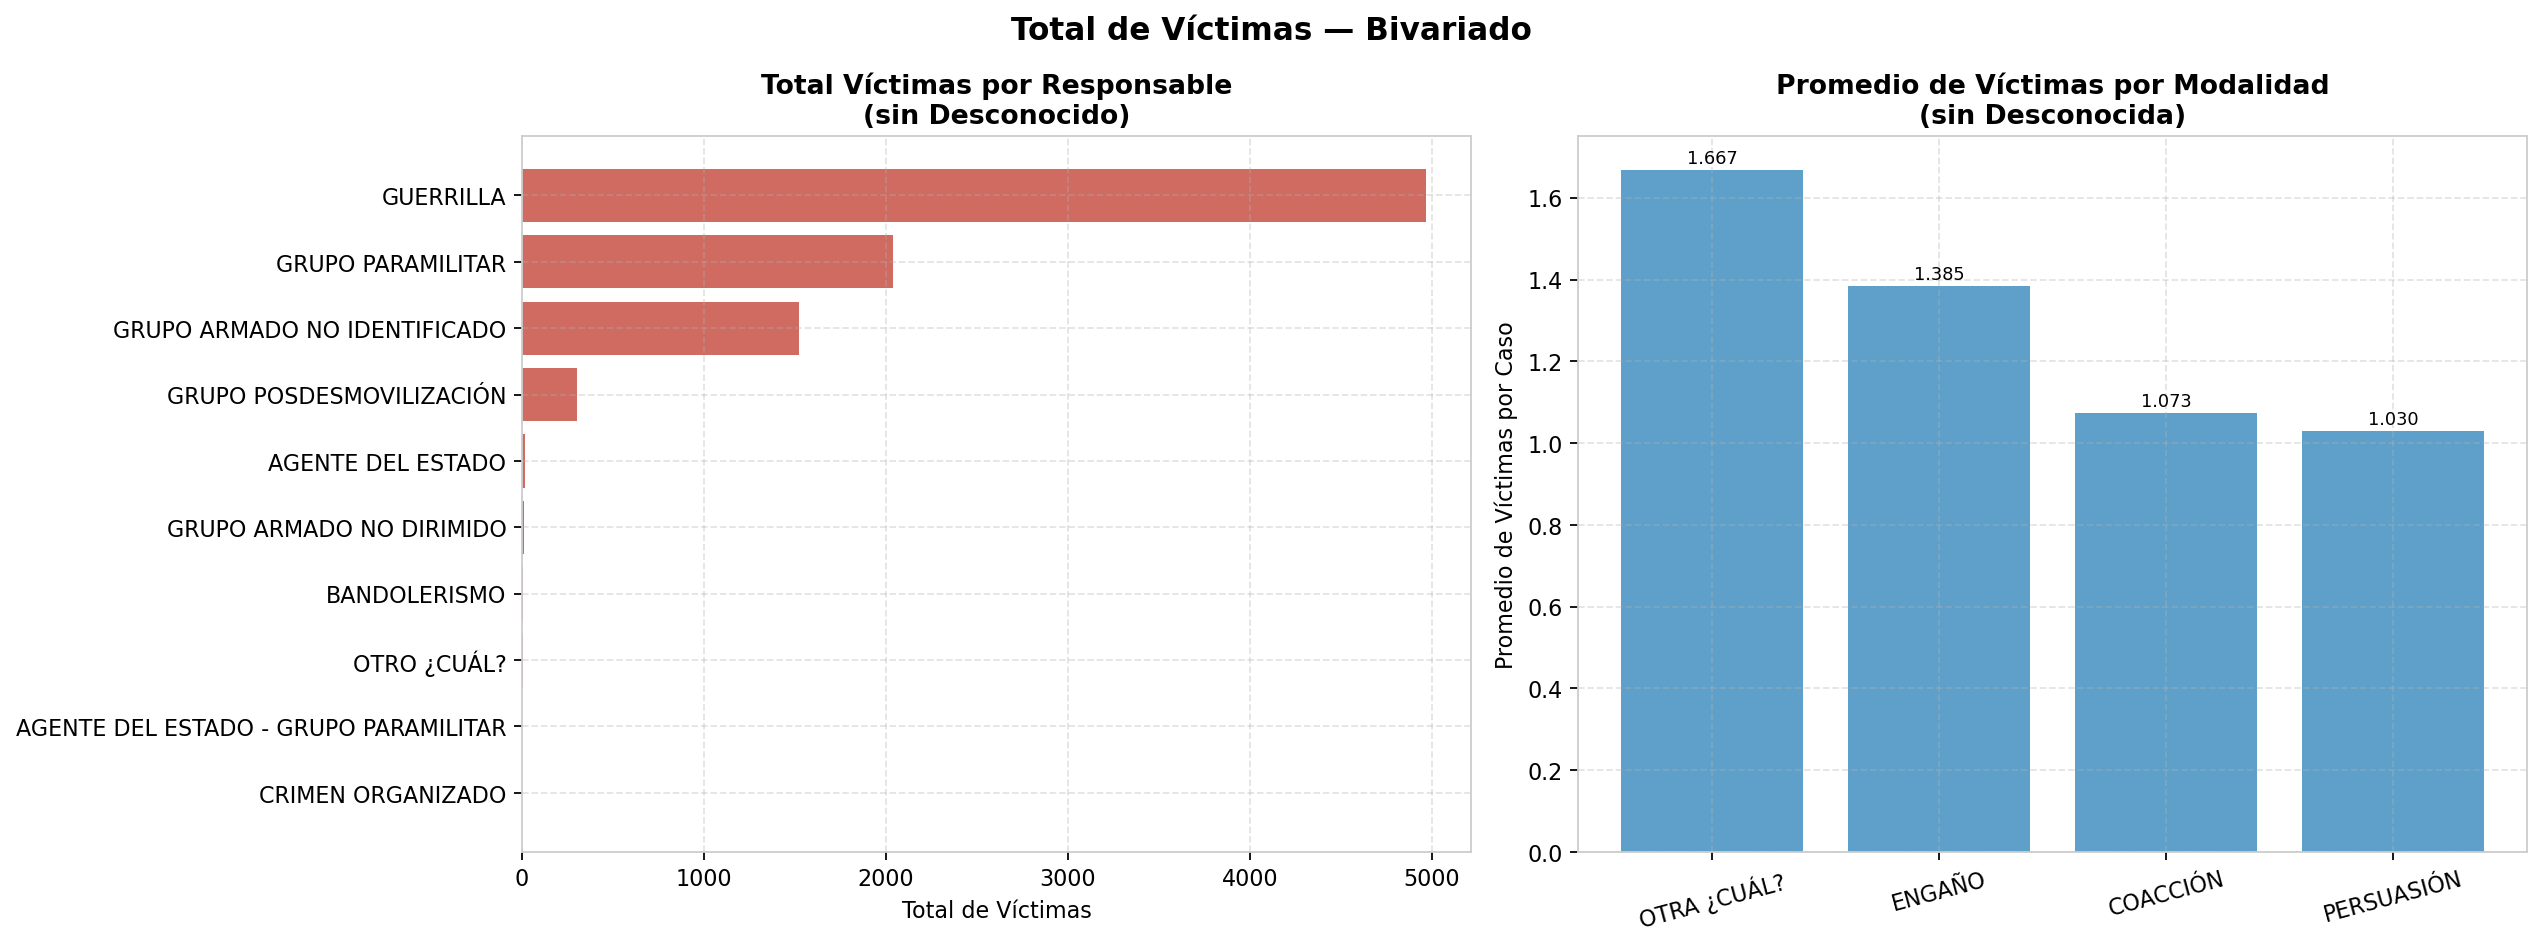

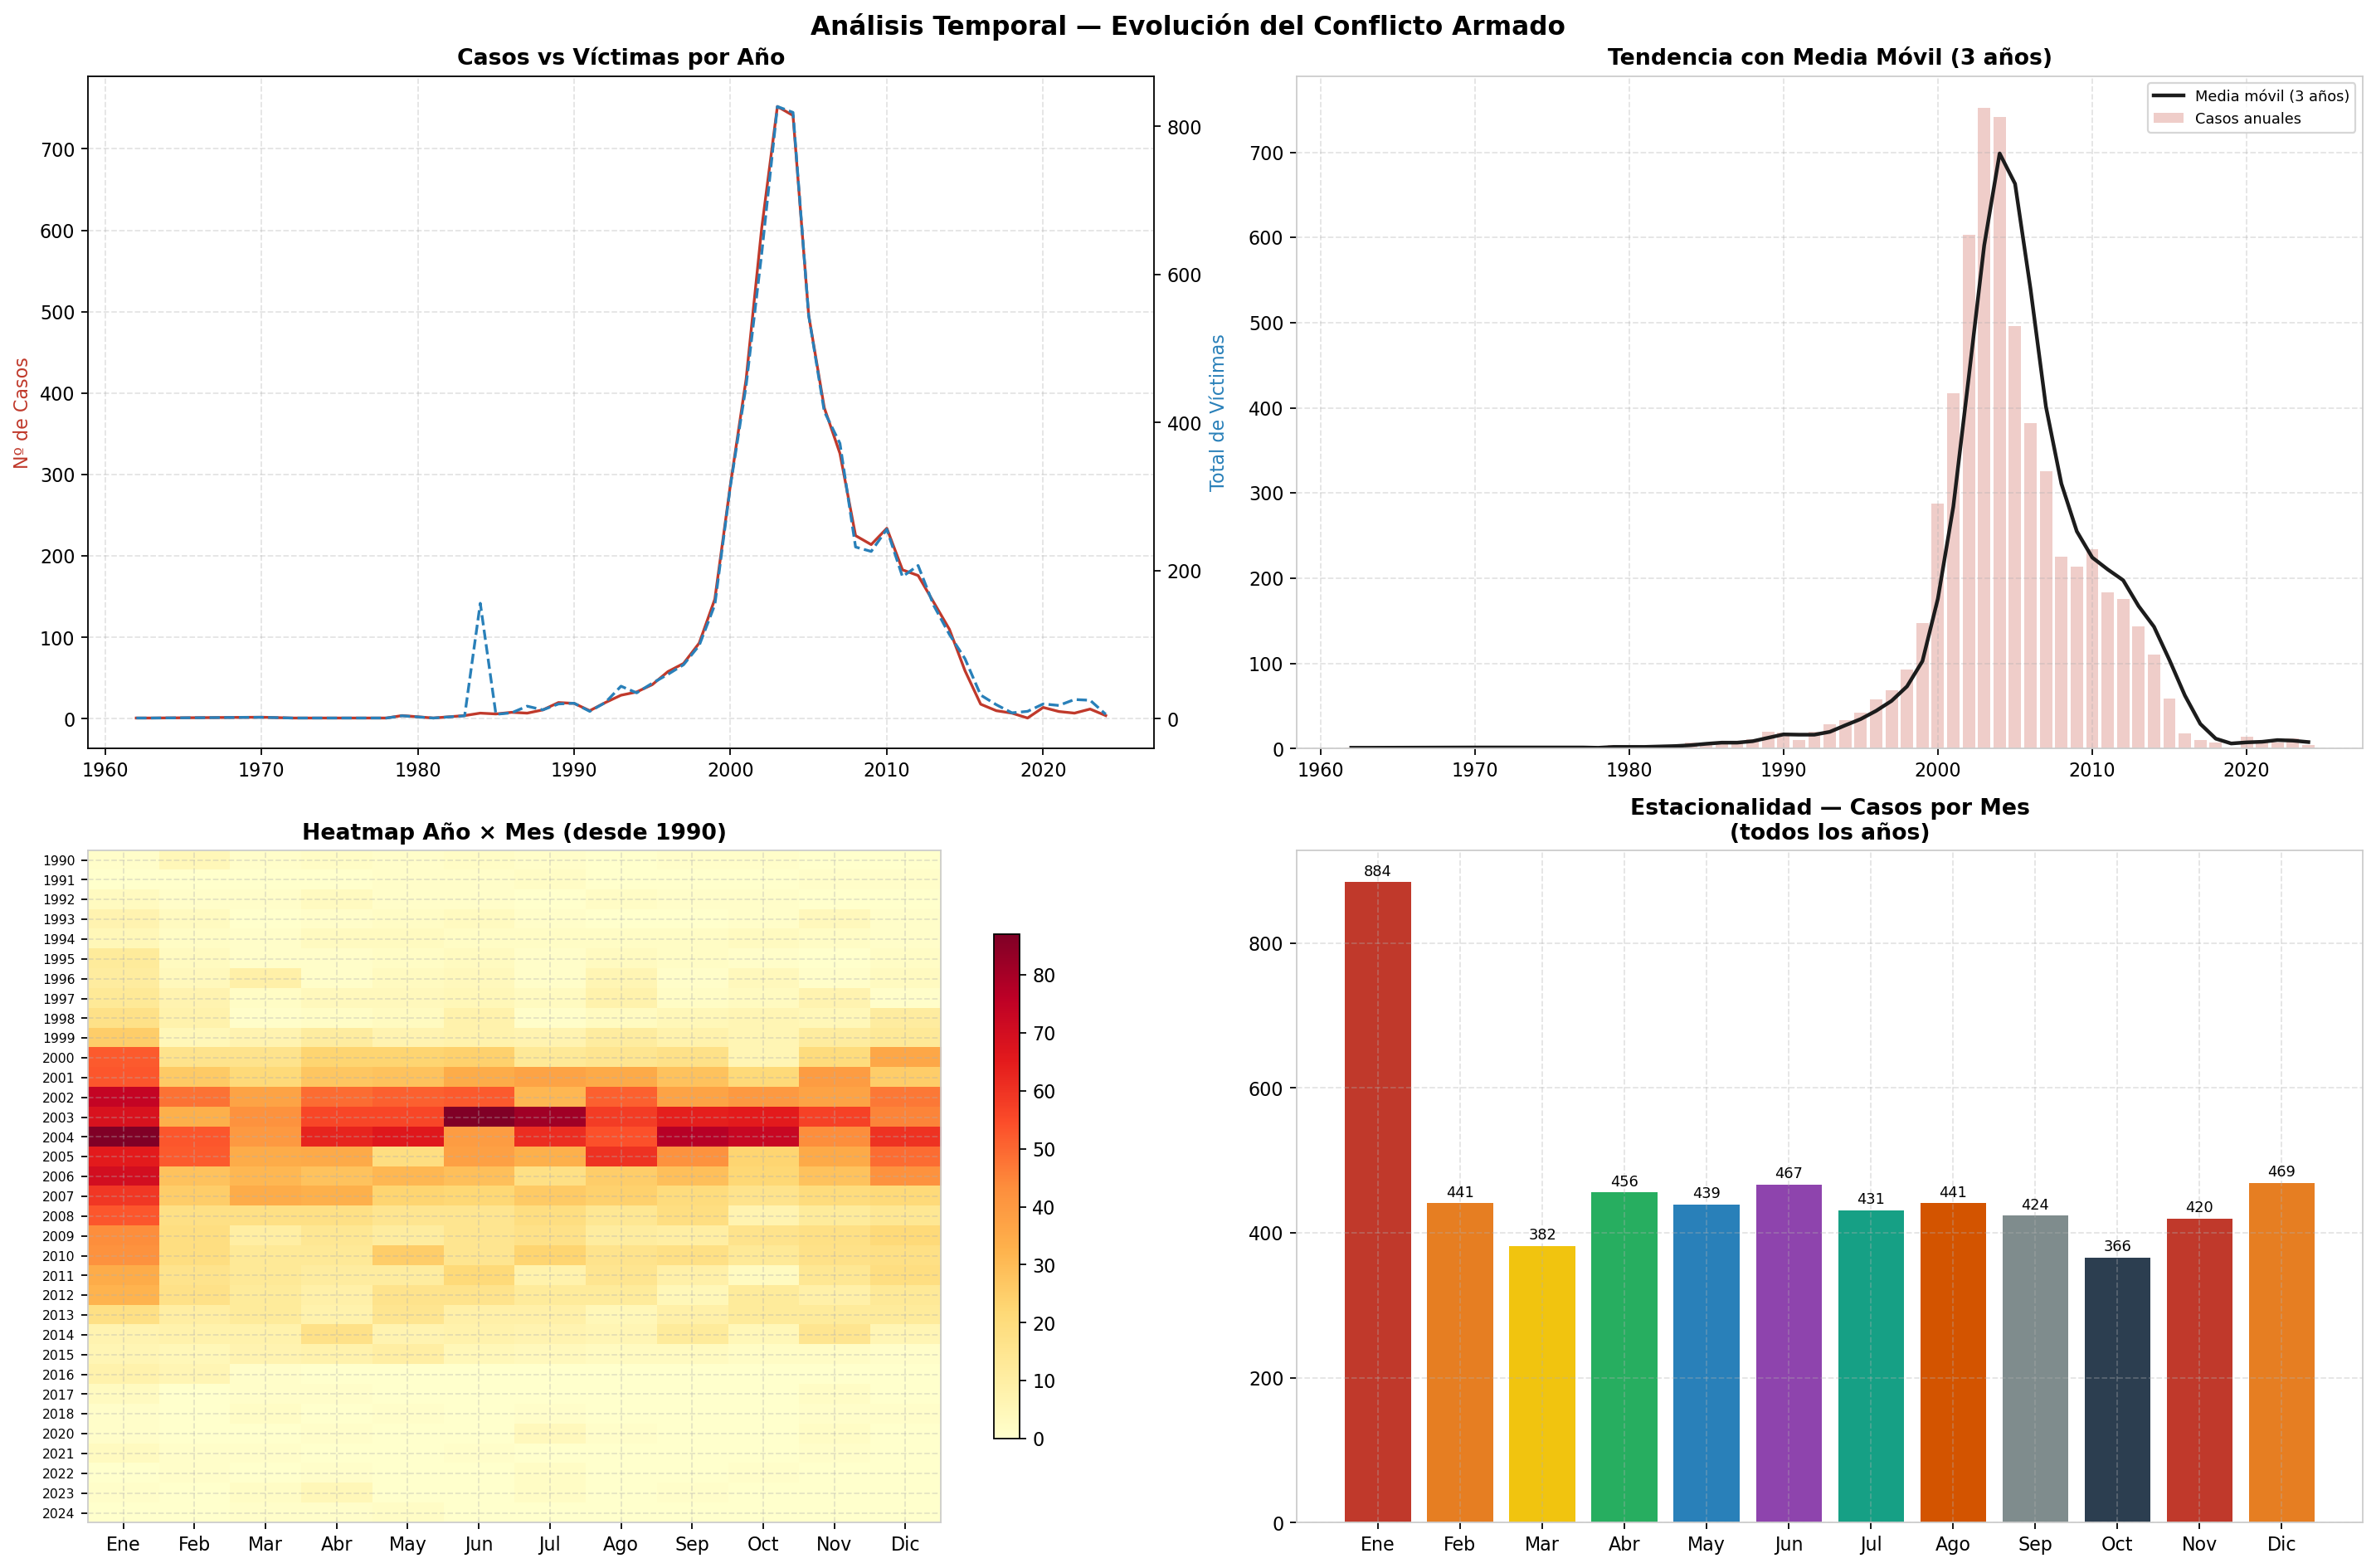

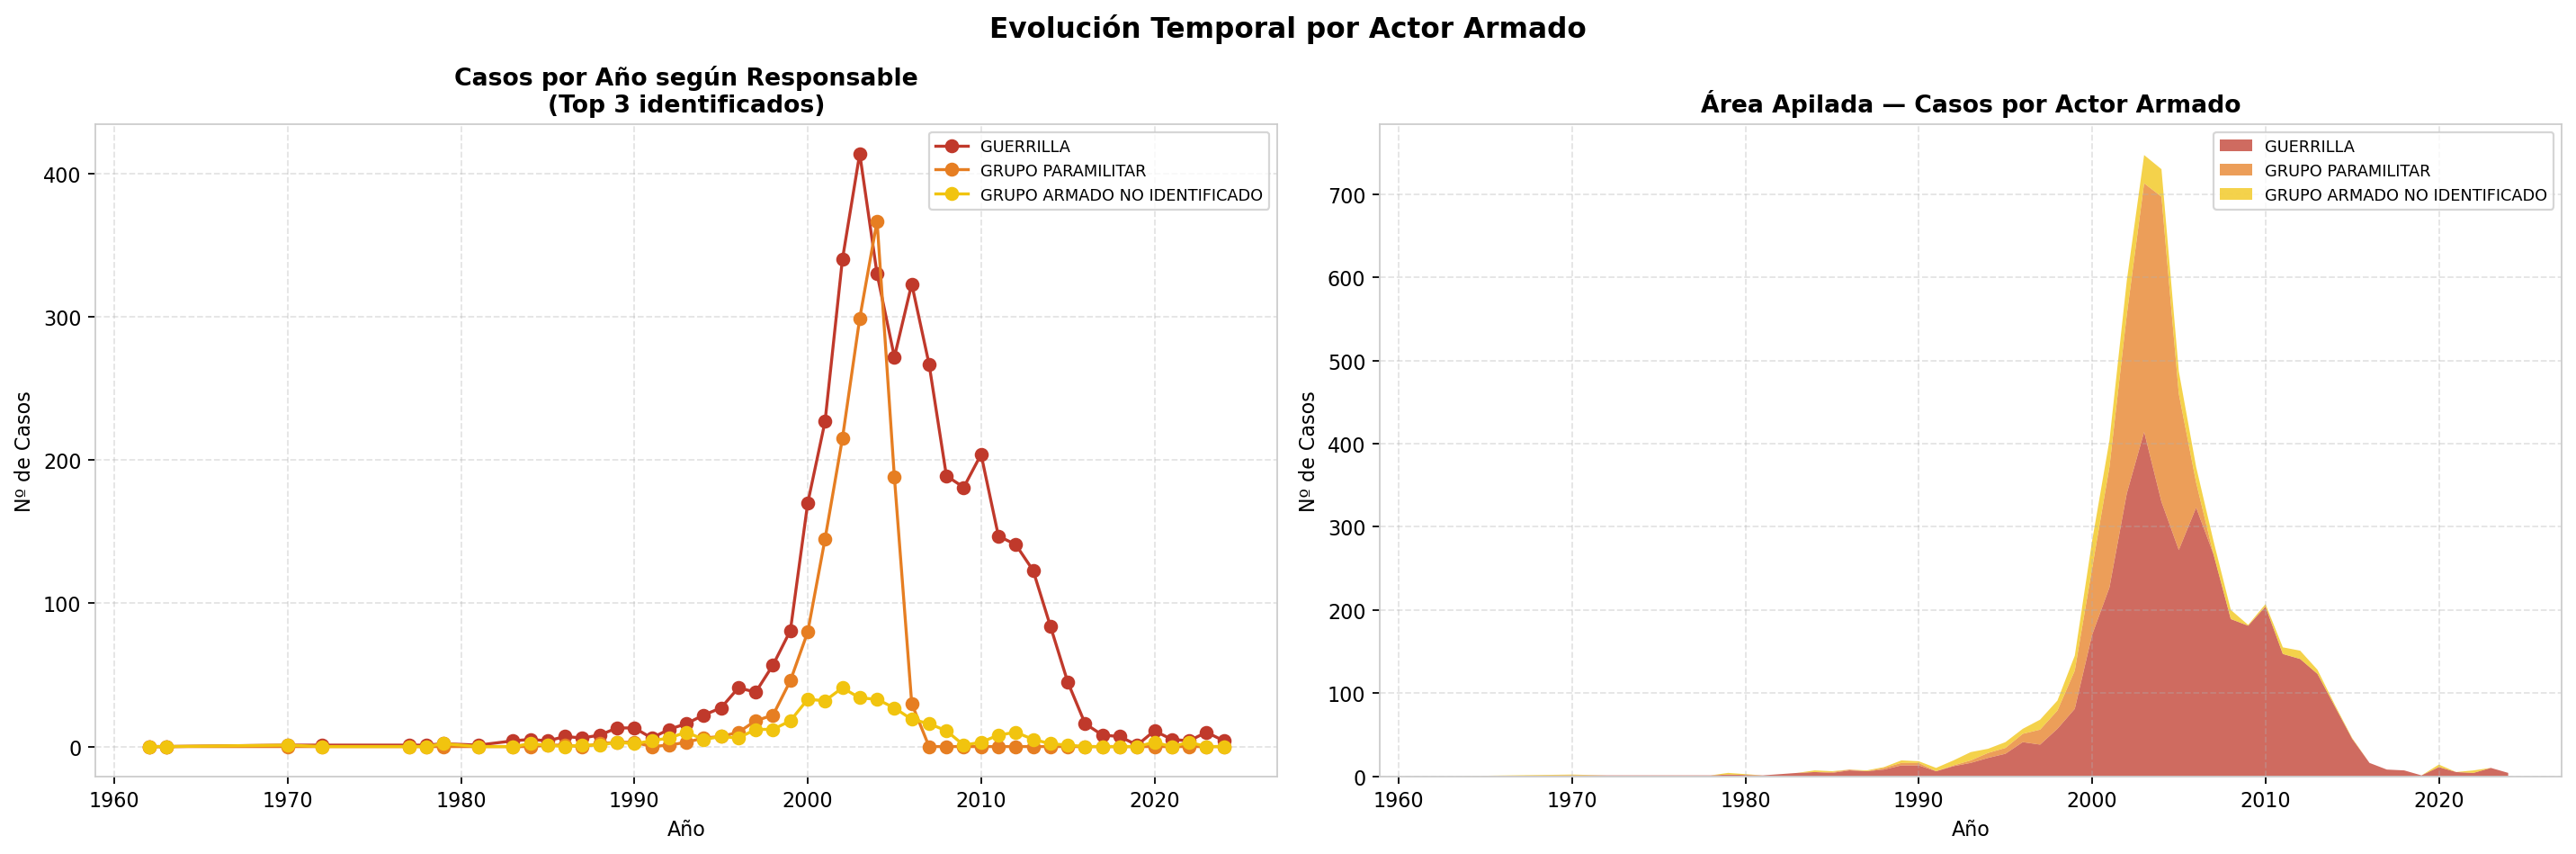

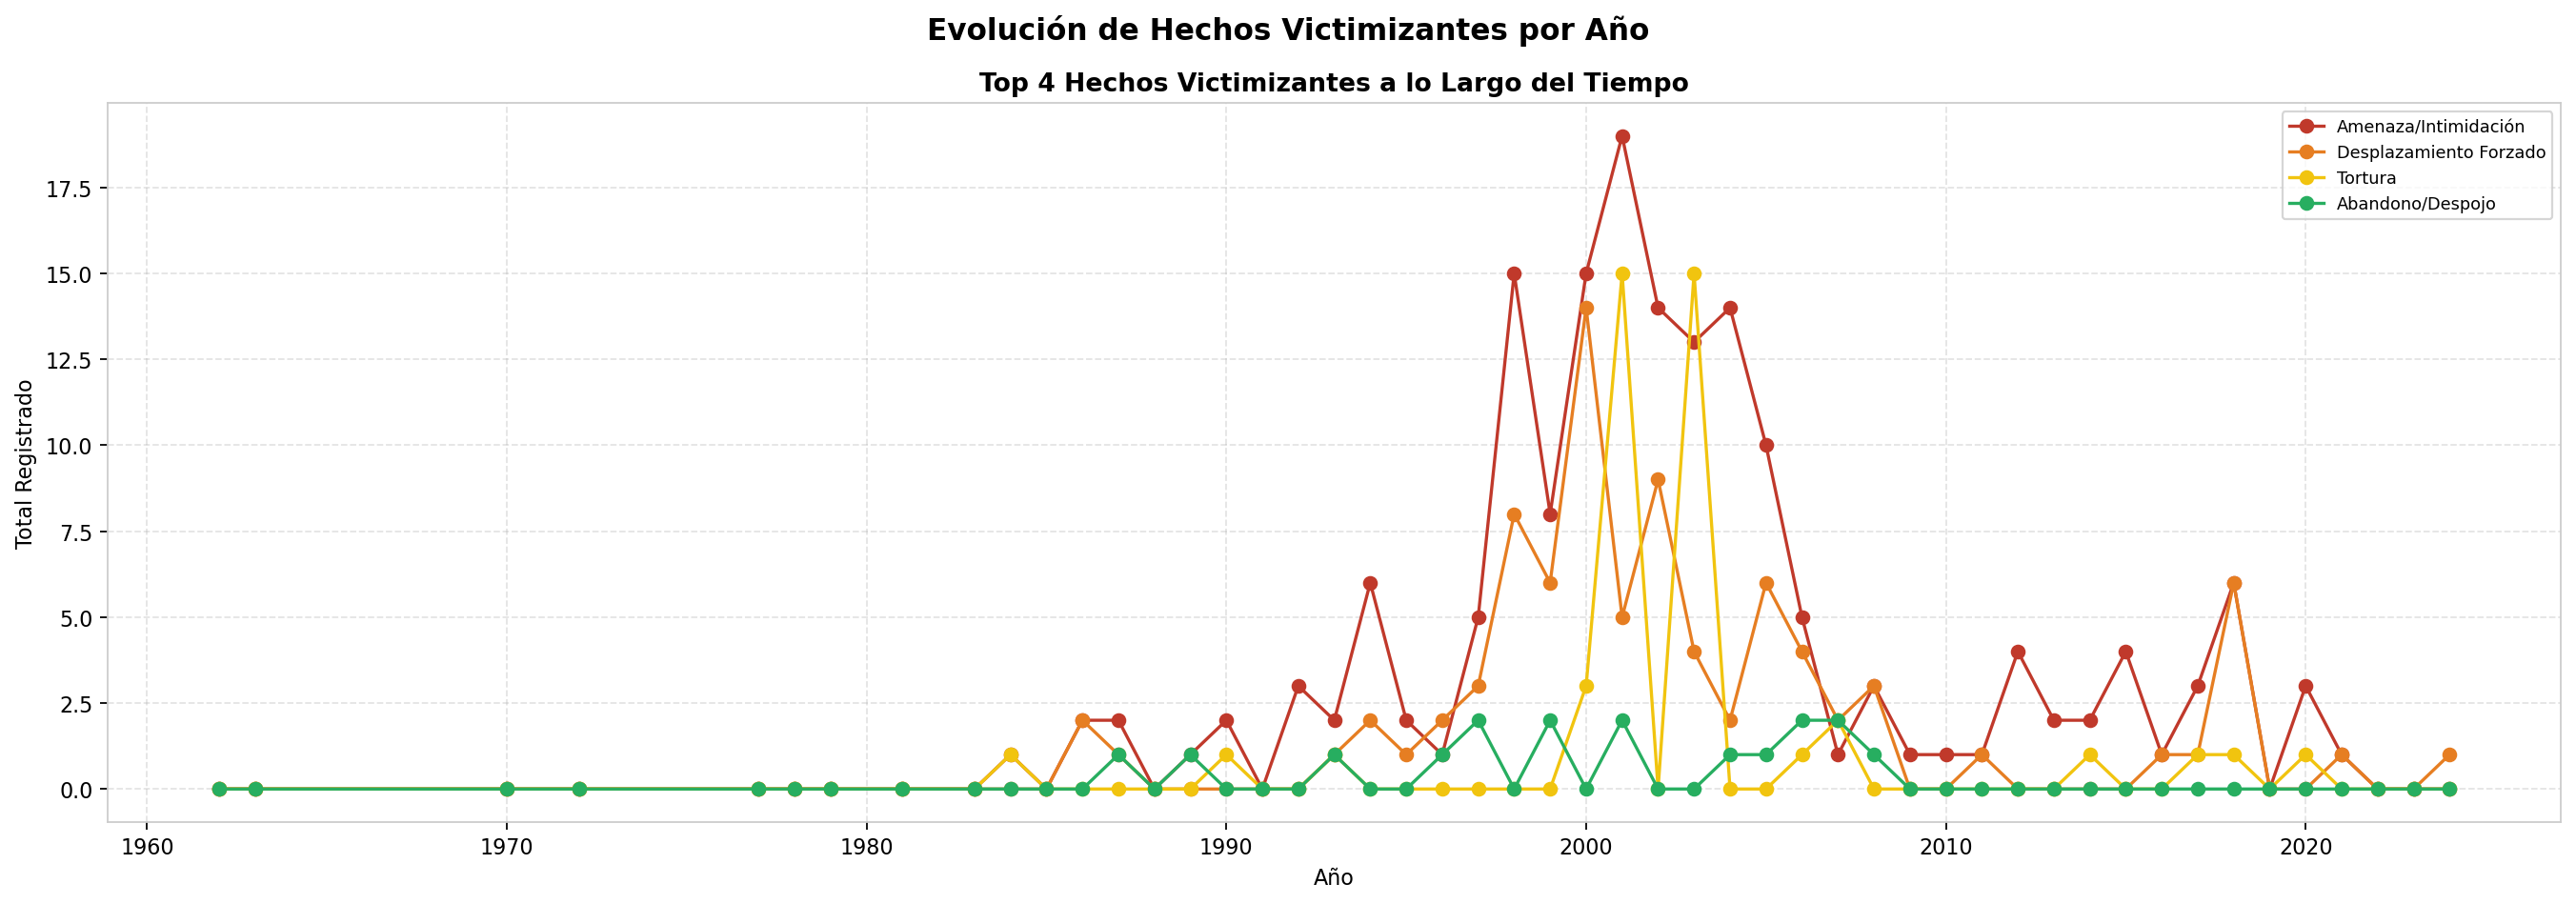

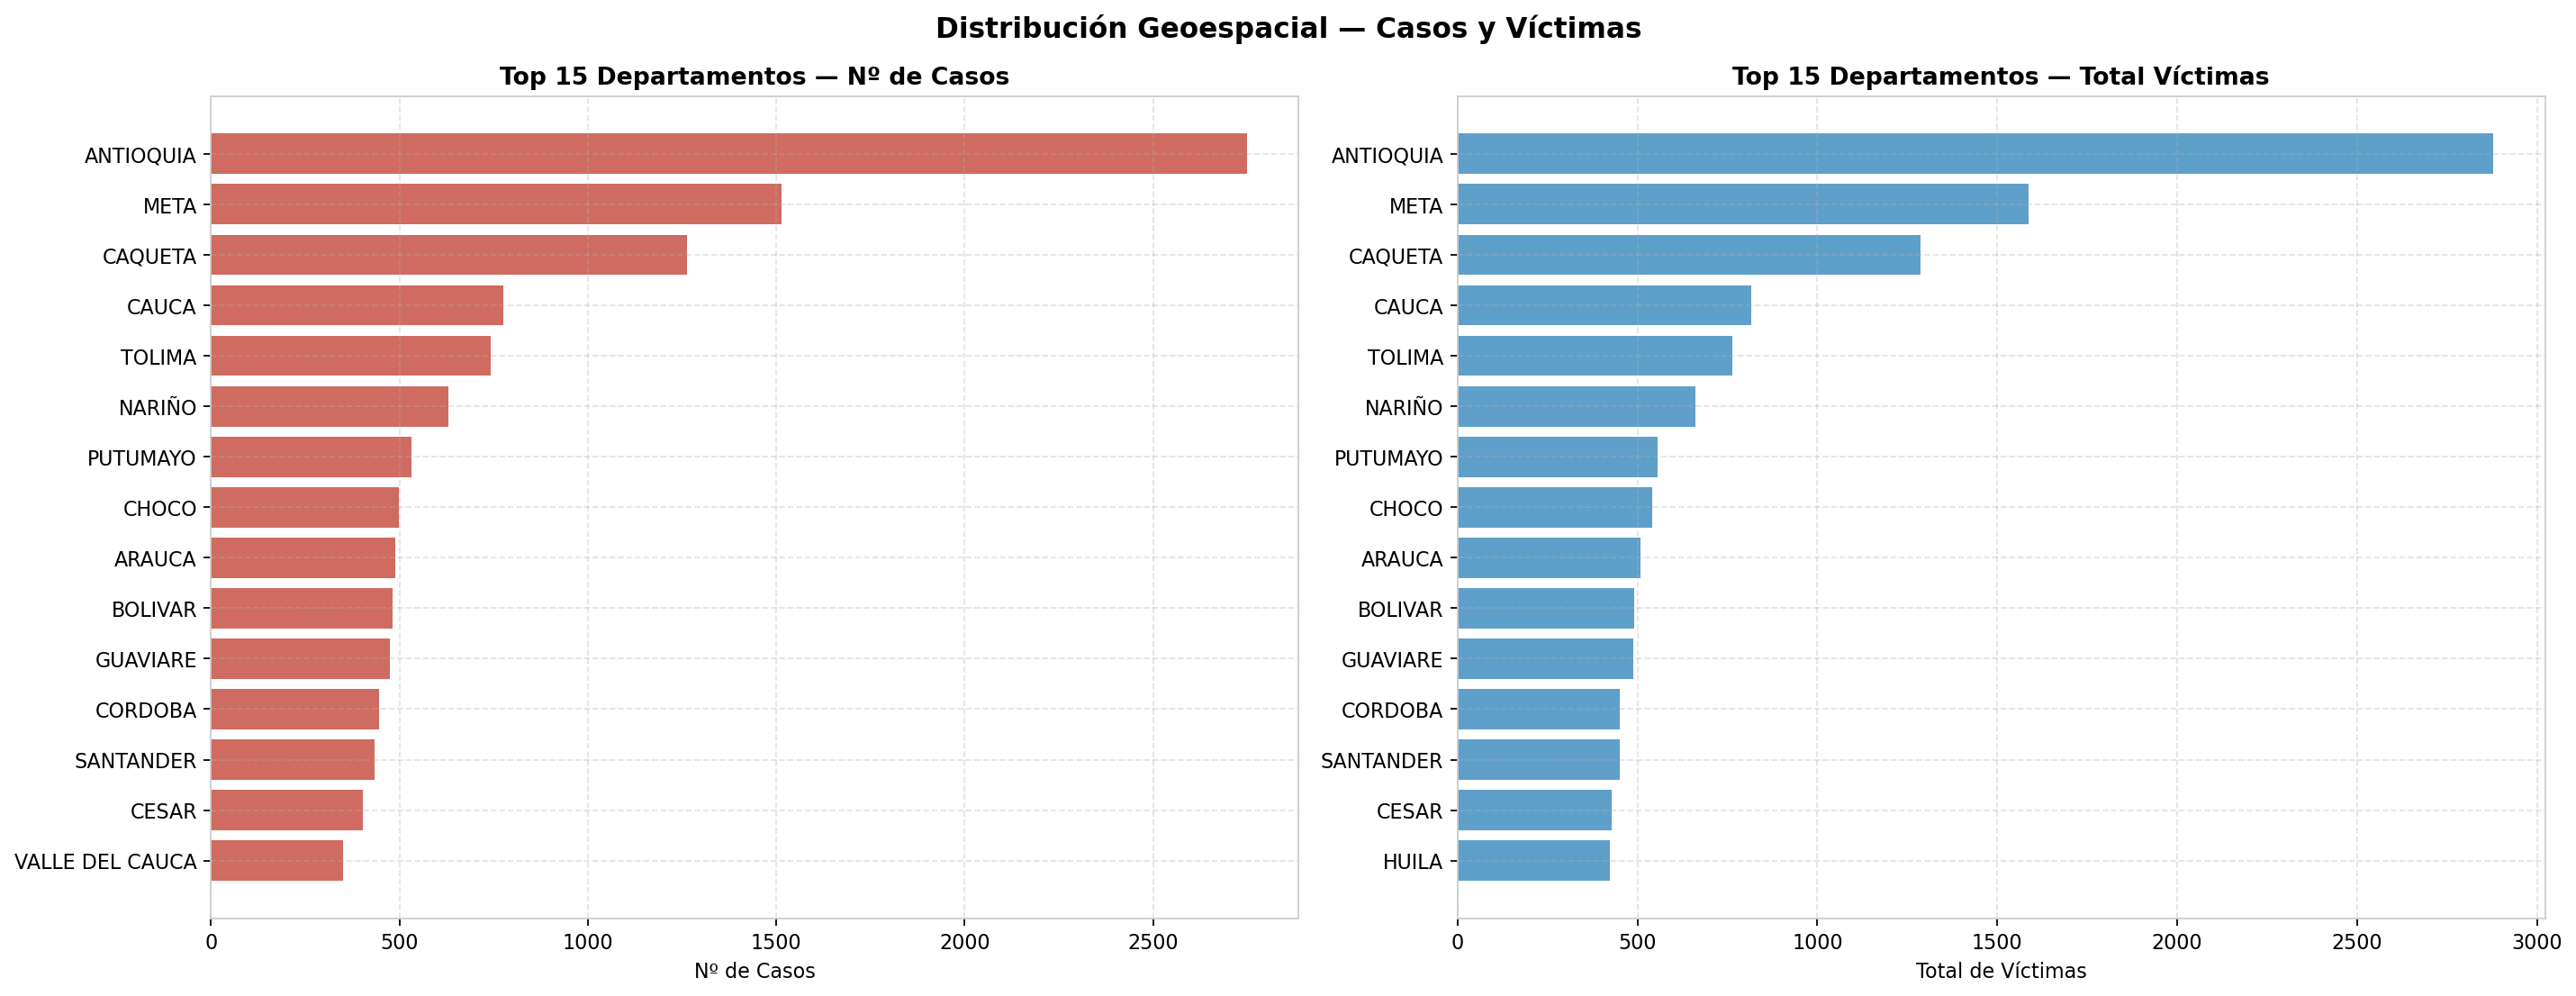

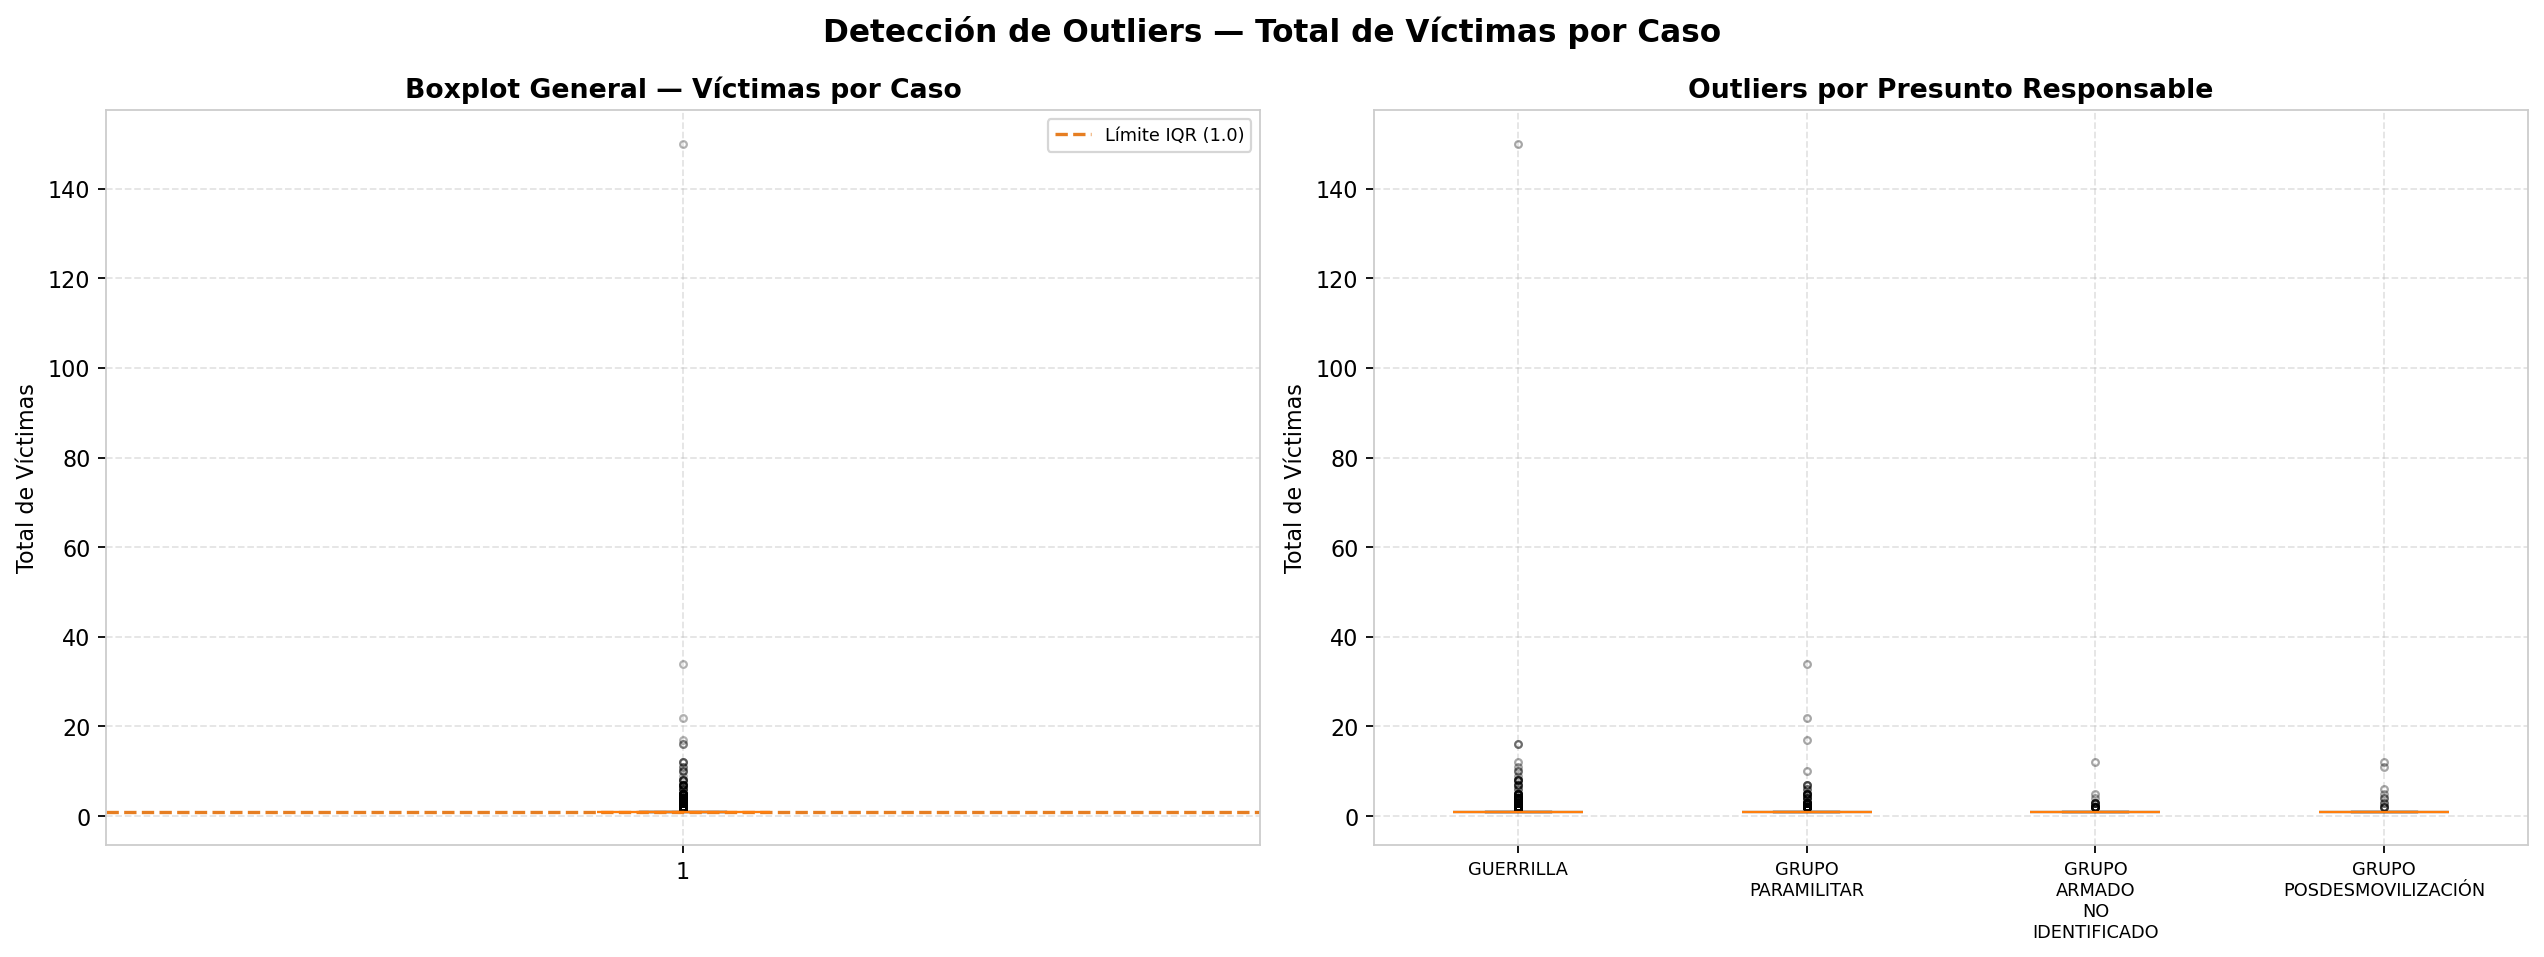

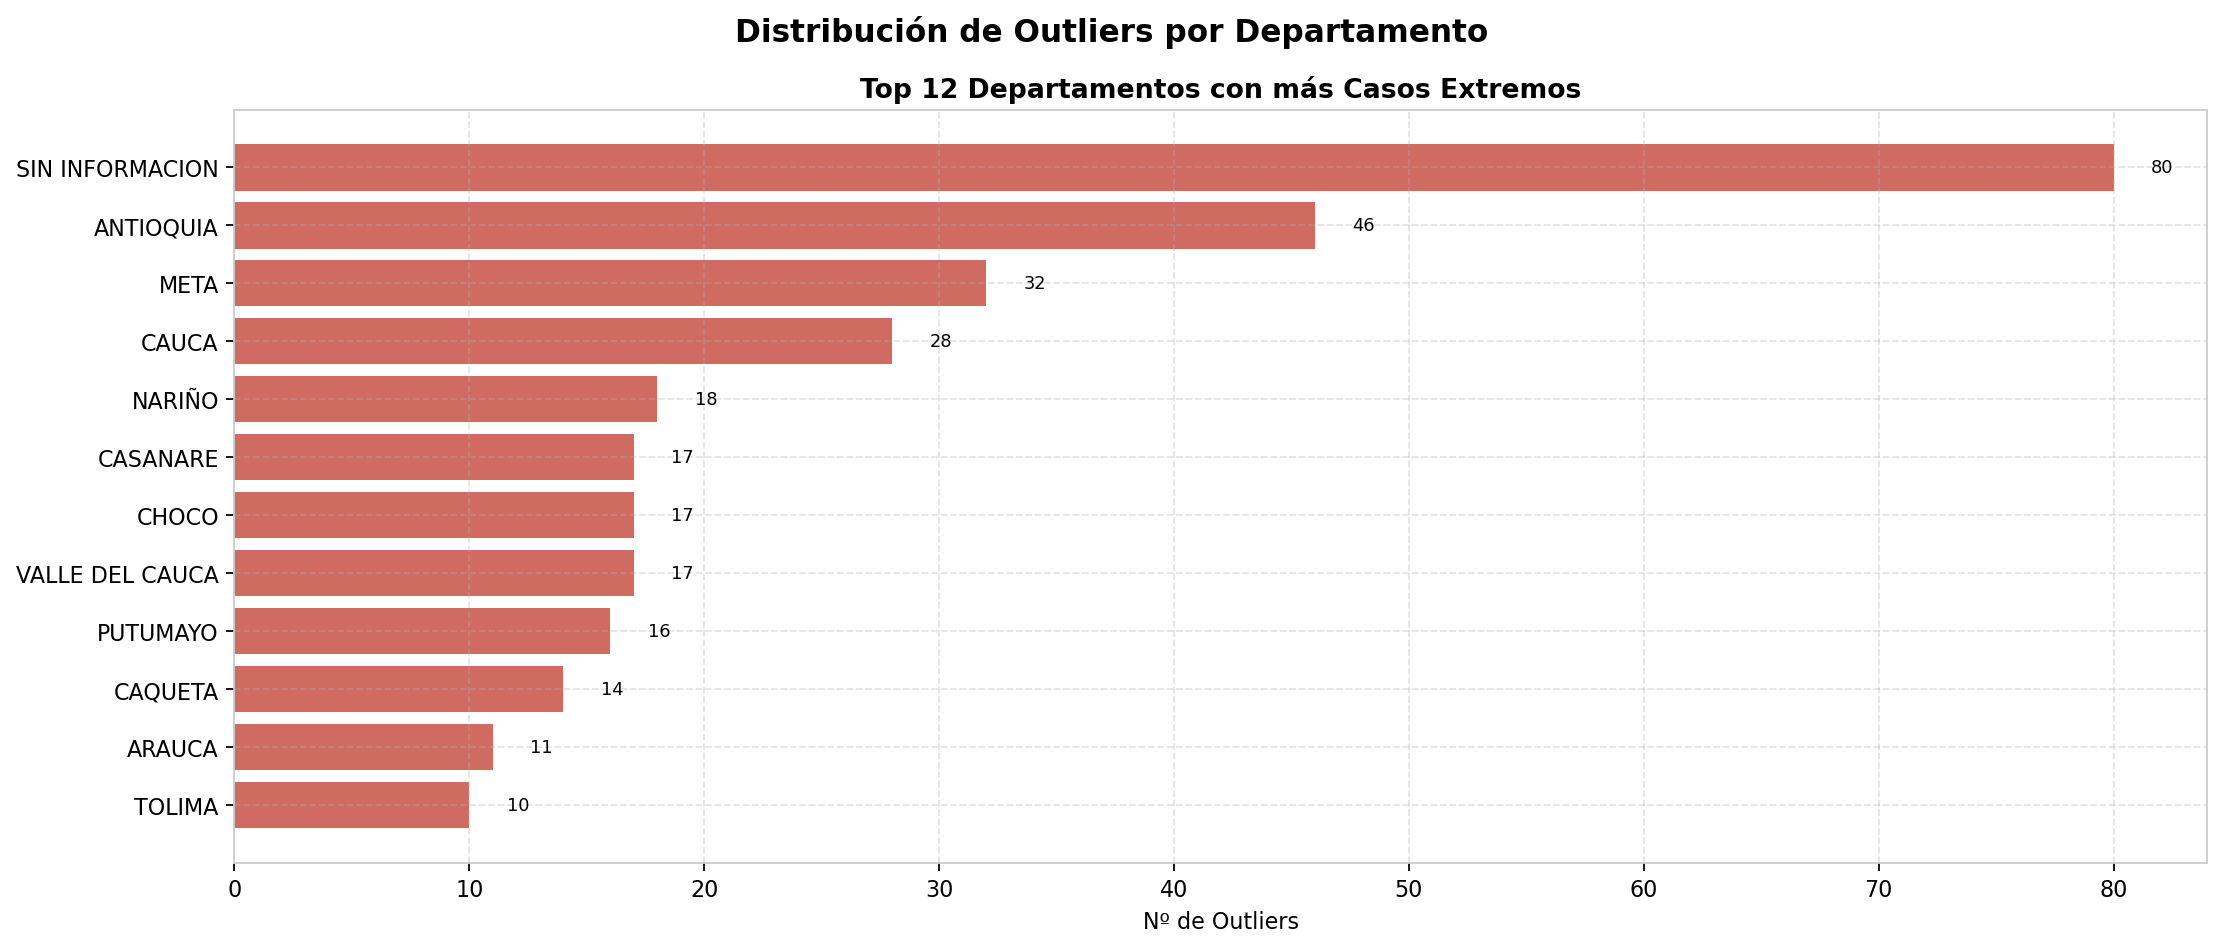

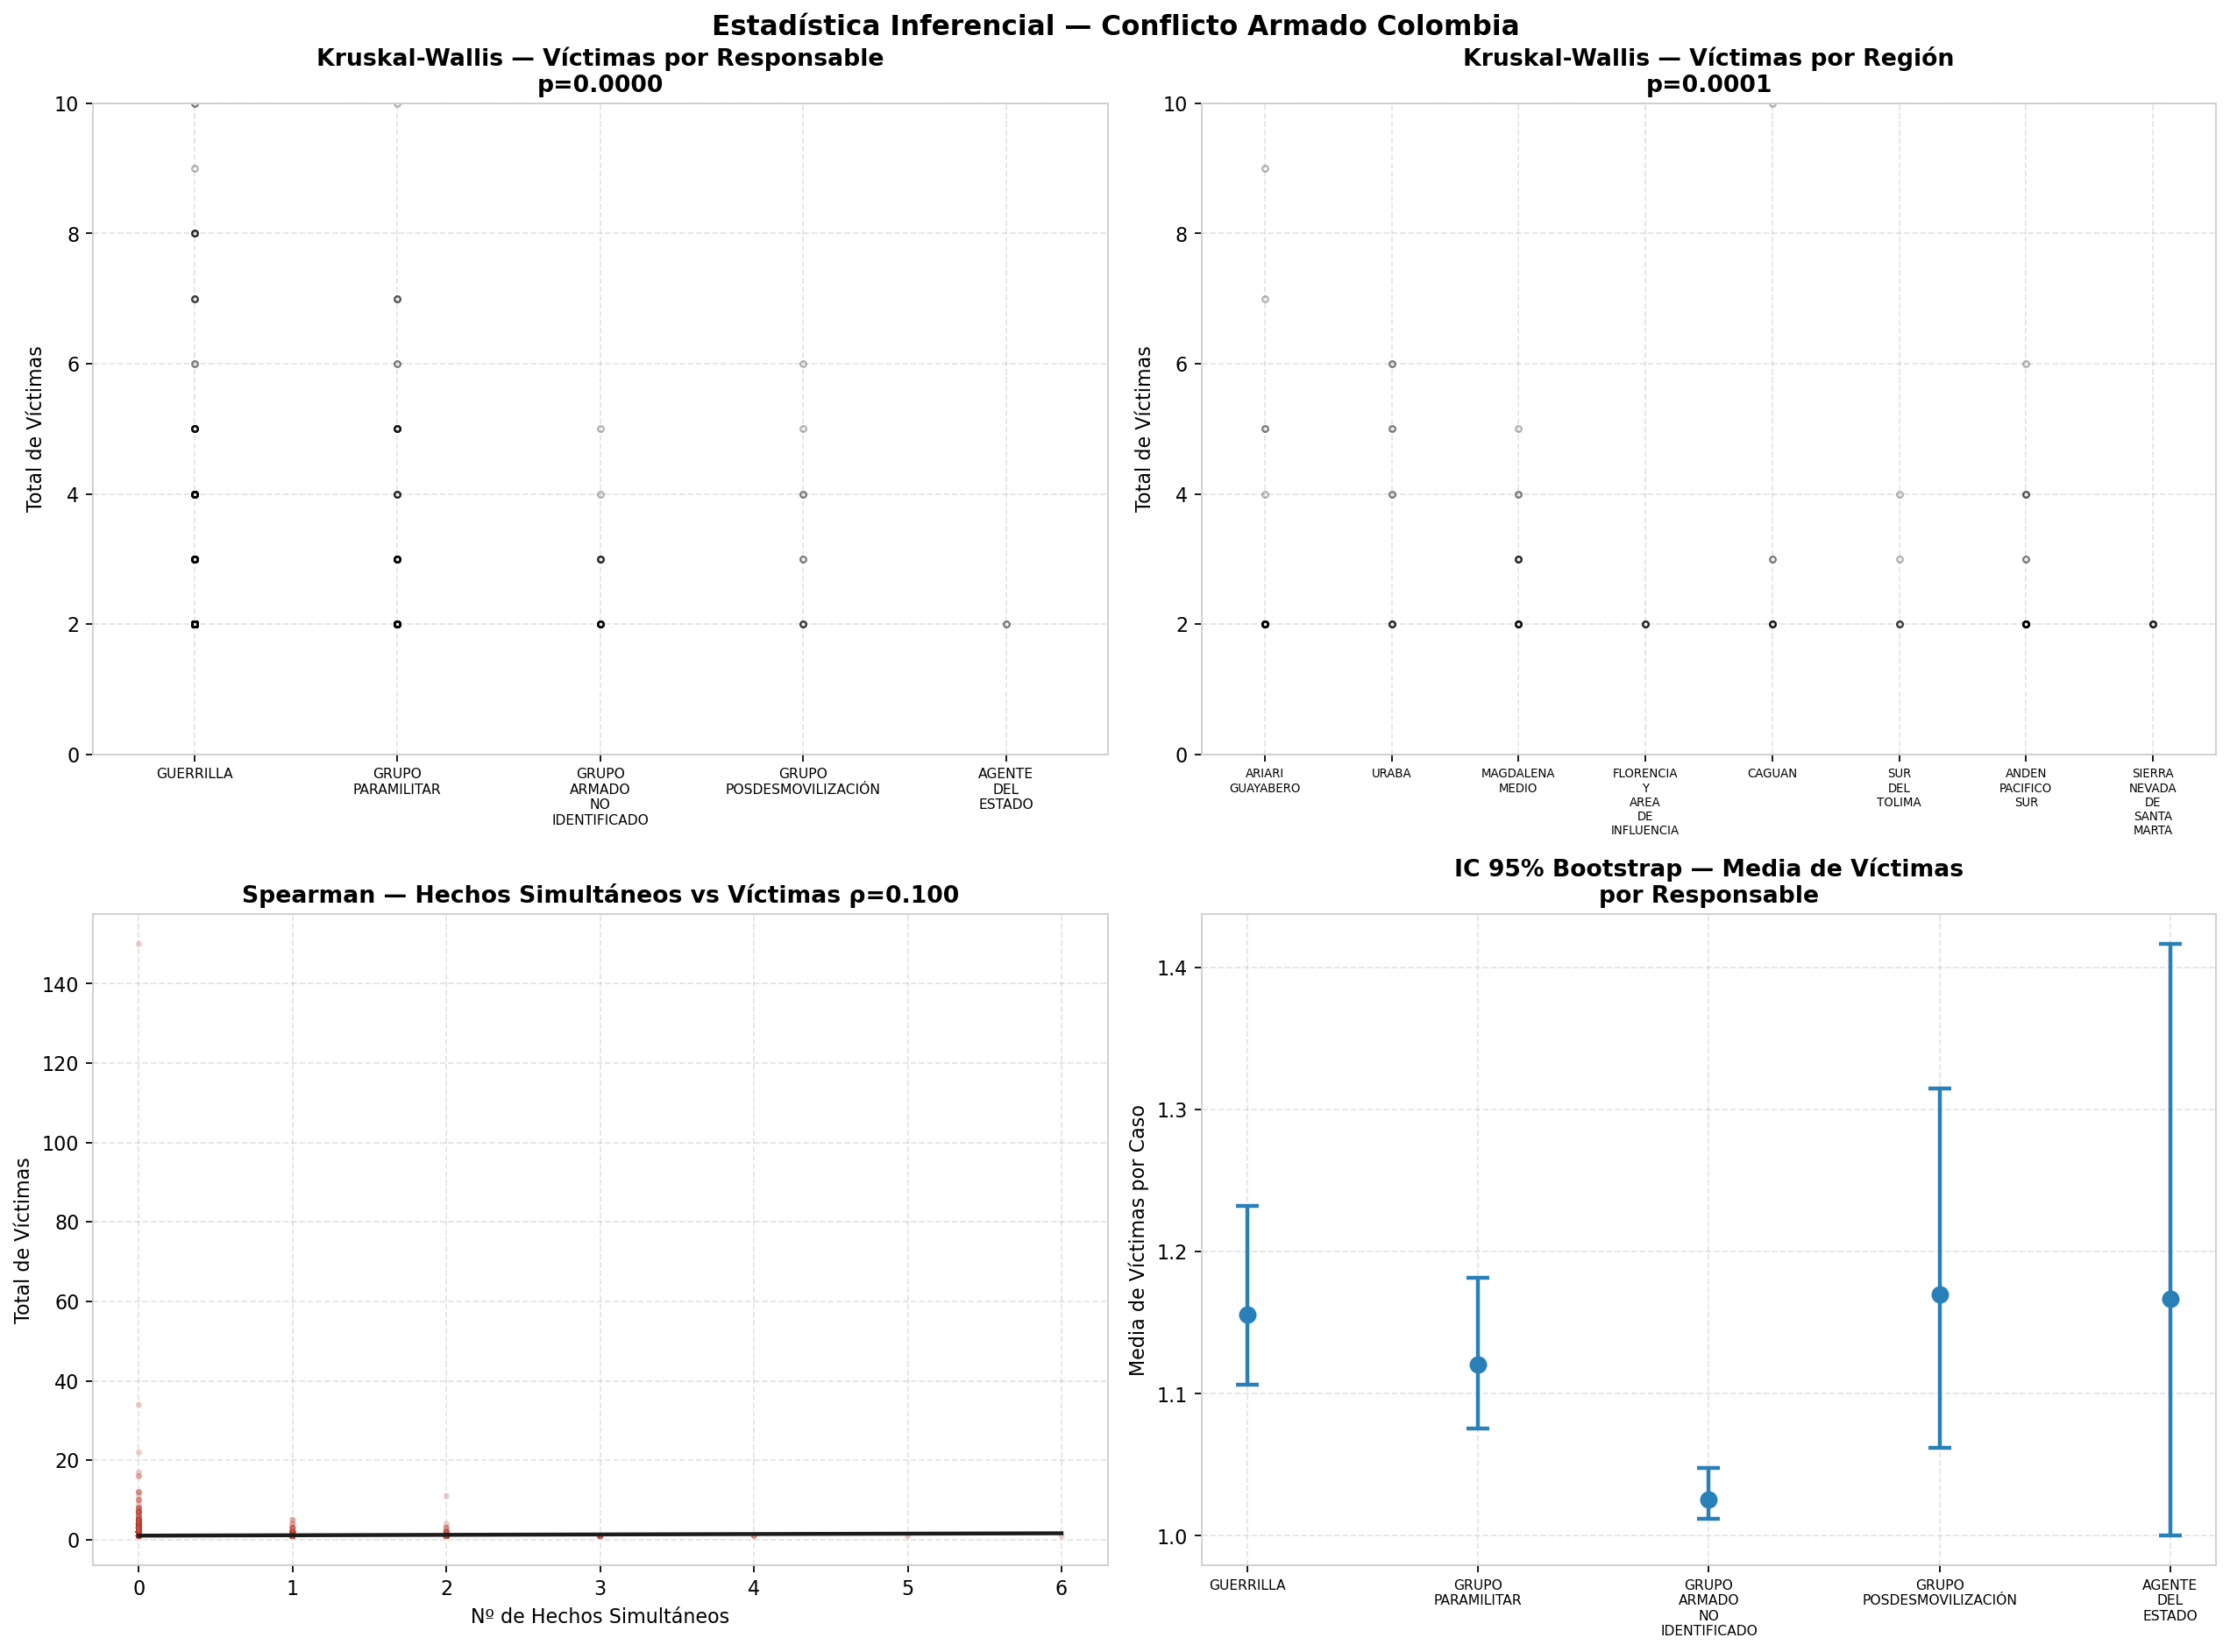

In [16]:
import bdtools.config as cfg
from IPython.display import Image, display

figuras_ampliadas = [
    cfg.FIG_MAPA_NULOS,
    cfg.FIG_PORCENTAJE_NULOS,
    cfg.FIG_COLUMNAS_ELIMINADAS_NULOS,
    cfg.FIG_DISTRIBUCION_DECADA,
    cfg.FIG_FRECUENCIAS_CATEGORICAS,
    cfg.FIG_MODALIDAD_FRECUENCIA_PCT,
    cfg.FIG_TIPO_VINCULACION,
    cfg.FIG_FORMA_VINCULACION,
    cfg.FIG_DEPARTAMENTOS,
    cfg.FIG_REGIONES,
    cfg.FIG_DESCRIPTIVE_PANEL,
    cfg.FIG_VICTIMS_DISTRIBUTION,
    cfg.FIG_HECHOS_DISTRIBUTION,
    cfg.FIG_RESPONSABLE_DETAIL,
    cfg.FIG_MODALIDAD_DETAIL,
    cfg.FIG_TEMPORAL_DECADE_MONTH,
    cfg.FIG_CONFLICT_2000_2010,
    cfg.FIG_GEO_RESP_2000_2010,
    cfg.FIG_CORRELACIONES_HECHOS,
    cfg.FIG_RESP_MODALIDAD,
    cfg.FIG_RESP_DEPARTAMENTOS,
    cfg.FIG_VICTIMAS_BIVARIADO,
    cfg.FIG_TEMPORAL_EVOLUCION,
    cfg.FIG_TEMPORAL_ACTOR,
    cfg.FIG_EVOLUCION_HECHOS,
    cfg.FIG_GEO_CASOS_VICTIMAS,
    cfg.FIG_OUTLIERS_VICTIMAS,
    cfg.FIG_OUTLIERS_DEPARTAMENTO,
    cfg.FIG_INFERENTIAL_ADVANCED,
]

for fig in figuras_ampliadas:
    if fig.exists():
        display(Image(filename=str(fig)))
    else:
        print(f"No se encontró: {fig.name}")

## 5. Estadística inferencial

Se aplican pruebas chi-cuadrado para evaluar asociación entre variables categóricas y la variable alto_impacto. También se reporta la proporción de casos de alto impacto con intervalo de confianza del 95%.

In [17]:
stats_outputs["pruebas_chi_cuadrado"]

,variable,chi2,p_value,dof,cramers_v,decision
0,departamento,107.3679,0.000000,34,0.0790,asociacion
2,modalidad,228.8260,0.000000,4,0.1153,asociacion
3,presunto_responsable,624.4256,0.000000,10,0.1905,asociacion
4,tipo_vinculacion,182.1583,0.000000,4,0.1029,asociacion
6,decada,688.8058,0.000000,7,0.2001,asociacion
5,forma_vinculacion,10622.9845,0.000000,6,0.7859,asociacion
1,region,149.1148,0.000001,75,0.0931,asociacion


### Estadística inferencial avanzada

Se agregan pruebas no paramétricas y bootstrap para complementar el análisis inferencial del notebook base.

In [18]:
display(stats_outputs["estadistica_inferencial_avanzada"])
display(stats_outputs["estadistica_inferencial_grupos"].head(15))
display(stats_outputs["spearman_hechos_victimas"].head(15))
display(stats_outputs["bootstrap_ic_victimas"].head(10))

,prueba,variable,estadistico,p_value,decision,efecto_r
0,normalidad_dagostino_pearson,total_victimas_caso,6.836612e+04,0.000000,no_normal,NaN
1,kruskal_responsable,presunto_responsable,7.258460e+01,0.000000,diferencias,NaN
2,mann_whitney_guerrilla_paramilitar,presunto_responsable,4.001654e+06,0.000443,diferencias,-0.0231
3,kruskal_region,region,2.904830e+01,0.000142,diferencias,NaN
4,spearman_total_hechos_victimas,total_hechos,1.003000e-01,0.000000,correlacion,NaN


,prueba,grupo,n,media,mediana
0,kruskal_responsable,GUERRILLA,4298,1.1557,1.0
1,kruskal_responsable,GRUPO PARAMILITAR,1820,1.1203,1.0
2,kruskal_responsable,GRUPO ARMADO NO IDENTIFICADO,1482,1.0256,1.0
3,kruskal_responsable,GRUPO POSDESMOVILIZACIÓN,259,1.1699,1.0
4,kruskal_responsable,AGENTE DEL ESTADO,12,1.1667,1.0
5,kruskal_region,ARIARI GUAYABERO,1466,1.0423,1.0
6,kruskal_region,URABA,956,1.0303,1.0
7,kruskal_region,MAGDALENA MEDIO,800,1.0350,1.0
8,kruskal_region,FLORENCIA Y AREA DE INFLUENCIA,586,1.0085,1.0
9,kruskal_region,CAGUAN,570,1.0333,1.0


,variable,hecho,rho,p_value,decision
0,abandono_o_despojo_forzado_de_tierras,Abandono/Despojo,-0.005091,0.504343,sin_correlacion
1,amenaza_o_intimidacion,Amenaza/Intimidación,0.091825,0.000000,correlacion
2,confinamiento_o_restriccion_a_la_movilidad,Confinamiento,0.013352,0.079931,sin_correlacion
3,desplazamiento_forzado,Desplazamiento Forzado,0.054393,0.000000,correlacion
4,extorsion,Extorsión,-0.003089,0.685391,sin_correlacion
5,lesionados_civiles,Lesionados Civiles,0.042610,0.000000,correlacion
6,pillaje,Pillaje,0.021991,0.003922,correlacion
7,tortura,Tortura,0.004458,0.558784,sin_correlacion


,grupo,n,media,ic95_inf,ic95_sup
0,total,17201,1.0570,1.0428,1.0772
1,GUERRILLA,4298,1.1557,1.1065,1.2325
2,GRUPO PARAMILITAR,1820,1.1203,1.0755,1.1817
3,GRUPO ARMADO NO IDENTIFICADO,1482,1.0256,1.0118,1.0476
4,GRUPO POSDESMOVILIZACIÓN,259,1.1699,1.0618,1.3148
5,AGENTE DEL ESTADO,12,1.1667,1.0000,1.4167


In [19]:
stats_outputs["resumen_numerico"].head(15)

,variable,count,mean,std,min,25%,50%,75%,max
0,id_caso,17201.0,328.343718,82.93368,35.787,306.64,311.342,315.896,878.753
1,anio,17201.0,0.702111,0.956281,0.0,0.0,0.0,2.002,2.024
2,mes,17201.0,1.977385,3.515863,0.0,0.0,0.0,2.0,12.0
3,dia,17201.0,3.650951,7.684946,0.0,0.0,0.0,1.0,31.0
4,abandono_o_despojo_forzado_de_tierras,17201.0,0.001105,0.033218,0.0,0.0,0.0,0.0,1.0
5,amenaza_o_intimidacion,17201.0,0.011685,0.107469,0.0,0.0,0.0,0.0,1.0
6,ataque_contra_mision_medica,17201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,confinamiento_o_restriccion_a_la_movilidad,17201.0,0.000523,0.022869,0.0,0.0,0.0,0.0,1.0
8,desplazamiento_forzado,17201.0,0.005872,0.076404,0.0,0.0,0.0,0.0,1.0
9,extorsion,17201.0,0.000407,0.02017,0.0,0.0,0.0,0.0,1.0


## 6. Procesamiento geoespacial

Se construye un GeoDataFrame y se exporta el archivo GeoJSON para uso en herramientas SIG o visualizadores externos.

In [20]:
from bdtools.geo import build_geospatial_outputs

gdf = build_geospatial_outputs(df)
gdf.shape

(17201, 33)

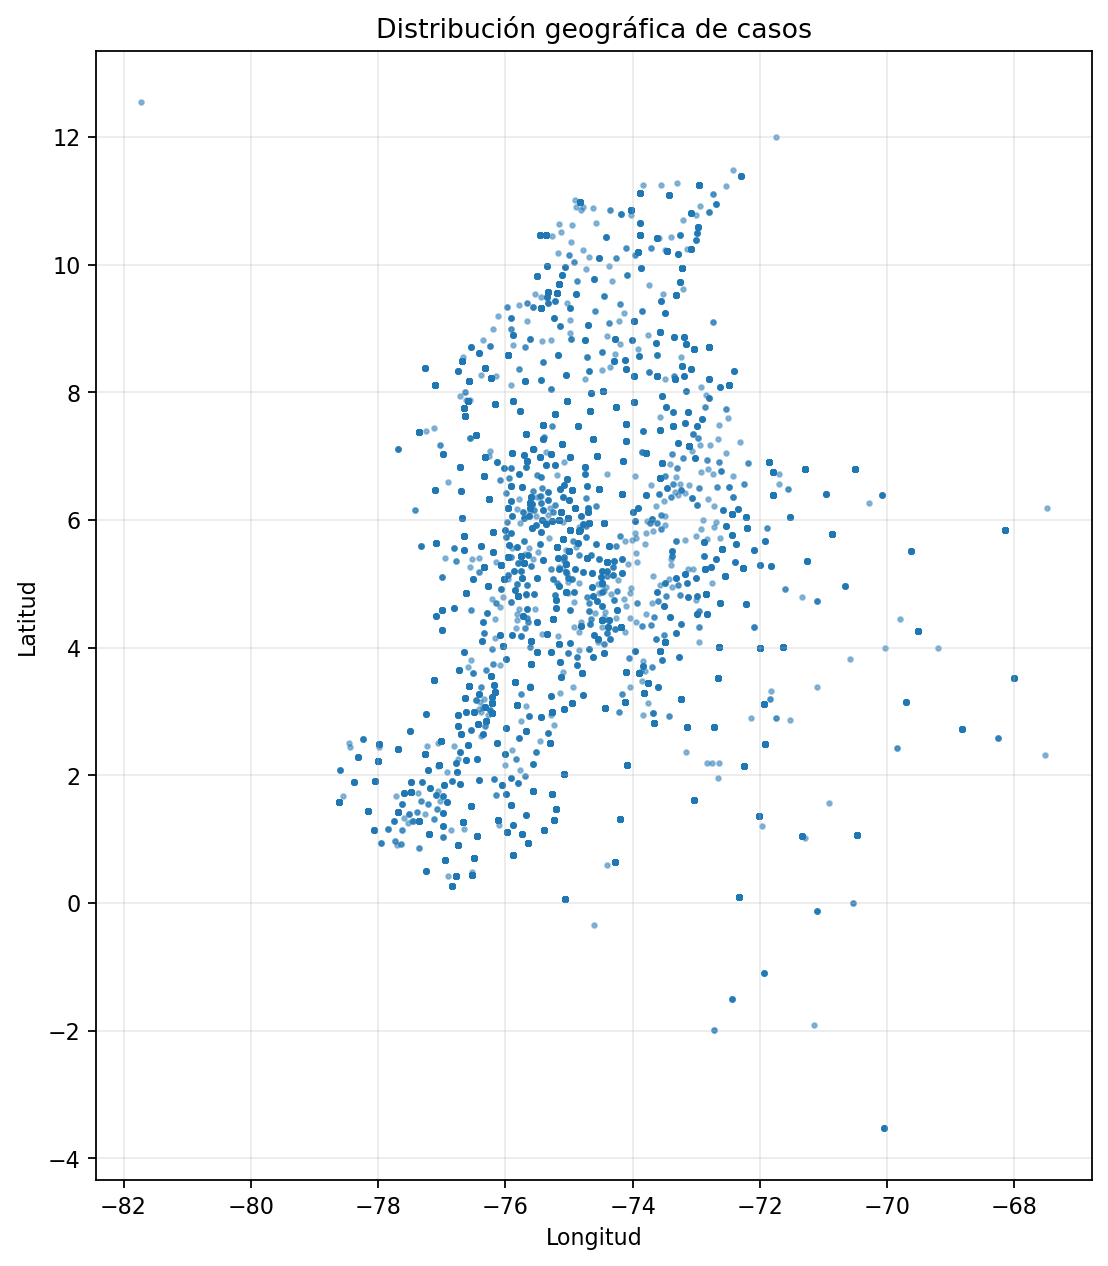

In [21]:
if cfg.FIG_GEO.exists():
    display(Image(filename=str(cfg.FIG_GEO)))

## 7. Modelado: Regresión Logística y Random Forest

El modelado usa únicamente dos clasificadores: Regresión Logística y Random Forest. La variable total_victimas_caso no se usa como predictor porque participa en la definición de la variable objetivo.

In [22]:
from bdtools.modeling import train_and_evaluate_models

model_results = train_and_evaluate_models(df)
model_results["metrics"]

,modelo,accuracy,precision,recall,f1,roc_auc
1,random_forest,0.9782,0.5141,0.9241,0.6606,0.9824
0,logistica,0.9715,0.4424,0.9241,0.5984,0.9879


## 8. Evaluación de modelos

La comparación se realiza con accuracy, precision, recall, F1 y ROC AUC. Las matrices de confusión se exportan como figuras.

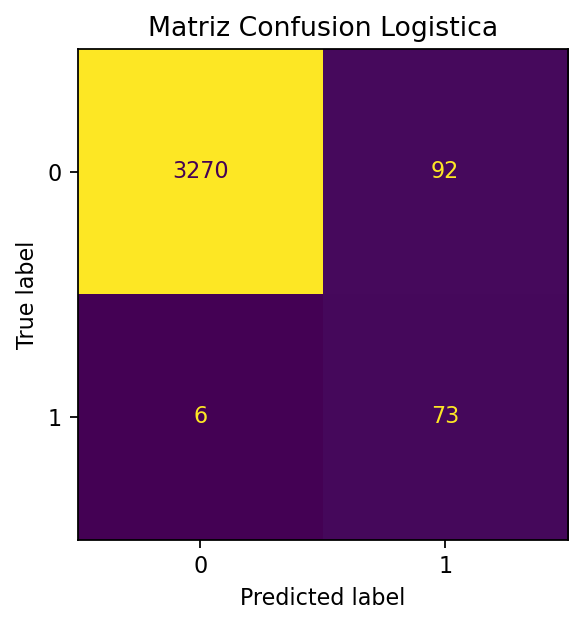

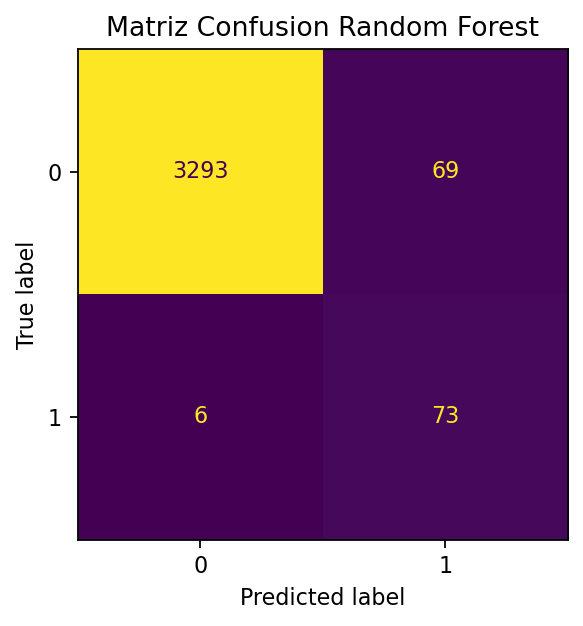

In [23]:
for fig in [cfg.FIG_CM_LOGISTIC, cfg.FIG_CM_RF]:
    if fig.exists():
        display(Image(filename=str(fig)))

In [24]:
model_results["confusion_matrices"]["logistica"]

,pred_0,pred_1
real_0,3270,92
real_1,6,73


In [25]:
model_results["confusion_matrices"]["random_forest"]

,pred_0,pred_1
real_0,3293,69
real_1,6,73


## 9. Despliegue técnico con Prefect, Docker, PostgreSQL/PostGIS y MongoDB

El proyecto incluye docker-compose.yml para levantar PostgreSQL/PostGIS y MongoDB. La orquestación está en flows/pipeline.py.

Para ejecutar el pipeline completo desde terminal:

In [ ]:
from bdtools.databases import load_databases
